# Final Project — Ironhack AI Bootcamp

Engineering evidence for the YouTube QA Bot. Shows that all component choices (Whisper model, chunking, embeddings, LLM) are data-driven.

## Benchmarks Overview

| # | Benchmark | What varies |
|---|-----------|-------------|
| 1 | Whisper model size | `tiny`, `base`, `small`, `medium`, `large-v3`, `api` × 3 videos |
| 2 | Audio bitrate | 8 – 128 kbps |
| 3 | Embedding models | `3-small`, `3-large`, `BGE` |
| 4 | LLM comparison | GPT-4o-mini, GPT-5-mini, GPT-5, Llama, Qwen |
| 5 | RAG vs. no-RAG | With / without retrieval context |
| 6 | Chunk-size grid | 6 configs × 3 videos × 3 Whisper models |
| 7 | Full Whisper × LLM matrix | All combinations end-to-end |

## 1. Setup & Installation

In [1]:
from pathlib import Path

_req_path = Path("/content/requirements.txt") if Path("/content").exists() else Path("requirements.txt")

_req_path.write_text("""\
openai-whisper
openai
jiwer
youtube-transcript-api
pandas
matplotlib
seaborn
python-dotenv
sentence-transformers
langchain
langchain-core
langchain-openai
langchain-chroma
langchain-text-splitters
langchain-community
langgraph
chromadb
tiktoken
huggingface-hub
yt-dlp
""")
print(f"✅ requirements.txt written to {_req_path}")


✅ requirements.txt written to /content/requirements.txt


In [2]:
import subprocess, sys

PACKAGES = [
    "openai-whisper",
    "openai",
    "jiwer",
    "youtube-transcript-api",
    "pandas",
    "matplotlib",
    "seaborn",
    "python-dotenv",
    "sentence-transformers",
    "langchain",
    "langchain-core",
    "langchain-openai",
    "langchain-chroma",
    "langchain-text-splitters",
    "langchain-community",
    "langgraph",
    "chromadb",
    "tiktoken",
    "huggingface-hub",
]

print(f"📦 Installing {len(PACKAGES)} packages...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q"] + PACKAGES,
    capture_output=True, text=True,
)
if result.returncode != 0:
    print("❌ Error!")
    print(result.stderr[-2000:])
    raise RuntimeError("pip install failed")
print("✅ pip install OK")

print("⬆️  yt-dlp (force-reinstall latest)...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-U",
     "--force-reinstall", "yt-dlp"],
    check=True,
)
print("✅ yt-dlp OK")

print("\n🔍 Verifying imports...")
missing = []
for pkg in ["whisper", "openai", "jiwer", "yt_dlp", "pandas", "matplotlib",
            "sentence_transformers", "langchain", "langchain_openai",
            "langchain_chroma", "tiktoken", "huggingface_hub"]:
    try:
        __import__(pkg)
        print(f"   ✅ {pkg}")
    except ImportError as e:
        missing.append(pkg)
        print(f"   ❌ {pkg}")
if missing:
    raise RuntimeError(f"Missing: {missing}")
print("\n✅ All packages OK")


📦 Installing 19 packages...
✅ pip install OK
⬆️  yt-dlp (force-reinstall latest)...
✅ yt-dlp OK

🔍 Verifying imports...
   ✅ whisper
   ✅ openai
   ✅ jiwer
   ✅ yt_dlp
   ✅ pandas
   ✅ matplotlib
   ✅ sentence_transformers
   ✅ langchain
   ✅ langchain_openai
   ✅ langchain_chroma
   ✅ tiktoken
   ✅ huggingface_hub

✅ All packages OK


In [3]:
import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:  {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  NO GPU – Runtime → select T4 GPU!")
    print("    Without GPU, large-v3 crashes or takes very long.")


CUDA: True
GPU:  Tesla T4
VRAM: 15.6 GB


In [4]:
import shutil, subprocess
if shutil.which("ffmpeg") is None:
    subprocess.run(["apt-get", "install", "-y", "-q", "ffmpeg"], check=True)
print("✅ ffmpeg:", shutil.which("ffmpeg"))


✅ ffmpeg: /usr/bin/ffmpeg


## 2. API Keys

Priority order: Colab Secrets → `os.environ` → `.env` file. All values are cleaned with `.strip()`.

In [5]:
import os, warnings
warnings.filterwarnings("ignore")

def load_secret(key_name: str, required: bool = True):
    """Load a secret: .env file -> os.environ -> Colab Secrets (in that order)."""
    value = None

    # 1. .env file (local development)
    if not value:
        try:
            from dotenv import load_dotenv
            load_dotenv(override=False)
            raw = os.environ.get(key_name, "")
            value = raw.strip() if raw else None
        except ImportError:
            pass

    # 2. Environment variable
    if not value:
        raw = os.environ.get(key_name, "")
        value = raw.strip() if raw else None

    # 3. Colab Secrets (only if running in Colab and still no value)
    if not value:
        try:
            from google.colab import userdata
            raw = userdata.get(key_name)
            if raw:
                value = raw.strip()
        except Exception:
            pass

    if value:
        if any(c in value for c in "\r\n\t"):
            raise ValueError(f"{key_name} contains invalid characters")
        os.environ[key_name] = value
        return value
    if required:
        raise RuntimeError(f"❌ {key_name} not found in .env, environment, or Colab Secrets.")
    return None


OPENAI_API_KEY = load_secret("OPENAI_API_KEY", required=True)
print(f"✅ OPENAI_API_KEY (ends with: ...{OPENAI_API_KEY[-4:]})")

HF_TOKEN = load_secret("HF_TOKEN", required=False)
if HF_TOKEN:
    print(f"✅ HF_TOKEN (ends with: ...{HF_TOKEN[-4:]})")
else:
    print("ℹ️  HF_TOKEN not set — HuggingFace models will be skipped")

LANGSMITH_API_KEY = load_secret("LANGSMITH_API_KEY", required=False)
if LANGSMITH_API_KEY:
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_CALLBACKS_BACKGROUND"] = "false"
    os.environ["LANGSMITH_PROJECT"] = "youtube-qa-benchmark"
    os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"
    print("✅ LangSmith tracing active (EU)")


✅ OPENAI_API_KEY (ends with: ...WhMA)
✅ HF_TOKEN (ends with: ...UTvP)
✅ LangSmith tracing active (EU)


## 3. Paths & Configuration

Works in Colab and locally. All paths are derived from `BASE_DIR`.

In [6]:
# ═══════════════════════════════════════════════════════════════════
# Central configuration: paths, judge, 3 benchmark videos, checkpoints
# ═══════════════════════════════════════════════════════════════════
from pathlib import Path
import pickle, os

def _is_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

IS_COLAB = _is_colab()
BASE_DIR = Path("/content") if IS_COLAB else Path.cwd()

AUDIO_DIR      = BASE_DIR / "benchmark_audio"
OUTPUT_DIR     = BASE_DIR / "benchmark_results"
CHECKPOINT_DIR = BASE_DIR / "benchmark_checkpoints"
for d in (AUDIO_DIR, OUTPUT_DIR, CHECKPOINT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# The 3 fixed benchmark videos
BENCHMARK_VIDEOS = [
    {"label": "short_video",  "url": "https://www.youtube.com/watch?v=l-rBd0F6d9E"},  # ~5 min
    {"label": "medium_video", "url": "https://www.youtube.com/watch?v=ubjW4aq_MAg"},  # ~17 min
    {"label": "long_video",   "url": "https://www.youtube.com/watch?v=B5K3Wj6r_HU"},  # ~42 min
]
CLIP_SECONDS = 2700  # 45 min cap

# Judge configuration
JUDGE_MODEL = "gpt-4o-mini"
# JUDGE_MODEL = "hf:llama-3.3"
# JUDGE_MODEL = "gpt-5"  # ⚠️ presentation run only

# Checkpoint helper
def _ckpt_path(key: tuple) -> Path:
    safe = "__".join(str(k).replace("/", "_") for k in key)
    return CHECKPOINT_DIR / f"{safe}.pkl"

def ckpt_has(key: tuple) -> bool:
    return _ckpt_path(key).exists()

def ckpt_save(key: tuple, value) -> None:
    with open(_ckpt_path(key), "wb") as f:
        pickle.dump(value, f)

def ckpt_load(key: tuple):
    with open(_ckpt_path(key), "rb") as f:
        return pickle.load(f)

def ckpt_clear(prefix: str | None = None) -> int:
    n = 0
    for p in CHECKPOINT_DIR.glob("*.pkl"):
        if prefix is None or p.name.startswith(prefix):
            p.unlink(); n += 1
    return n

print(f"{'🔵 Colab' if IS_COLAB else '💻 Local'} detected")
print(f"   BASE_DIR:       {BASE_DIR}")
print(f"   CHECKPOINT_DIR: {CHECKPOINT_DIR}")
print(f"   JUDGE:          {JUDGE_MODEL}")
print(f"   Videos:         {[v['label'] for v in BENCHMARK_VIDEOS]}")

# Local cache for audio files and reference texts
# True  = aus Cache laden (für Development, keine YouTube-Calls)
# False = frisch von YouTube ziehen (für Vorführung)
USE_CACHED_VIDEOS = True
CACHE_DIR = BASE_DIR / "benchmark_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f"   CACHE_DIR:  {CACHE_DIR}  (use cache: {USE_CACHED_VIDEOS})")

# Business sweet spot: score >= threshold is considered production-ready
SWEET_SPOT_THRESHOLD = 3.5


🔵 Colab detected
   BASE_DIR:       /content
   CHECKPOINT_DIR: /content/benchmark_checkpoints
   JUDGE:          gpt-4o-mini
   Videos:         ['short_video', 'medium_video', 'long_video']
   CACHE_DIR:  /content/benchmark_cache  (use cache: True)


## 4. Export Helpers

In [7]:
# ═══════════════════════════════════════════════════════════════════
# Export helpers: save each benchmark's figure + dataframe
# ═══════════════════════════════════════════════════════════════════
def export_benchmark(n: int, df, fig=None):
    """Save per-benchmark CSV and PNG. Handles show() and close() internally."""
    import matplotlib.pyplot as _plt
    # ── CSV ──
    try:
        csv_path = OUTPUT_DIR / f"benchmark{n}.csv"
        df_clean = df.copy()
        for col in ("transcript", "answers_json"):
            if col in df_clean.columns:
                df_clean = df_clean.drop(columns=[col])
        df_clean.to_csv(csv_path, index=False)
        print(f"💾 saved {csv_path.name}")
    except Exception as e:
        print(f"⚠️  CSV export failed: {e}")
    # ── PNG: savefig BEFORE show() to capture the figure ──
    try:
        target = fig if fig is not None else _plt.gcf()
        png_path = OUTPUT_DIR / f"benchmark{n}.png"
        target.savefig(png_path, dpi=150, bbox_inches="tight")
        print(f"💾 saved {png_path.name}")
    except Exception as e:
        print(f"⚠️  PNG export failed: {e}")
    _plt.show()
    _plt.close("all")

print("✅ export_benchmark helper ready")


✅ export_benchmark helper ready


## 5. Benchmark Videos

3 fixed YouTube videos with different lengths:

| Label | Duration |
|-------|----------|
| `short` | ~4:40 min |
| `medium` | ~17 min |
| `long` | ~42 min |

In [8]:
# ═══════════════════════════════════════════════════════════════════
# YouTube download for all 3 benchmark videos (with local cache)
# ═══════════════════════════════════════════════════════════════════
import yt_dlp, json as _json, shutil as _sh
from youtube_transcript_api import YouTubeTranscriptApi

_ROBUST_OPTS = {
    "extractor_args": {"youtube": {
        "player_client": ["tv_embedded", "web_safari", "ios", "android"],
        "player_skip": ["webpage", "configs"],
    }},
    "http_headers": {
        "User-Agent": ("Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                       "AppleWebKit/605.1.15 (KHTML, like Gecko) "
                       "Version/17.0 Safari/605.1.15"),
        "Accept-Language": "en-US,en;q=0.9",
    },
    "retries": 5, "fragment_retries": 5, "extractor_retries": 5,
    "quiet": True, "no_warnings": True,
}

def download_audio(url: str, out_dir, bitrate_kbps: str = "64"):
    out_dir = str(out_dir)
    ydl_opts = {
        **_ROBUST_OPTS,
        "format": "bestaudio/best",
        "outtmpl": f"{out_dir}/%(id)s_{bitrate_kbps}kbps.%(ext)s",
        "postprocessors": [{
            "key": "FFmpegExtractAudio",
            "preferredcodec": "m4a",
            "preferredquality": bitrate_kbps,
        }],
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
    return f"{out_dir}/{info['id']}_{bitrate_kbps}kbps.m4a", info

# ── LOCAL FILE OVERRIDE ─────────────────────────────────────────────────────
# If you place your own M4A files in /content/ (or BASE_DIR) named
#   short_video.m4a / medium_video.m4a / long_video.m4a
# the notebook will use them directly — no YouTube download, no IP ban.
# Metadata (title, duration) is read from a matching <label>.json if present,
# otherwise extracted automatically from the audio file via ffprobe.
# ────────────────────────────────────────────────────────────────────────────

def _ffprobe_duration(path: str) -> int:
    """Extract audio duration in seconds via ffprobe."""
    import subprocess as _sp, json as _fj
    try:
        r = _sp.run(
            ["ffprobe", "-v", "quiet", "-print_format", "json",
             "-show_format", path],
            capture_output=True, text=True, check=True,
        )
        return int(float(_fj.loads(r.stdout)["format"]["duration"]))
    except Exception:
        return CLIP_SECONDS   # safe fallback

def _load_or_create_meta(label: str, url: str, local_audio: Path) -> dict:
    """
    Build a meta dict for a locally provided audio file.
    Reads <label>.json from BASE_DIR or CACHE_DIR if available,
    otherwise builds one from ffprobe output.
    """
    # look for a sidecar JSON in BASE_DIR or CACHE_DIR
    for candidate in (BASE_DIR / f"{label}.json", CACHE_DIR / f"{label}.json"):
        if candidate.exists():
            m = _json.loads(candidate.read_text())
            m.setdefault("label", label)
            m.setdefault("url", url)
            m.setdefault("id", label)   # use label as synthetic video_id
            return m
    # no JSON found — derive from the file itself
    duration = _ffprobe_duration(str(local_audio))
    return {
        "label":        label,
        "url":          url,
        "id":           label,           # synthetic id — no real YouTube id
        "title":        f"{label} (local file)",
        "duration_sec": duration,
    }

VIDEOS: dict[str, dict] = {}
for v in BENCHMARK_VIDEOS:
    label, url = v["label"], v["url"]
    cached_audio = CACHE_DIR / f"{label}.m4a"
    cached_meta  = CACHE_DIR / f"{label}.json"

    # ── Priority 1: local file dropped into BASE_DIR (/content/) ──────────
    local_override = BASE_DIR / f"{label}.m4a"
    if local_override.exists():
        audio_path = str(AUDIO_DIR / f"{label}_local.m4a")
        _sh.copy(str(local_override), audio_path)
        meta = _load_or_create_meta(label, url, local_override)
        meta["audio_path"] = audio_path
        # persist to cache so subsequent cells can find it
        _sh.copy(str(local_override), str(cached_audio))
        cached_meta.write_text(_json.dumps(
            {k: v for k, v in meta.items() if k != "audio_path"}, indent=2))
        VIDEOS[label] = meta
        size_mb = os.path.getsize(audio_path) / (1024 * 1024)
        print(f"📁 [{label}] local file: {meta['title']} "
              f"({meta['duration_sec']}s | {size_mb:.2f} MB)")
        continue

    # ── Priority 2: benchmark_cache (from a previous run) ─────────────────
    if USE_CACHED_VIDEOS and cached_audio.exists() and cached_meta.exists():
        meta = _json.loads(cached_meta.read_text())
        audio_path = str(AUDIO_DIR / f"{meta['id']}_64kbps.m4a")
        _sh.copy(str(cached_audio), audio_path)
        meta["audio_path"] = audio_path
        VIDEOS[label] = meta
        size_mb = os.path.getsize(audio_path) / (1024 * 1024)
        print(f"📦 [{label}] cached: {meta['title']} "
              f"({meta['duration_sec']}s | {size_mb:.2f} MB)")
        continue

    # ── Priority 3: download from YouTube ─────────────────────────────────
    print(f"\n⬇️  [{label}] {url}")
    audio_path, info = download_audio(url, AUDIO_DIR, "64")
    meta = {
        "label": label, "url": url, "id": info["id"],
        "title": info.get("title"),
        "duration_sec": info.get("duration"),
        "audio_path": audio_path,
    }
    VIDEOS[label] = meta
    _sh.copy(audio_path, str(cached_audio))
    cached_meta.write_text(_json.dumps(
        {k: v for k, v in meta.items() if k != "audio_path"}, indent=2))
    size_mb = os.path.getsize(audio_path) / (1024 * 1024)
    print(f"   ✅ {info.get('title')}")
    print(f"      {info.get('duration')}s | {size_mb:.2f} MB  → cached")

print(f"\n✅ {len(VIDEOS)}/3 Videos: {list(VIDEOS.keys())}")



⬇️  [short_video] https://www.youtube.com/watch?v=l-rBd0F6d9E
   ✅ The Art of War’s Greatest Secret (Win Without Fighting)
      328s | 3.81 MB  → cached

⬇️  [medium_video] https://www.youtube.com/watch?v=ubjW4aq_MAg
   ✅ how to *literally* motivate yourself to do anything
      1037s | 12.04 MB  → cached

⬇️  [long_video] https://www.youtube.com/watch?v=B5K3Wj6r_HU
   ✅ Speak Like a Lawyer 🔥 || 9 Secrets to Sound Smart, Confident & Professional in English ✅
      2538s | 39.14 MB  → cached

✅ 3/3 Videos: ['short_video', 'medium_video', 'long_video']


In [9]:
# ═══════════════════════════════════════════════════════════════════
# Cap all videos at CLIP_SECONDS and re-encode to 64 kbps
# ═══════════════════════════════════════════════════════════════════
# Re-encoding to 64 kbps to stay below the 25 MB limit of the OpenAI Whisper API.
import subprocess
for label, meta in VIDEOS.items():
    clipped = os.path.join(AUDIO_DIR, f"{meta['id']}_clip.m4a")
    subprocess.run(
        ["ffmpeg", "-y", "-i", meta["audio_path"], "-t", str(CLIP_SECONDS),
         "-c:a", "aac", "-b:a", "64k", clipped],
        check=True, capture_output=True,
    )
    meta["clip_path"] = clipped
    meta["clip_duration_sec"] = min(meta["duration_sec"] or CLIP_SECONDS, CLIP_SECONDS)
    size_mb = os.path.getsize(clipped) / (1024*1024)
    print(f"✅ [{label}] {meta['clip_duration_sec']}s | {size_mb:.2f} MB")


✅ [short_video] 328s | 2.58 MB
✅ [medium_video] 1037s | 8.13 MB
✅ [long_video] 2538s | 19.98 MB


### Ground-Truth Transcripts from YouTube Captions

In [10]:
from youtube_transcript_api import YouTubeTranscriptApi
import re

def _fetch_reference(video_id: str, max_seconds: int) -> str:
    tl = YouTubeTranscriptApi().list(video_id)
    LANGS = ["en", "de", "es", "fr"]
    # Try manually created first, then generated, then any available
    t = None
    try:
        t = tl.find_manually_created_transcript(LANGS)
    except Exception:
        pass
    if t is None:
        try:
            t = tl.find_generated_transcript(LANGS)
        except Exception:
            pass
    if t is None:
        # Last resort: take whatever is available, prefer translatable to English
        for candidate in tl:
            try:
                t = candidate.translate("en") if candidate.language_code != "en" else candidate
                break
            except Exception:
                t = candidate
                break
    if t is None:
        raise RuntimeError(f"No transcript found for {video_id}")
    parts = []
    for s in t.fetch():
        if s.start >= max_seconds:
            break
        cleaned = re.sub(r"[\[(][^\])]*[\])]", " ", s.text)
        parts.append(cleaned.replace("\n", " "))
    return re.sub(r"\s+", " ", " ".join(parts)).strip()

for label, meta in VIDEOS.items():
    cached_ref = CACHE_DIR / f"{label}.txt"

    # ── Priority 1: local .txt reference dropped into /content/ ──────────
    # Place your own transcript as /content/short_video_ref.txt etc.
    # to bypass YouTube Transcript API completely.
    local_ref = BASE_DIR / f"{label}_ref.txt"
    if local_ref.exists():
        text = local_ref.read_text(encoding="utf-8").strip()
        meta["reference_text"] = text
        meta["reference_source"] = "local_file"
        cached_ref.write_text(text)   # persist to cache
        print(f"📁 [{label}] local reference: {len(text)} chars")
        continue

    # ── Priority 2: cache from a previous run ────────────────────────────
    if USE_CACHED_VIDEOS and cached_ref.exists():
        meta["reference_text"] = cached_ref.read_text()
        meta["reference_source"] = "auto"
        print(f"📦 [{label}] cached reference {len(meta['reference_text'])} chars")
        continue

    # ── Priority 3: fetch from YouTube Transcript API ────────────────────
    try:
        text = _fetch_reference(meta["id"], meta["clip_duration_sec"])
        meta["reference_text"] = text
        meta["reference_source"] = "auto"
        cached_ref.write_text(text)
        print(f"✅ [{label}] auto {len(text)} chars → cached")
    except Exception as e:
        meta["reference_text"] = None
        meta["reference_source"] = None
        print(f"❌ [{label}] {e}")


✅ [short_video] auto 3515 chars → cached
✅ [medium_video] auto 16940 chars → cached
✅ [long_video] auto 31490 chars → cached


## 6. Benchmark Framework — Core Functions

In [11]:
import time, gc
import torch
import whisper as openai_whisper_oss
from openai import OpenAI
from jiwer import wer
import pandas as pd

WHISPER_API_COST_PER_MINUTE = 0.006
COLAB_GPU_COST_PER_HOUR = 0.10  # T4 reference price


def benchmark_opensource_whisper(model_size: str, audio_path: str,
                                   reference: str = None, label: str = None) -> dict:
    print(f"\n{'='*60}")
    print(f"🧪 whisper-{model_size}" + (f" ({label})" if label else ""))
    print(f"{'='*60}")

    load_start = time.time()
    model = openai_whisper_oss.load_model(model_size)
    load_time = time.time() - load_start
    print(f"   ⏱️  Lade: {load_time:.2f}s")

    transcribe_start = time.time()
    result = model.transcribe(audio_path, fp16=torch.cuda.is_available())
    transcribe_time = time.time() - transcribe_start
    print(f"   ⏱️  Transkribe: {transcribe_time:.2f}s")

    transcript = result["text"].strip()
    detected_lang = result.get("language", "?")

    error_rate = None
    if reference:
        error_rate = wer(reference.lower(), transcript.lower())
        print(f"   📊 WER: {error_rate*100:.2f}%")

    total_h = (load_time + transcribe_time) / 3600
    cost = total_h * COLAB_GPU_COST_PER_HOUR
    print(f"   💰 Cost: ${cost:.5f}")

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "model": f"whisper-{model_size}" + (f" [{label}]" if label else ""),
        "type": "open-source",
        "load_time_sec": round(load_time, 2),
        "transcribe_time_sec": round(transcribe_time, 2),
        "total_time_sec": round(load_time + transcribe_time, 2),
        "wer_percent": round(error_rate * 100, 2) if error_rate is not None else None,
        "cost_usd": round(cost, 5),
        "detected_language": detected_lang,
        "transcript": transcript,
    }


def benchmark_openai_api(audio_path: str, audio_duration_sec: float,
                          reference: str = None, label: str = None) -> dict:
    print(f"\n{'='*60}")
    print(f"🧪 OpenAI Whisper API" + (f" ({label})" if label else ""))
    print(f"{'='*60}")

    client = OpenAI()
    start = time.time()
    with open(audio_path, "rb") as f:
        response = client.audio.transcriptions.create(
            model="whisper-1", file=f, response_format="verbose_json",
        )
    elapsed = time.time() - start
    print(f"   ⏱️  Transkribe: {elapsed:.2f}s")

    transcript = response.text.strip()
    error_rate = None
    if reference:
        error_rate = wer(reference.lower(), transcript.lower())
        print(f"   📊 WER: {error_rate*100:.2f}%")

    duration_min = audio_duration_sec / 60
    cost = duration_min * WHISPER_API_COST_PER_MINUTE
    print(f"   💰 Cost: ${cost:.5f}")

    return {
        "model": "whisper-1 (API)" + (f" [{label}]" if label else ""),
        "type": "openai-api",
        "load_time_sec": 0.0,
        "transcribe_time_sec": round(elapsed, 2),
        "total_time_sec": round(elapsed, 2),
        "wer_percent": round(error_rate * 100, 2) if error_rate is not None else None,
        "cost_usd": round(cost, 5),
        "detected_language": response.language,
        "transcript": transcript,
    }

print("✅ Framework ready")


✅ Framework ready


## Benchmark 1 — Whisper Model Sizes

In [12]:
# ═══════════════════════════════════════════════════════════════════
# Benchmark 1: Whisper model sizes × 3 videos
# ═══════════════════════════════════════════════════════════════════
MODELS_TO_TEST = ["tiny", "base", "small", "medium", "large-v3", "api"]

def _run_whisper_one(model_size, audio_path, reference_text, duration_sec):
    if model_size == "api":
        return benchmark_openai_api(audio_path, duration_sec, reference_text)
    return benchmark_opensource_whisper(model_size, audio_path, reference_text)

benchmark1_results = []
for label, meta in VIDEOS.items():
    audio = meta["clip_path"]
    ref   = meta.get("reference_text")
    for model_size in MODELS_TO_TEST:
        print(f"▶️  [{label}/{model_size}] running...")
        try:
            r = _run_whisper_one(model_size, audio, ref, meta["clip_duration_sec"])
        except Exception as e:
            print(f"   ❌ {e}")
            r = None
        if r is not None:
            r = {**r, "video_label": label, "video_id": meta["id"],
                 "video_duration_sec": meta["clip_duration_sec"]}
            benchmark1_results.append(r)

print(f"\n✅ Benchmark 1 done: {len(benchmark1_results)} entries")


▶️  [short_video/tiny] running...

🧪 whisper-tiny


100%|█████████████████████████████████████| 72.1M/72.1M [00:01<00:00, 74.0MiB/s]


   ⏱️  Lade: 2.22s
   ⏱️  Transkribe: 9.57s
   📊 WER: 11.09%
   💰 Cost: $0.00033
▶️  [short_video/base] running...

🧪 whisper-base


100%|███████████████████████████████████████| 139M/139M [00:02<00:00, 53.3MiB/s]


   ⏱️  Lade: 4.10s
   ⏱️  Transkribe: 10.50s
   📊 WER: 7.50%
   💰 Cost: $0.00041
▶️  [short_video/small] running...

🧪 whisper-small


...

   ⏱️  Lade: 14.35s
   ⏱️  Transkribe: 19.08s
   📊 WER: 6.85%
   💰 Cost: $0.00093
▶️  [short_video/medium] running...

🧪 whisper-medium


100%|█████████████████████████████████████| 1.42G/1.42G [00:17<00:00, 85.2MiB/s]


   ⏱️  Lade: 32.60s
   ⏱️  Transkribe: 33.89s
   📊 WER: 5.06%
   💰 Cost: $0.00185
▶️  [short_video/large-v3] running...

🧪 whisper-large-v3


100%|█████████████████████████████████████| 2.88G/2.88G [01:27<00:00, 35.1MiB/s]


   ⏱️  Lade: 127.17s
   ⏱️  Transkribe: 89.12s
   📊 WER: 17.62%
   💰 Cost: $0.00601
▶️  [short_video/api] running...

🧪 OpenAI Whisper API
   ⏱️  Transkribe: 10.50s
   📊 WER: 4.89%
   💰 Cost: $0.03280
▶️  [medium_video/tiny] running...

🧪 whisper-tiny
   ⏱️  Lade: 0.84s
   ⏱️  Transkribe: 32.65s
   📊 WER: 14.41%
   💰 Cost: $0.00093
▶️  [medium_video/base] running...

🧪 whisper-base
   ⏱️  Lade: 1.65s
   ⏱️  Transkribe: 43.44s
   📊 WER: 10.64%
   💰 Cost: $0.00125
▶️  [medium_video/small] running...

🧪 whisper-small
   ⏱️  Lade: 5.79s
   ⏱️  Transkribe: 83.41s
   📊 WER: 9.65%
   💰 Cost: $0.00248
▶️  [medium_video/medium] running...

🧪 whisper-medium
   ⏱️  Lade: 21.98s
   ⏱️  Transkribe: 152.57s
   📊 WER: 8.92%
   💰 Cost: $0.00485
▶️  [medium_video/large-v3] running...

🧪 whisper-large-v3
   ⏱️  Lade: 43.98s
   ⏱️  Transkribe: 333.36s
   📊 WER: 17.61%
   💰 Cost: $0.01048
▶️  [medium_video/api] running...

🧪 OpenAI Whisper API
   ⏱️  Transkribe: 48.73s
   📊 WER: 9.52%
   💰 Cost: $0.10370


### Results Table — All Whisper × Video Combinations

In [13]:
import pandas as pd
df1 = pd.DataFrame(benchmark1_results)
# Hide transcripts for compact view
cols = [c for c in df1.columns if c != "transcript"]
df1[cols].sort_values(["video_label", "model"])


,model,type,load_time_sec,transcribe_time_sec,total_time_sec,wer_percent,cost_usd,detected_language,video_label,video_id,video_duration_sec
17,whisper-1 (API),openai-api,0.00,99.88,99.88,2.38,0.25380,english,long_video,B5K3Wj6r_HU,2538
13,whisper-base,open-source,1.89,76.28,78.17,2.52,0.00217,en,long_video,B5K3Wj6r_HU,2538
16,whisper-large-v3,open-source,41.85,652.97,694.82,16.44,0.01930,en,long_video,B5K3Wj6r_HU,2538
15,whisper-medium,open-source,21.65,287.40,309.05,3.31,0.00858,en,long_video,B5K3Wj6r_HU,2538
14,whisper-small,open-source,4.68,144.24,148.91,2.40,0.00414,en,long_video,B5K3Wj6r_HU,2538
12,whisper-tiny,open-source,0.88,57.25,58.13,3.07,0.00161,en,long_video,B5K3Wj6r_HU,2538
11,whisper-1 (API),openai-api,0.00,48.73,48.73,9.52,0.10370,english,medium_video,ubjW4aq_MAg,1037
7,whisper-base,open-source,1.65,43.44,45.10,10.64,0.00125,en,medium_video,ubjW4aq_MAg,1037
10,whisper-large-v3,open-source,43.98,333.36,377.33,17.61,0.01048,en,medium_video,ubjW4aq_MAg,1037
9,whisper-medium,open-source,21.98,152.57,174.55,8.92,0.00485,en,medium_video,ubjW4aq_MAg,1037


In [14]:
# Transcript preview per video
for label, meta in VIDEOS.items():
    print("=" * 70)
    print(f"VIDEO: {label} — {meta.get('title')}")
    print("=" * 70)
    if meta.get("reference_text"):
        print(f"REFERENZ ({meta['reference_source']}):")
        print(meta["reference_text"][:300] + "...")
    for r in [x for x in benchmark1_results if x["video_label"] == label]:
        print(f"\n--- {r['model']} ---")
        print((r.get("transcript") or "")[:300] + "...")
    print()


VIDEO: short_video — The Art of War’s Greatest Secret (Win Without Fighting)
REFERENZ (auto):
Most people think The Art of War is about fighting, But it is not. The greatest teaching from Sun Tzu is how to win without fighting at all. And once you understand this, you begin to see conflict very differently. Now, this is what Sun Tzu says, "The supreme art of war is to subdue the enemy withou...

--- whisper-tiny ---
Most people think the art of war is about fighting, but it is not. The greatest teaching from Sinsel is how to win without fighting at all. And once you understand this, you begin to see conflict very differently. Now this is what Sinsel says. The supreme art of war is to subdue the enemy without fi...

--- whisper-base ---
Most people think the art of war is about fighting, but it is not. The greatest teaching from Sun Zi is how to win without fighting at all. And once you understand this, you begin to see conflict very differently. Now this is what Sun Zi says. The Suprem

### Benchmark 1 — Visualization

💾 saved benchmark8.csv
💾 saved benchmark8.png


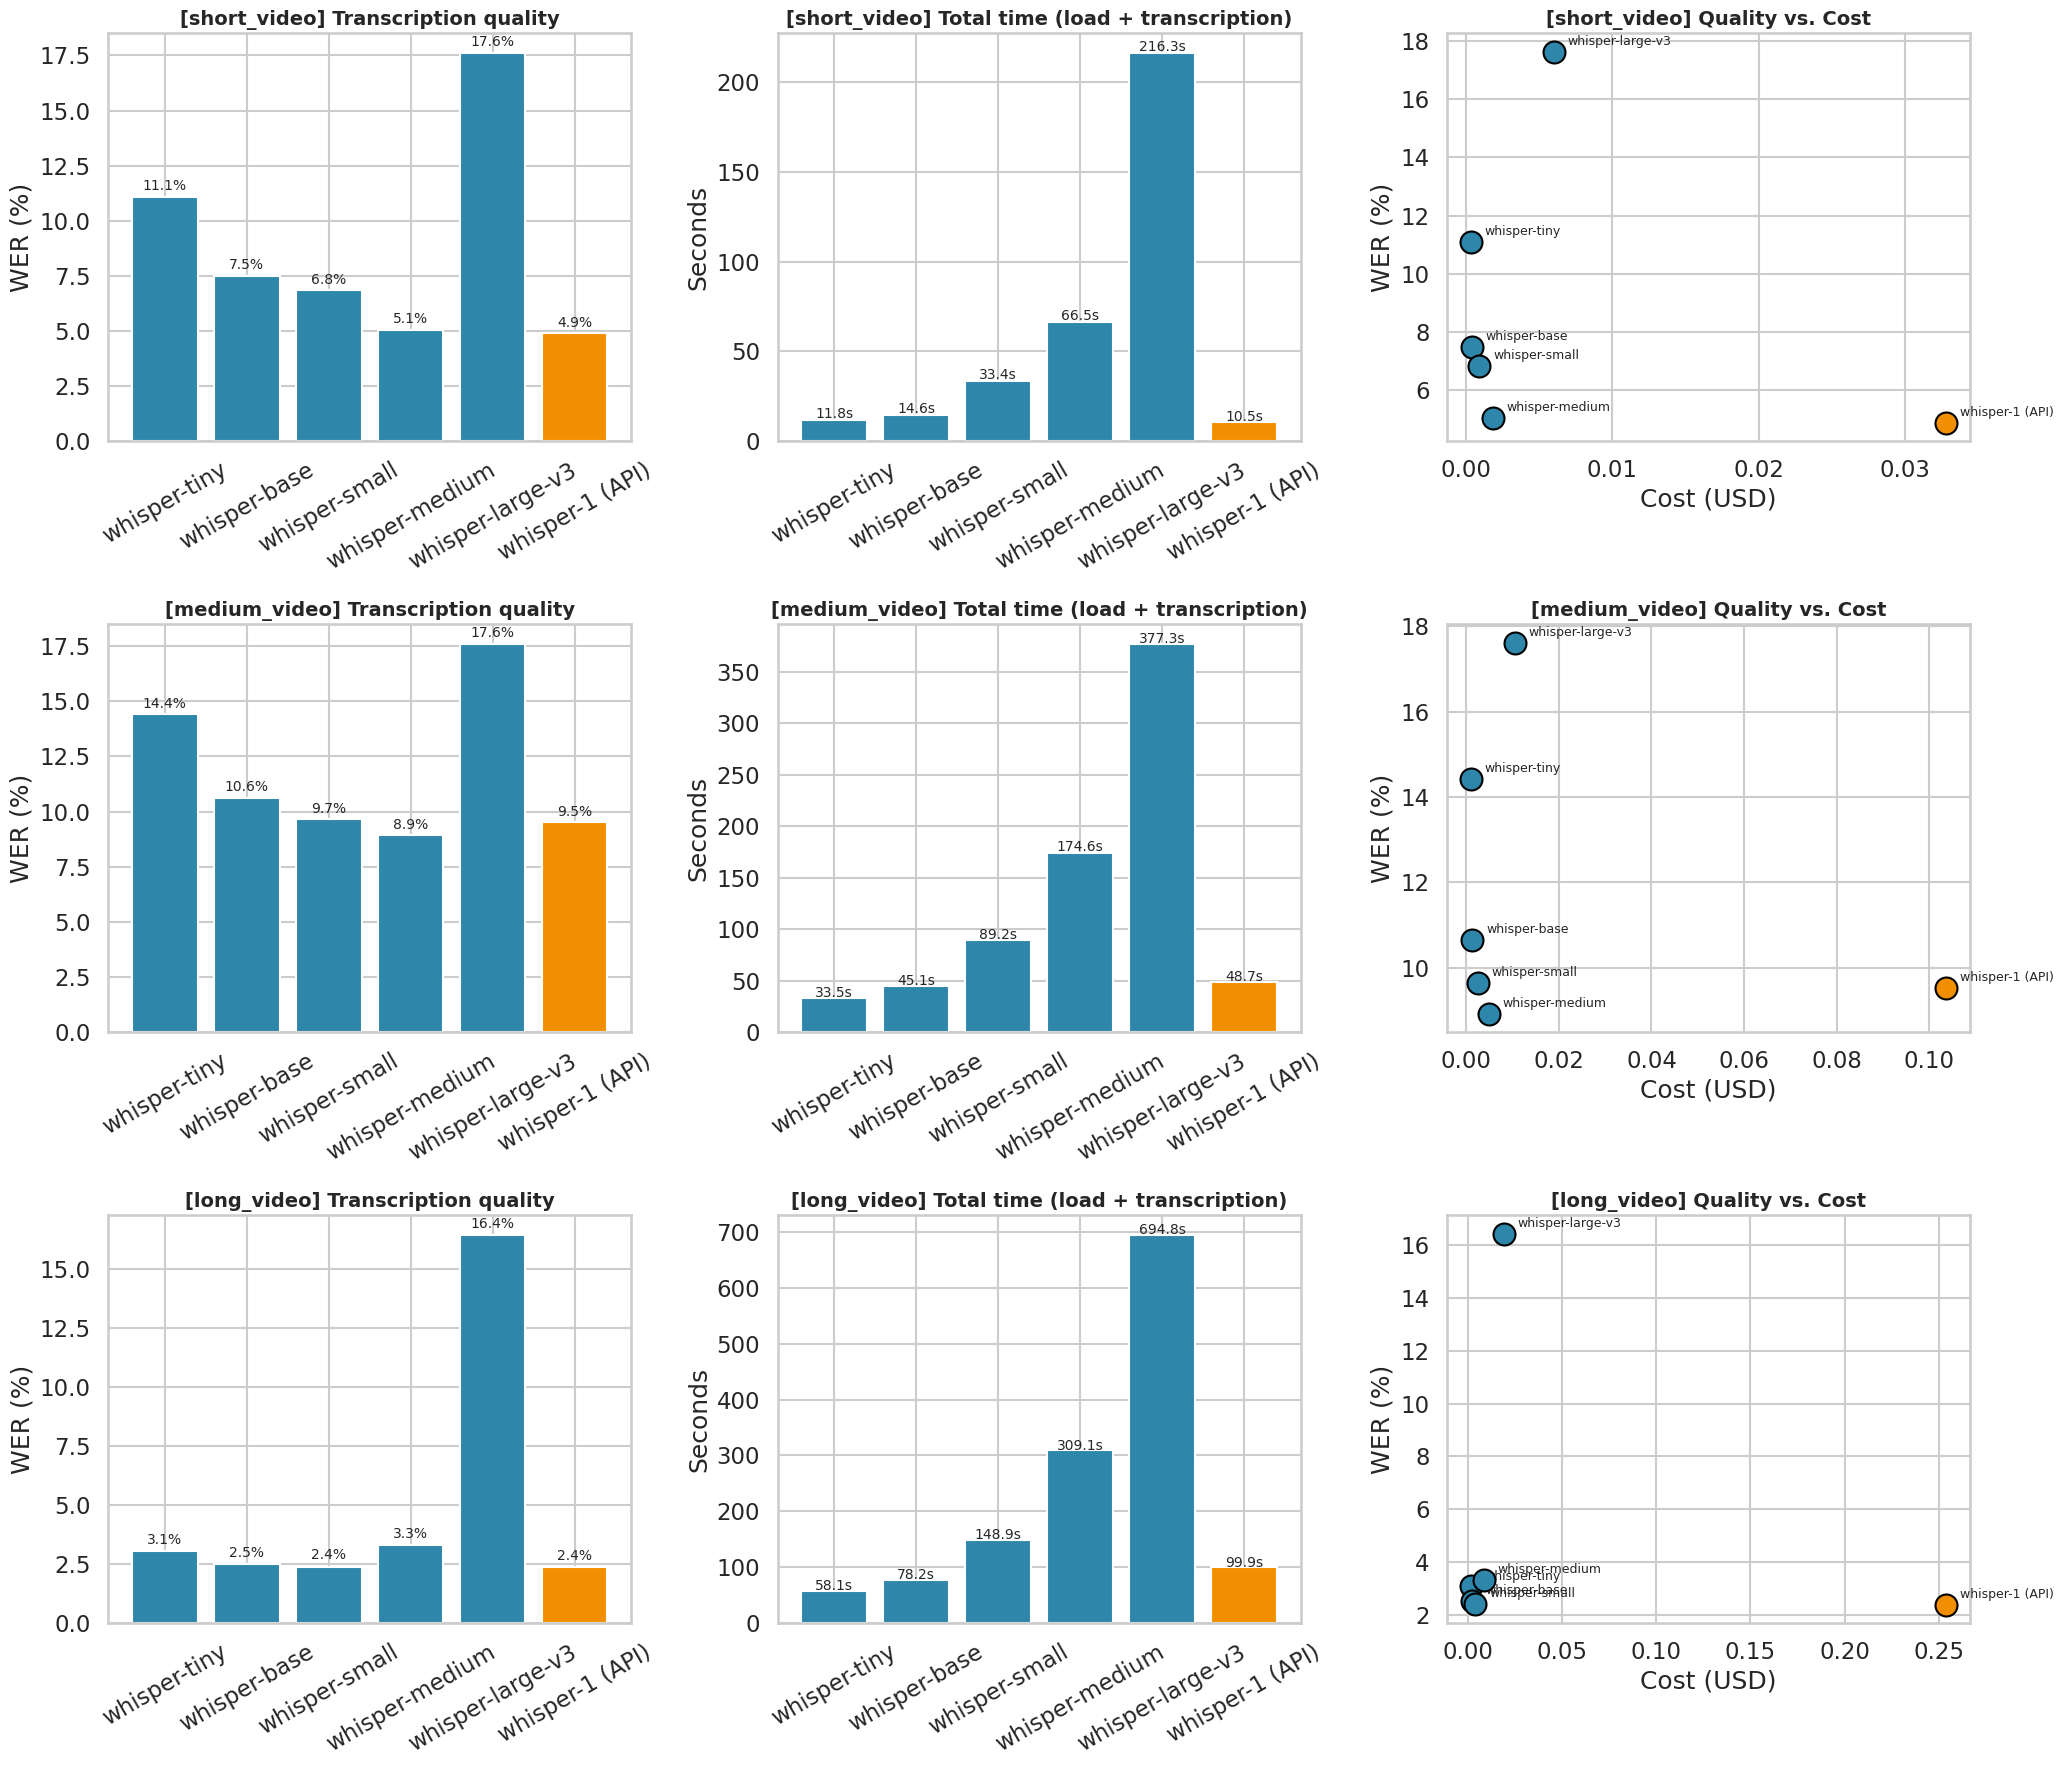

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
color_map = {"open-source": "#2E86AB", "openai-api": "#F18F01"}
df1["color"] = df1["type"].map(color_map)

video_labels = [l for l in ["short_video", "medium_video", "long_video"] if l in df1["video_label"].unique()]
n = len(video_labels)
fig, axes = plt.subplots(n, 3, figsize=(21, 6 * n))
if n == 1:
    axes = [axes]

for row_idx, vlabel in enumerate(video_labels):
    sub = df1[df1["video_label"] == vlabel].copy()
    ax_wer, ax_time, ax_par = axes[row_idx]

    # WER
    bars = ax_wer.bar(sub["model"], sub["wer_percent"], color=sub["color"])
    ax_wer.set_title(f"[{vlabel}] Transcription quality", fontsize=14, fontweight="bold")
    ax_wer.set_ylabel("WER (%)")
    ax_wer.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, sub["wer_percent"]):
        if val is not None:
            ax_wer.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f"{val:.1f}%", ha="center", fontsize=10)

    # Total time
    bars = ax_time.bar(sub["model"], sub["total_time_sec"], color=sub["color"])
    ax_time.set_title(f"[{vlabel}] Total time (load + transcription)", fontsize=14, fontweight="bold")
    ax_time.set_ylabel("Seconds")
    ax_time.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, sub["total_time_sec"]):
        if val is not None:
            ax_time.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                         f"{val:.1f}s", ha="center", fontsize=10)

    # Pareto: cost vs. quality
    for _, rr in sub.iterrows():
        if rr["cost_usd"] is None or rr["wer_percent"] is None:
            continue
        ax_par.scatter(rr["cost_usd"], rr["wer_percent"], s=250,
                       color=rr["color"], edgecolor="black", linewidth=1.5, zorder=3)
        ax_par.annotate(rr["model"], (rr["cost_usd"], rr["wer_percent"]),
                        textcoords="offset points", xytext=(10, 5), fontsize=9)
    ax_par.set_title(f"[{vlabel}] Quality vs. Cost", fontsize=14, fontweight="bold")
    ax_par.set_xlabel("Cost (USD)")
    ax_par.set_ylabel("WER (%)")

plt.tight_layout()
export_benchmark("8", df1, fig=fig)


💾 saved benchmark1.csv
💾 saved benchmark1.png


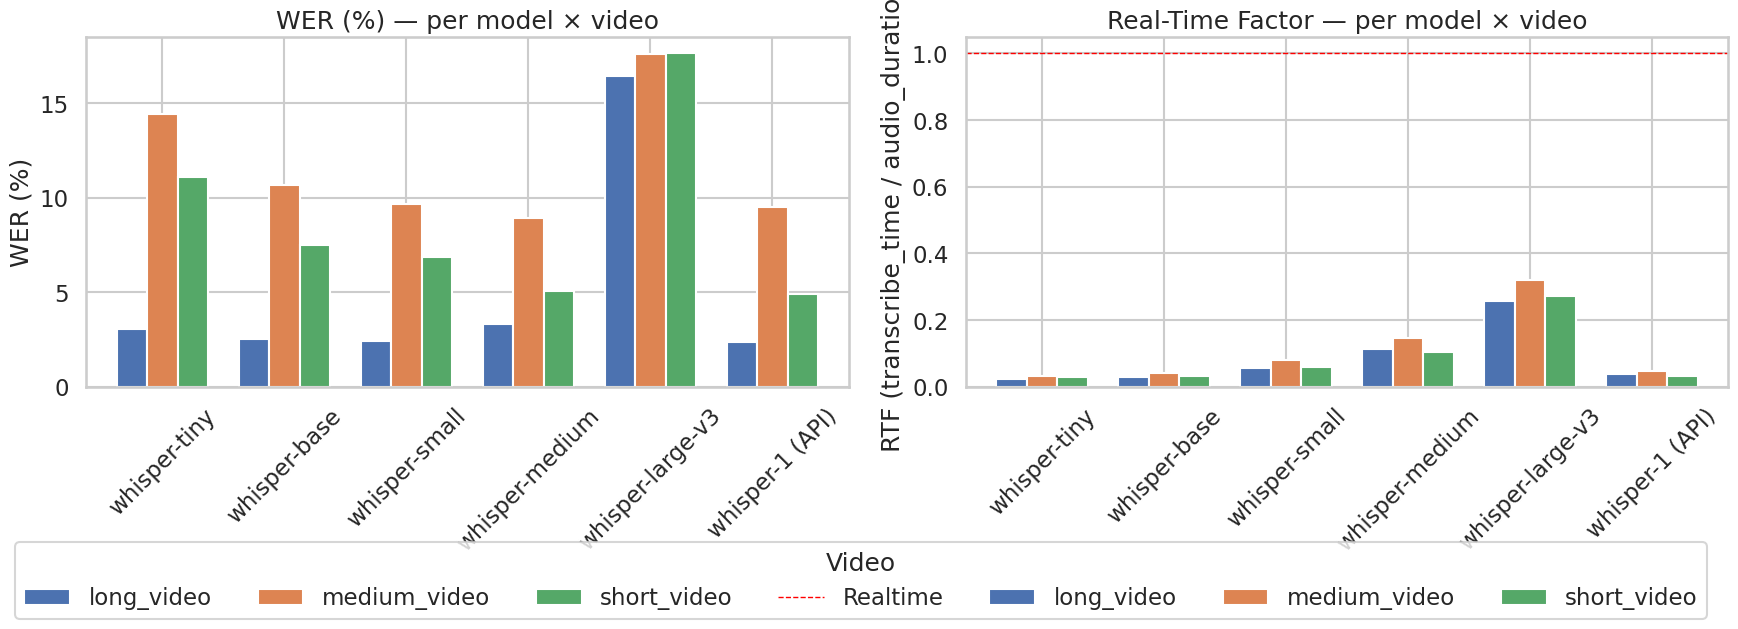

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", context="talk")

MODEL_ORDER = ["whisper-tiny", "whisper-base", "whisper-small",
               "whisper-medium", "whisper-large-v3", "whisper-1 (API)"]

df1_plot = df1.copy()
df1_plot["rtf"] = df1_plot["transcribe_time_sec"] / df1_plot["video_duration_sec"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
pivot_wer = df1_plot.pivot(index="model", columns="video_label", values="wer_percent")
pivot_wer = pivot_wer.reindex([m for m in MODEL_ORDER if m in pivot_wer.index])
pivot_wer.plot(kind="bar", ax=ax, width=0.75, legend=False)
ax.set_title("WER (%) — per model × video")
ax.set_ylabel("WER (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)

ax = axes[1]
pivot_rtf = df1_plot.pivot(index="model", columns="video_label", values="rtf")
pivot_rtf = pivot_rtf.reindex([m for m in MODEL_ORDER if m in pivot_rtf.index])
pivot_rtf.plot(kind="bar", ax=ax, width=0.75, legend=False)
ax.axhline(1.0, color="red", ls="--", lw=1, label="Realtime")
ax.set_title("Real-Time Factor — per model × video")
ax.set_ylabel("RTF (transcribe_time / audio_duration)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
rt_handle, rt_label = axes[1].get_legend_handles_labels()
handles += rt_handle
labels += rt_label
fig.legend(handles, labels, title="Video", loc="lower center",
           bbox_to_anchor=(0.5, -0.08), ncol=len(labels))

plt.tight_layout()
export_benchmark(1, df1)


In [17]:
print(df1.columns.tolist())
print(df1[["video_label", "model", "wer_percent", "transcribe_time_sec"]].head(20))

['model', 'type', 'load_time_sec', 'transcribe_time_sec', 'total_time_sec', 'wer_percent', 'cost_usd', 'detected_language', 'transcript', 'video_label', 'video_id', 'video_duration_sec', 'color']
     video_label             model  wer_percent  transcribe_time_sec
0    short_video      whisper-tiny        11.09                 9.57
1    short_video      whisper-base         7.50                10.50
2    short_video     whisper-small         6.85                19.08
3    short_video    whisper-medium         5.06                33.89
4    short_video  whisper-large-v3        17.62                89.12
5    short_video   whisper-1 (API)         4.89                10.50
6   medium_video      whisper-tiny        14.41                32.65
7   medium_video      whisper-base        10.64                43.44
8   medium_video     whisper-small         9.65                83.41
9   medium_video    whisper-medium         8.92               152.57
10  medium_video  whisper-large-v3        17.

## Eval Question Generator

Sends each video's Whisper (API) transcript to `gpt-4o-mini` and generates 10 factual questions with `question`, `reference`, and `keywords`. Results cached per video via checkpoint.

In [18]:
# ═══════════════════════════════════════════════════════════════════
# Eval-question generator: 10 factual questions per video via gpt-4o-mini
# ═══════════════════════════════════════════════════════════════════
import json as _json
from openai import OpenAI
_client_eval = OpenAI()

EVAL_GEN_PROMPT = """You are generating an evaluation set for a YouTube Q&A system.
Given the transcript below, produce EXACTLY 10 factual questions that a viewer
might ask. Each question must be answerable from the transcript alone.

Return ONLY valid JSON with a top-level key "questions".
Schema:
{{
  "questions": [
    {{"question": "...", "reference": "...", "keywords": ["...", "..."]}},
    ...
  ]
}}

- "question": a clear, specific question in English
- "reference": a concise factual answer (1-2 sentences) grounded in the transcript
- "keywords": 2-5 lowercase keywords/phrases expected in a correct answer

Transcript:
{transcript}
"""

def _get_api_transcript(label: str):
    for r in benchmark1_results:
        if r["video_label"] == label and r["model"] == "whisper-1 (API)":
            return r.get("transcript")
    return None

def generate_eval_questions(transcript: str, n_retries: int = 2):
    prompt = EVAL_GEN_PROMPT.format(transcript=transcript[:12000])
    for attempt in range(n_retries + 1):
        try:
            resp = _client_eval.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": prompt}],
                response_format={"type": "json_object"},
            )
            raw = resp.choices[0].message.content
            data = _json.loads(raw)

            if isinstance(data, dict):
                if "questions" in data:
                    data = data["questions"]
                elif len(data) == 1 and isinstance(list(data.values())[0], list):
                    data = list(data.values())[0]

            if isinstance(data, list) and len(data) >= 5:
                return data[:10]
        except Exception as e:
            print(f"   retry {attempt+1}: {e}")
    return []

EVAL_QUESTIONS_BY_VIDEO = {}
for label in VIDEOS:
    t = _get_api_transcript(label)
    if not t:
        print(f"  [{label}] no API transcript — skipping")
        continue
    print(f"  [{label}] generating eval questions...")
    qs = generate_eval_questions(t)
    EVAL_QUESTIONS_BY_VIDEO[label] = qs
    print(f"   ✅ {len(qs)} questions")

REFERENCE_VIDEO_LABEL = "medium_video"
EVAL_QUESTIONS = EVAL_QUESTIONS_BY_VIDEO.get(REFERENCE_VIDEO_LABEL, [])
REFERENCE_VIDEO = VIDEOS.get(REFERENCE_VIDEO_LABEL, {})
REFERENCE_TEXT = REFERENCE_VIDEO.get("reference_text")
BENCHMARK_AUDIO = REFERENCE_VIDEO.get("clip_path")
BENCHMARK_DURATION_SEC = REFERENCE_VIDEO.get("clip_duration_sec")
print(f"\n→ Default EVAL_QUESTIONS = '{REFERENCE_VIDEO_LABEL}' ({len(EVAL_QUESTIONS)} questions)")

  [short_video] generating eval questions...
   ✅ 10 questions
  [medium_video] generating eval questions...
   ✅ 10 questions
  [long_video] generating eval questions...
   ✅ 10 questions

→ Default EVAL_QUESTIONS = 'medium_video' (10 questions)


### Generated Eval Questions

In [19]:
import pandas as pd

for label, questions in EVAL_QUESTIONS_BY_VIDEO.items():
    print(f"\n{'='*80}")
    print(f"Questions for: {label}")
    print(f"{'='*80}")
    if not questions:
        print("No questions found.")
        continue

    # Display as a clean table
    df_qs = pd.DataFrame(questions)
    display(df_qs)



Questions for: short_video


,question,reference,keywords
0,What does Sun Tzu believe is the supreme art o...,Sun Tzu states that the supreme art of war is ...,"[supreme art, war, subdue, without fighting]"
1,How should one view conflict according to the ...,Understanding Sun Tzu's teachings allows one t...,"[conflict, resolution, teaching]"
2,What is the highest form of victory mentioned ...,The highest form of victory is not to fight at...,"[highest form, victory, not fight]"
3,What does winning without fighting require acc...,Winning without fighting is about positioning ...,"[winning, without fighting, positioning]"
4,What does Sun Tzu mean by saying the victoriou...,Sun Tzu indicates that the victorious warrior ...,"[victorious warrior, win, go to war]"
5,How should one approach conflict in business a...,"In business, the best deal is the one where no...","[business, best deal, no one defeated]"
6,What does the term 'true victory' refer to in ...,True victory refers to achieving stability rat...,"[true victory, stability, winning]"
7,What advice is given for facing conflict?,One should ask how to resolve the conflict bef...,"[facing conflict, resolve, before fight]"
8,What is said about unnecessary conflicts?,Avoiding unnecessary conflicts is easier when ...,"[unnecessary conflicts, fighting, first option]"
9,How can one build a stronger position during c...,"By gaining allies during the conflict, one can...","[stronger position, allies, conflict]"



Questions for: medium_video


,question,reference,keywords
0,What kind of self-talk increases motivation ac...,Interrogative self-talk increases motivation b...,"[interrogative self-talk, motivation, declarat..."
1,What is the main action to take when feeling n...,When feeling nervous before social interaction...,"[nervous, social interaction, confident person]"
2,What type of questions engage the brain's prob...,Questions engage the brain's problem-solving n...,"[problem-solving, questions, brain engagement]"
3,What effect does asking questions have on psyc...,Asking questions bypasses psychological resist...,"[psychological resistance, autonomy, questions]"
4,What is the first type of interrogative self-t...,The first type of question is initiation quest...,"[initiation questions, self-talk, activation e..."
5,How does interrogative self-talk differ from d...,Interrogative self-talk involves asking questi...,"[interrogative self-talk, declarative self-tal..."
6,What are friction reducing questions used for?,Friction reducing questions help identify hidd...,"[friction reducing questions, hidden resistanc..."
7,What effect do unanswered questions have on th...,"Unanswered questions make the brain squirm, as...","[unanswered questions, brain, energy]"
8,What does asking yourself questions do for mot...,Asking yourself the right questions can move y...,"[motivation, low-energy states, questions]"
9,What is the importance of autonomy in psycholo...,Autonomy is a key ingredient in psychological ...,"[autonomy, psychological flourishing, motivation]"



Questions for: long_video


,question,reference,keywords
0,What is the main reason a lawyer is considered...,"A lawyer is powerful because of words, specifi...","[powerful, lawyer, words]"
1,Can anyone learn to speak like a lawyer?,"Yes, speaking like a lawyer can be learned as ...","[speak, lawyer, learn]"
2,What is the first secret to speaking like a la...,The first secret is to use clear and strong se...,"[first secret, strong sentences, clarity]"
3,What is one common mistake students make when ...,"One of the biggest mistakes is using long, com...","[mistake, students, long sentences]"
4,How do lawyers control their tone and pace?,Lawyers control their tone and pace by speakin...,"[control, tone, pace]"
5,What is the importance of building a strong vo...,A strong vocabulary allows lawyers to express ...,"[strong vocabulary, clarity, communication]"
6,What should you focus on to replace weak words?,You should focus on replacing weak words with ...,"[replace, weak words, stronger alternatives]"
7,What is the relationship between clarity and c...,Clarity in your sentences shows confidence; wh...,"[clarity, confidence, communication]"
8,Why is using logic considered important in com...,Using logic is important because it makes your...,"[logic, communication, importance]"
9,What is the effect of using filler words in sp...,Using filler words like 'um' or 'you know' wea...,"[filler words, weakens, message]"


## Benchmark 2 — Audio Bitrate

Re-encodes the reference video at 5 bitrates (8–128 kbps) and transcribes with `base` and `small`. Tests whether lower bitrate degrades WER.

In [20]:
BITRATES_TO_TEST = [8, 16, 32, 64, 128]
benchmark2_audio_paths = {}

# ── Use local file if available, otherwise download from YouTube ──
# The reference video was already handled in cell 13.
# If a local M4A was provided, reuse it directly — no second YouTube call.
_ref_meta = VIDEOS[REFERENCE_VIDEO_LABEL]
_local_b2 = BASE_DIR / f"{REFERENCE_VIDEO_LABEL}.m4a"
_cached_b2 = CACHE_DIR / f"{REFERENCE_VIDEO_LABEL}.m4a"

if _local_b2.exists():
    import shutil as _sh2
    src_path = str(AUDIO_DIR / f"{REFERENCE_VIDEO_LABEL}_b2src.m4a")
    _sh2.copy(str(_local_b2), src_path)
    print(f"📁 [B2] using local file: {_local_b2.name}")
elif _cached_b2.exists():
    import shutil as _sh2
    src_path = str(AUDIO_DIR / f"{REFERENCE_VIDEO_LABEL}_b2src.m4a")
    _sh2.copy(str(_cached_b2), src_path)
    print(f"📦 [B2] using cached file")
else:
    src_path, _ = download_audio(VIDEOS[REFERENCE_VIDEO_LABEL]["url"], AUDIO_DIR, "128")
    print(f"⬇️  [B2] downloaded from YouTube")

for br in BITRATES_TO_TEST:
    print(f"\nRe-encoding to {br} kbps...")
    out_path = str(AUDIO_DIR / f"b2_{br}kbps.m4a")
    subprocess.run(
        ["ffmpeg", "-y", "-i", src_path, "-c:a", "aac", "-b:a", f"{br}k", out_path],
        check=True, capture_output=True,
    )
    benchmark2_audio_paths[br] = out_path

print("\n✅ All bitrates ready")


📦 [B2] using cached file

Re-encoding to 8 kbps...

Re-encoding to 16 kbps...

Re-encoding to 32 kbps...

Re-encoding to 64 kbps...

Re-encoding to 128 kbps...

✅ All bitrates ready


In [21]:
BITRATE_MODELS = ["base", "small"]

benchmark2_results = []

for model_size in BITRATE_MODELS:
    print(f"\n{'='*60}")
    print(f"🎙️  Whisper model: {model_size}")
    print(f"{'='*60}")
    for br, audio_path in benchmark2_audio_paths.items():
        r = benchmark_opensource_whisper(
            model_size, audio_path, REFERENCE_TEXT, label=f"{br} kbps"
        )
        r["bitrate_kbps"] = int(br)
        r["model_size"] = model_size
        r["audio_size_kb"] = round(os.path.getsize(audio_path) / 1024, 1)
        benchmark2_results.append(r)

print(f"\n✅ Benchmark 2 done – {len(benchmark2_results)} measurements")
print(f"   ({len(BITRATE_MODELS)} models × {len(BITRATES_TO_TEST)} bitrates)")



🎙️  Whisper model: base

🧪 whisper-base (8 kbps)
   ⏱️  Lade: 1.27s
   ⏱️  Transkribe: 350.92s
   📊 WER: 97.75%
   💰 Cost: $0.00978

🧪 whisper-base (16 kbps)
   ⏱️  Lade: 1.54s
   ⏱️  Transkribe: 46.45s
   📊 WER: 35.46%
   💰 Cost: $0.00133

🧪 whisper-base (32 kbps)
   ⏱️  Lade: 1.71s
   ⏱️  Transkribe: 42.43s
   📊 WER: 11.80%
   💰 Cost: $0.00123

🧪 whisper-base (64 kbps)
   ⏱️  Lade: 1.17s
   ⏱️  Transkribe: 43.85s
   📊 WER: 10.64%
   💰 Cost: $0.00125

🧪 whisper-base (128 kbps)
   ⏱️  Lade: 1.14s
   ⏱️  Transkribe: 43.48s
   📊 WER: 10.67%
   💰 Cost: $0.00124

🎙️  Whisper model: small

🧪 whisper-small (8 kbps)
   ⏱️  Lade: 4.32s
   ⏱️  Transkribe: 763.24s
   📊 WER: 99.97%
   💰 Cost: $0.02132

🧪 whisper-small (16 kbps)
   ⏱️  Lade: 3.68s
   ⏱️  Transkribe: 82.78s
   📊 WER: 20.59%
   💰 Cost: $0.00240

🧪 whisper-small (32 kbps)
   ⏱️  Lade: 3.70s
   ⏱️  Transkribe: 85.47s
   📊 WER: 9.91%
   💰 Cost: $0.00248

🧪 whisper-small (64 kbps)
   ⏱️  Lade: 3.76s
   ⏱️  Transkribe: 83.66s
   📊 WER: 

In [22]:
df2 = pd.DataFrame(benchmark2_results)
df2[["model_size", "bitrate_kbps", "audio_size_kb", "wer_percent", "transcribe_time_sec"]]


,model_size,bitrate_kbps,audio_size_kb,wer_percent,transcribe_time_sec
0,base,8,1365.5,97.75,350.92
1,base,16,2234.1,35.46,46.45
2,base,32,4281.5,11.80,42.43
3,base,64,8329.6,10.64,43.85
4,base,128,16446.3,10.67,43.48
5,small,8,1365.5,99.97,763.24
6,small,16,2234.1,20.59,82.78
7,small,32,4281.5,9.91,85.47
8,small,64,8329.6,9.65,83.66
9,small,128,16446.3,11.57,83.95


### Benchmark 2 — Visualization

✅ Saved: benchmark2_bitrates.png
💾 saved benchmark2.csv
💾 saved benchmark2.png


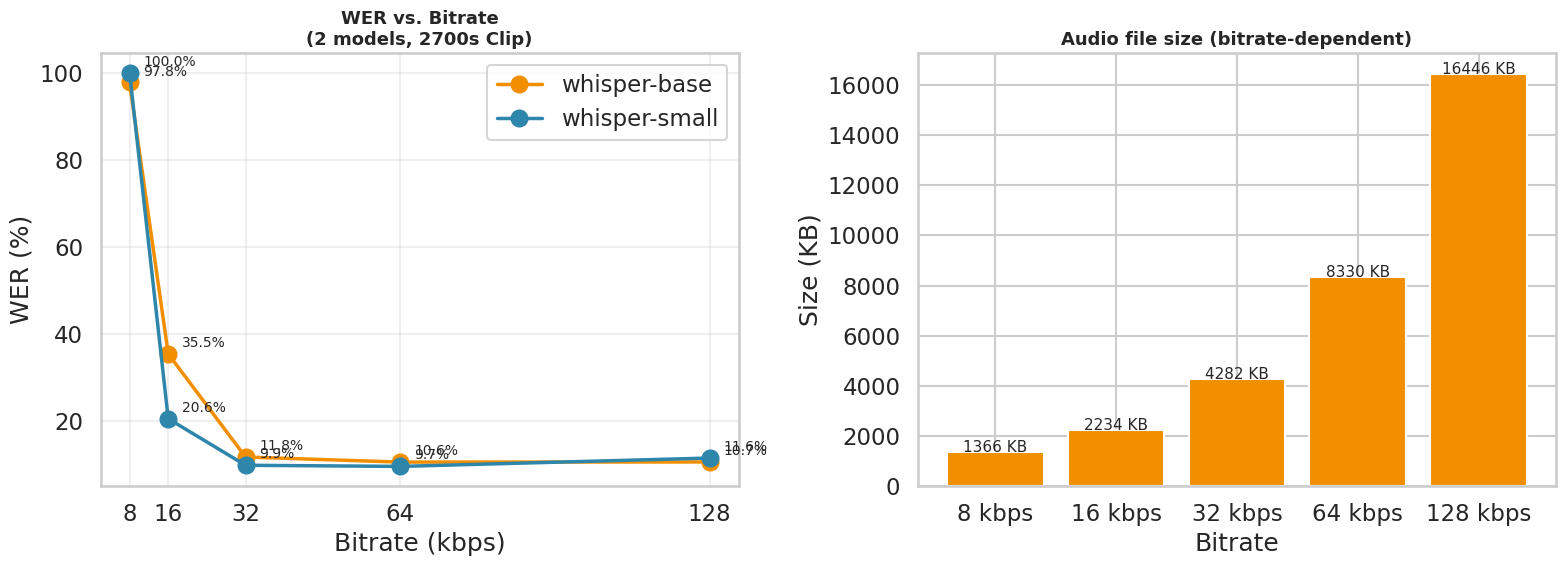

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: WER vs. bitrate — two curves, one per model
ax = axes[0]
colors_b2 = {"small": "#2E86AB", "base": "#F18F01"}
for model_size in df2["model_size"].unique():
    sub = df2[df2["model_size"] == model_size].sort_values("bitrate_kbps")
    ax.plot(sub["bitrate_kbps"], sub["wer_percent"],
            marker="o", markersize=12, linewidth=2.5,
            color=colors_b2.get(model_size, "#888"),
            label=f"whisper-{model_size}")
    for _, row in sub.iterrows():
        ax.annotate(f"{row['wer_percent']:.1f}%",
                    (row["bitrate_kbps"], row["wer_percent"]),
                    textcoords="offset points", xytext=(10, 5), fontsize=10)

ax.set_title(f"WER vs. Bitrate\n(2 models, {CLIP_SECONDS}s Clip)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Bitrate (kbps)")
ax.set_ylabel("WER (%)")
ax.set_xticks(sorted(df2["bitrate_kbps"].unique()))
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

# Right plot: file sizes — bitrate is model-independent,
# so we take values from the first model only (identical for all)
ax = axes[1]
first_model = df2["model_size"].unique()[0]
size_data = df2[df2["model_size"] == first_model].sort_values("bitrate_kbps")
bars = ax.bar(size_data["bitrate_kbps"].astype(str) + " kbps",
              size_data["audio_size_kb"], color="#F18F01")
ax.set_title("Audio file size (bitrate-dependent)", fontsize=13, fontweight="bold")
ax.set_ylabel("Size (KB)")
ax.set_xlabel("Bitrate")
for bar, val in zip(bars, size_data["audio_size_kb"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:.0f} KB", ha="center", fontsize=11)

plt.tight_layout()
print("✅ Saved: benchmark2_bitrates.png")

# Persist results for the combined report
export_benchmark(2, df2)

### Benchmark 1+2 — Best Model Recommendation

💾 saved analysis_b1b2.json


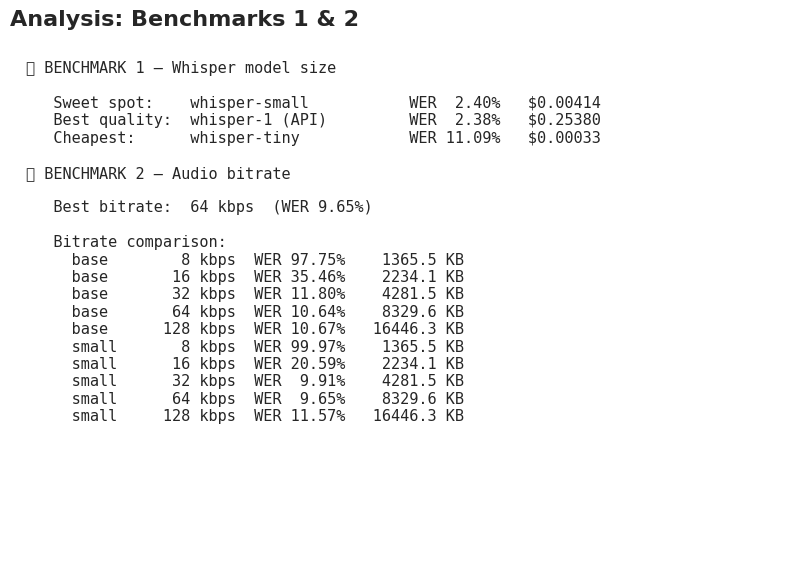

💾 saved analysis_b1b2.png


In [24]:
import json as _json
import matplotlib.pyplot as plt
import shutil

if REFERENCE_TEXT:
    df1s = df1.copy()
    df1s["wer_norm"] = (df1s["wer_percent"] - df1s["wer_percent"].min()) / \
                      (df1s["wer_percent"].max() - df1s["wer_percent"].min() + 1e-9)
    df1s["cost_norm"] = (df1s["cost_usd"] - df1s["cost_usd"].min()) / \
                       (df1s["cost_usd"].max() - df1s["cost_usd"].min() + 1e-9)
    df1s["combined"] = df1s["wer_norm"] + df1s["cost_norm"]

    best = df1s.loc[df1s["combined"].idxmin()]
    bq   = df1.loc[df1["wer_percent"].idxmin()]
    cp   = df1.loc[df1["cost_usd"].idxmin()]
    bb   = df2.loc[df2["wer_percent"].idxmin()]

    analysis = {
        "benchmark1": {
            "sweet_spot":   {"model": best["model"], "wer_percent": float(best["wer_percent"]), "cost_usd": float(best["cost_usd"])},
            "best_quality": {"model": bq["model"],   "wer_percent": float(bq["wer_percent"]),   "cost_usd": float(bq["cost_usd"])},
            "cheapest":     {"model": cp["model"],   "wer_percent": float(cp["wer_percent"]),   "cost_usd": float(cp["cost_usd"])},
        },
        "benchmark2": {
            "best_bitrate_kbps": int(bb["bitrate_kbps"]),
            "best_wer_percent":  float(bb["wer_percent"]),
            "all_measurements":  df2[["model_size","bitrate_kbps","wer_percent","audio_size_kb"]].to_dict(orient="records"),
        },
    }

    with open(OUTPUT_DIR / "analysis_b1b2.json", "w") as f:
        _json.dump(analysis, f, indent=2)
    print(f"💾 saved analysis_b1b2.json")

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.axis("off")
    ax.set_title("Analysis: Benchmarks 1 & 2", fontsize=16, fontweight="bold", loc="left")

    lines = [
        "🏆 BENCHMARK 1 — Whisper model size",
        "",
        f"   Sweet spot:    {best['model']:<22}  WER {best['wer_percent']:>5.2f}%   ${best['cost_usd']:.5f}",
        f"   Best quality:  {bq['model']:<22}  WER {bq['wer_percent']:>5.2f}%   ${bq['cost_usd']:.5f}",
        f"   Cheapest:      {cp['model']:<22}  WER {cp['wer_percent']:>5.2f}%   ${cp['cost_usd']:.5f}",
        "",
        "🏆 BENCHMARK 2 — Audio bitrate",
        "",
        f"   Best bitrate:  {int(bb['bitrate_kbps'])} kbps  (WER {bb['wer_percent']:.2f}%)",
        "",
        "   Bitrate comparison:",
    ]
    for _, row in df2.iterrows():
        lines.append(
            f"     {row['model_size']:<8} {int(row['bitrate_kbps']):>4} kbps  "
            f"WER {row['wer_percent']:>5.2f}%   {row['audio_size_kb']:>7.1f} KB"
        )

    ax.text(0.02, 0.95, "\n".join(lines),
            family="monospace", fontsize=11,
            verticalalignment="top", transform=ax.transAxes)

    png_path = OUTPUT_DIR / "analysis_b1b2.png"
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close("all")
    print(f"💾 saved {png_path.name}")

    shutil.copy(png_path, OUTPUT_DIR / "benchmark_analysis.png")


In [25]:
print('✅ Benchmark 1+2 complete. Final export is done in the last cell.')


✅ Benchmark 1+2 complete. Final export is done in the last cell.


## Benchmark 3 — Embedding Model Comparison

Tests three embedding models on retrieval quality (MRR, hit-rate):

1. `text-embedding-3-small` (OpenAI, 1536 dim) — app default
2. `text-embedding-3-large` (OpenAI, 3072 dim) — OpenAI best
3. `BAAI/bge-small-en-v1.5` (HuggingFace, 384 dim) — open-source

Fixed chunk size, `medium` reference video, dual Whisper source (API vs. small).

In [26]:
# ═══════════════════════════════════════════════════════════════════
# Dual Reference Setup: API vs. Small transcript
# ═══════════════════════════════════════════════════════════════════

def get_transcript(model_name, video_label):
    for r in benchmark1_results:
        if r['video_label'] == video_label and r['model'] == model_name:
            return r.get('transcript')
    return None

transcript_small = get_transcript('whisper-small', REFERENCE_VIDEO_LABEL)
transcript_api = get_transcript('whisper-1 (API)', REFERENCE_VIDEO_LABEL)

from langchain_text_splitters import RecursiveCharacterTextSplitter
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)

# Create two sets of chunks for comparison
CHUNKS_SMALL = splitter.split_text(transcript_small) if transcript_small else []
CHUNKS_API = splitter.split_text(transcript_api) if transcript_api else []

# For simplicity in B3/B4, we default to SMALL, but keep API available
EMBED_CHUNKS = CHUNKS_SMALL

print(f"✅ Reference Chunks Ready:")
print(f"   • Whisper-Small: {len(CHUNKS_SMALL)} chunks")
print(f"   • Whisper-API:   {len(CHUNKS_API)} chunks")

✅ Reference Chunks Ready:
   • Whisper-Small: 26 chunks
   • Whisper-API:   26 chunks


In [27]:
# ═══════════════════════════════════════════════════════════════════
# Reference Setup for Benchmarks 3, 4, 5 & 8
# ═══════════════════════════════════════════════════════════════════
# While we have questions for all videos, these specific benchmarks
# use the 'medium_video' as a fixed reference point to compare models
# (LLMs/Embeddings) fairly while controlling for API costs.

assert EVAL_QUESTIONS, "EVAL_QUESTIONS empty — did the generator fail?"
print(f"✅ Reference set ready: '{REFERENCE_VIDEO_LABEL}'")
print(f"✅ {len(EVAL_QUESTIONS)} questions will be used for model-comparison benchmarks.")

✅ Reference set ready: 'medium_video'
✅ 10 questions will be used for model-comparison benchmarks.


In [28]:
# --- Benchmark functions for embeddings ---
import numpy as np
from sentence_transformers import SentenceTransformer
from openai import OpenAI
import time

_openai_client = OpenAI()

def embed_openai(texts: list[str], model: str) -> tuple[np.ndarray, float, float]:
    """Embed texts with an OpenAI model."""
    prices_per_1m_tokens = {
        "text-embedding-3-small": 0.02,
        "text-embedding-3-large": 0.13,
    }
    price = prices_per_1m_tokens.get(model, 0.02)

    start = time.time()
    resp = _openai_client.embeddings.create(model=model, input=texts)
    elapsed = time.time() - start

    embeddings = np.array([d.embedding for d in resp.data])
    tokens = resp.usage.total_tokens
    cost = (tokens / 1_000_000) * price
    return embeddings, elapsed, cost

_hf_embedder_cache = {}

def embed_huggingface(texts: list[str], model_name: str) -> tuple[np.ndarray, float, float]:
    """Embed texts with a HuggingFace model."""
    if model_name not in _hf_embedder_cache:
        _hf_embedder_cache[model_name] = SentenceTransformer(model_name)
    model = _hf_embedder_cache[model_name]

    start = time.time()
    embeddings = model.encode(texts, show_progress_bar=False, convert_to_numpy=True)
    elapsed = time.time() - start
    return embeddings, elapsed, 0.0

def embed_texts(texts: list[str]) -> np.ndarray:
    """Helper for Benchmark 6."""
    res = _openai_client.embeddings.create(model="text-embedding-3-small", input=texts)
    return np.array([d.embedding for d in res.data])

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

def cosine_topk(query_vec, corpus_mat, k: int = 5):
    sims = corpus_mat @ query_vec
    return np.argsort(-sims)[:k].tolist()

def hit_mrr(ranked_texts: list[str], keywords: list[str]):
    kws = [k.lower() for k in keywords]
    for rank, txt in enumerate(ranked_texts, 1):
        if any(kw in txt.lower() for kw in kws):
            return 1, 1.0 / rank
    return 0, 0.0

def rrf_merge(rank_lists: list[list[int]], k: int = 60, top_k: int = 5):
    scores = {}
    for lst in rank_lists:
        for rank, idx in enumerate(lst, 1):
            scores[idx] = scores.get(idx, 0.0) + 1.0 / (k + rank)
    return [i for i, _ in sorted(scores.items(), key=lambda x: -x[1])[:top_k]]

def benchmark_embedding_model(name: str, embed_fn, chunks: list[str], eval_questions: list[dict], k: int = 5) -> dict:
    chunk_embeds, embed_time, embed_cost = embed_fn(chunks)
    questions = [q["question"] for q in eval_questions]
    q_embeds, q_time, q_cost = embed_fn(questions)

    results = []
    for q_embed, q_meta in zip(q_embeds, eval_questions):
        sims = np.array([cosine_similarity(q_embed, ce) for ce in chunk_embeds])
        top_k_indices = np.argsort(sims)[::-1][:k]
        ranked_texts = [chunks[i] for i in top_k_indices]
        h, m = hit_mrr(ranked_texts, q_meta["keywords"])
        results.append({"hit": h, "mrr": m})

    return {
        "model": name,
        "hit_rate_at_k": round(sum(r["hit"] for r in results) / len(results), 3),
        "mean_mrr": round(sum(r["mrr"] for r in results) / len(results), 3),
        "total_time_sec": round(embed_time + q_time, 2),
        "embed_cost_usd": round(embed_cost + q_cost, 5)
    }

print("✅ All benchmark functions and RRF helpers defined")

✅ All benchmark functions and RRF helpers defined


In [29]:
# --- Execution of the embedding benchmark (Dual Whisper Source) ---

benchmark3_results = []
WHISPER_SOURCES = [("Small", CHUNKS_SMALL), ("API", CHUNKS_API)]

for w_label, chunks_to_use in WHISPER_SOURCES:
    if not chunks_to_use:
        print(f"⌒⌒ [{w_label}] No chunks found, skipping source.")
        continue

    print(f"\nဢ Testing Retrieval for Whisper Source: {w_label}")

    # 1. OpenAI text-embedding-3-small
    try:
        r = benchmark_embedding_model(
            f"text-embedding-3-small ({w_label})",
            lambda texts: embed_openai(texts, "text-embedding-3-small"),
            chunks_to_use,
            EVAL_QUESTIONS,
        )
        r['whisper_source'] = w_label
        benchmark3_results.append(r)
        print(f"   ✅ text-embedding-3-small: MRR {r['mean_mrr']:.3f}")
    except Exception as e: print(f"   ❌ error: {e}")

    # 2. OpenAI text-embedding-3-large
    try:
        r = benchmark_embedding_model(
            f"text-embedding-3-large ({w_label})",
            lambda texts: embed_openai(texts, "text-embedding-3-large"),
            chunks_to_use,
            EVAL_QUESTIONS,
        )
        r['whisper_source'] = w_label
        benchmark3_results.append(r)
        print(f"   ✅ text-embedding-3-large: MRR {r['mean_mrr']:.3f}")
    except Exception as e: print(f"   ❌ error: {e}")

    # 3. HuggingFace BAAI/bge-small-en-v1.5 (Local)
    try:
        r = benchmark_embedding_model(
            f"BAAI/bge-small-en-v1.5 ({w_label})",
            lambda texts: embed_huggingface(texts, "BAAI/bge-small-en-v1.5"),
            chunks_to_use,
            EVAL_QUESTIONS,
        )
        r['whisper_source'] = w_label
        benchmark3_results.append(r)
        print(f"   ✅ bge-small-en-v1.5: MRR {r['mean_mrr']:.3f}")
    except Exception as e: print(f"   ❌ error: {e}")

import pandas as pd
df3 = pd.DataFrame(benchmark3_results)
display(df3)


ဢ Testing Retrieval for Whisper Source: Small
   ✅ text-embedding-3-small: MRR 1.000
   ✅ text-embedding-3-large: MRR 1.000


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   ✅ bge-small-en-v1.5: MRR 1.000

ဢ Testing Retrieval for Whisper Source: API
   ✅ text-embedding-3-small: MRR 0.950
   ✅ text-embedding-3-large: MRR 1.000
   ✅ bge-small-en-v1.5: MRR 1.000


,model,hit_rate_at_k,mean_mrr,total_time_sec,embed_cost_usd,whisper_source
0,text-embedding-3-small (Small),1.0,1.00,2.37,0.00009,Small
1,text-embedding-3-large (Small),1.0,1.00,1.88,0.00058,Small
2,BAAI/bge-small-en-v1.5 (Small),1.0,1.00,0.45,0.00000,Small
3,text-embedding-3-small (API),1.0,0.95,1.07,0.00009,API
4,text-embedding-3-large (API),1.0,1.00,1.36,0.00058,API
5,BAAI/bge-small-en-v1.5 (API),1.0,1.00,0.18,0.00000,API


💾 saved benchmark3.csv
💾 saved benchmark3.png


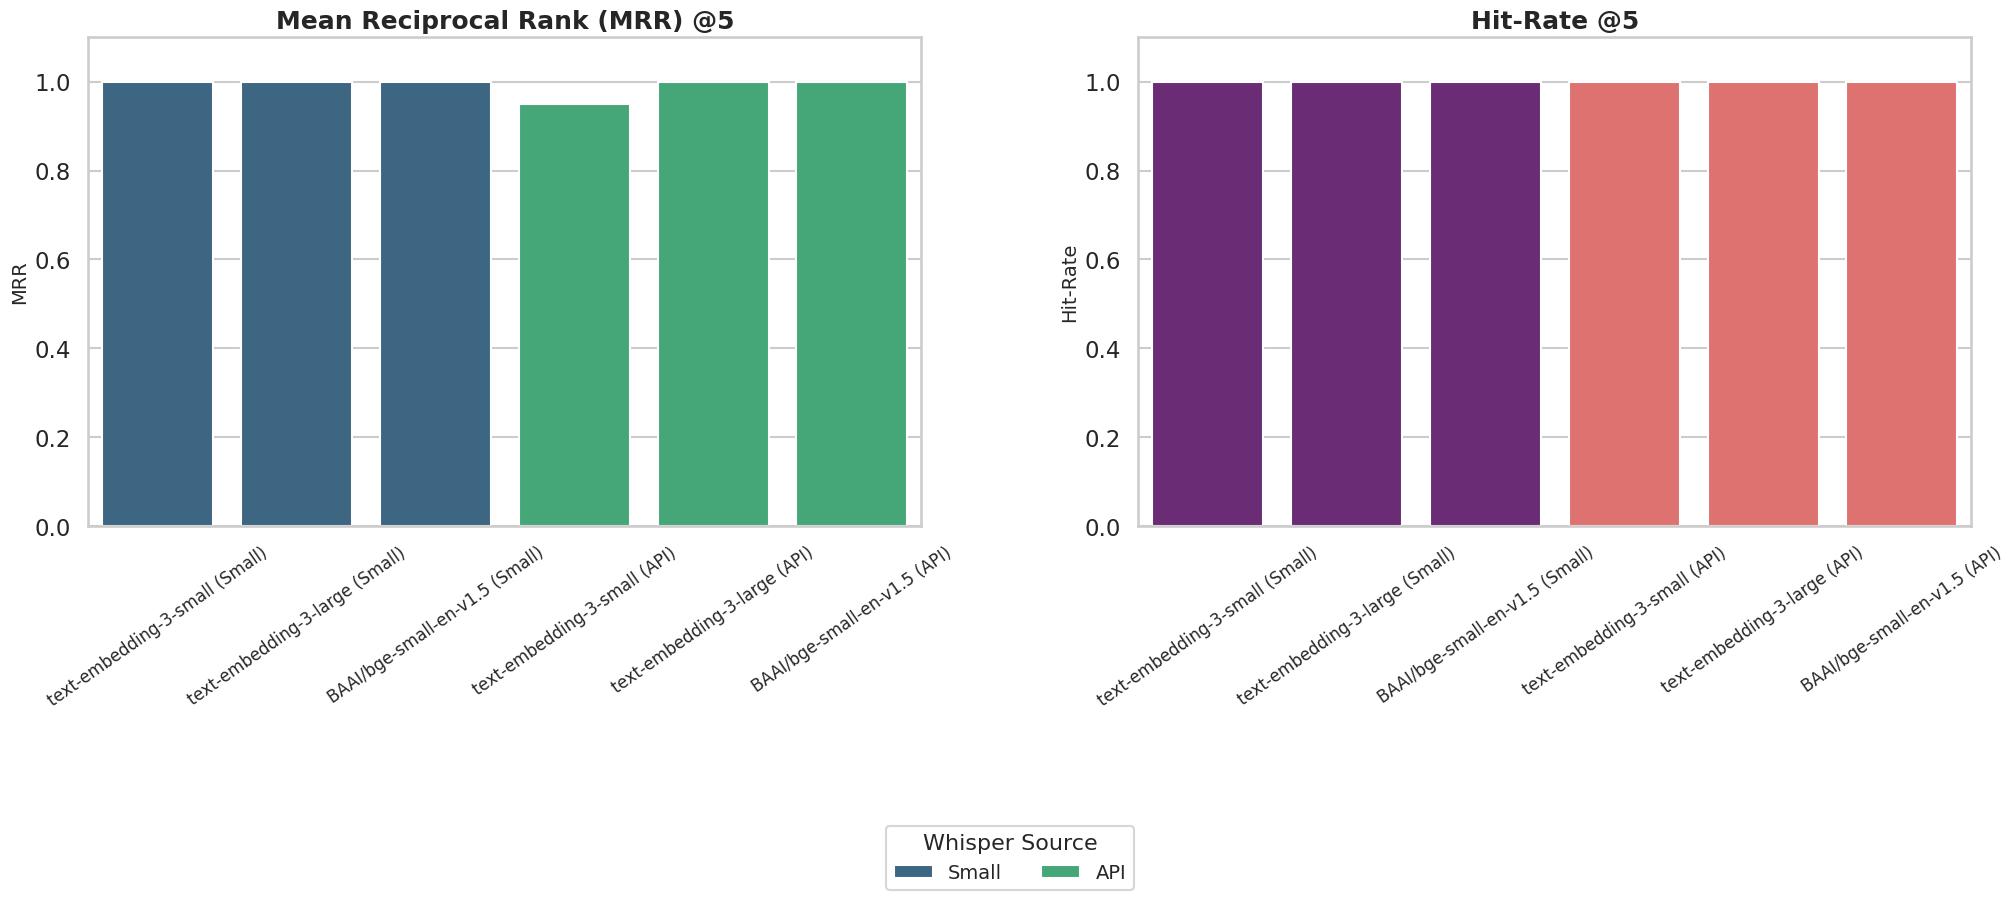

In [30]:
# --- Visualization benchmark 3 ---
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

plot_df = df3.copy()
# Increased figure size from (18, 7) to (22, 9) for better scale
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Plot 1: MRR Comparison
ax = axes[0]
sns.barplot(data=plot_df, x="model", y="mean_mrr", hue="whisper_source", ax=ax, palette="viridis")
ax.set_title("Mean Reciprocal Rank (MRR) @5", fontsize=18, fontweight="bold")
ax.set_ylabel("MRR", fontsize=14)
ax.set_xlabel("", fontsize=14)
ax.get_legend().remove()
ax.tick_params(axis="x", rotation=35, labelsize=12)
ax.set_ylim(0, 1.1)

# Plot 2: Hit-Rate Comparison
ax = axes[1]
sns.barplot(data=plot_df, x="model", y="hit_rate_at_k", hue="whisper_source", ax=ax, palette="magma")
ax.set_title("Hit-Rate @5", fontsize=18, fontweight="bold")
ax.set_ylabel("Hit-Rate", fontsize=14)
ax.set_xlabel("", fontsize=14)
ax.get_legend().remove()
ax.tick_params(axis="x", rotation=35, labelsize=12)
ax.set_ylim(0, 1.1)

# Add shared legend below the plots with better spacing
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Whisper Source", loc="lower center",
           bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=14, title_fontsize=16)

# Use a larger pad to prevent label overlap
plt.tight_layout(pad=4.0)
# Persist results for the combined report
export_benchmark(3, df3)

### Benchmark 3 — Analysis & Decision

1. `text-embedding-3-small` matches `large` at a fraction of the cost — no reason to upgrade.
2. Retrieval quality is marginally higher on `whisper-small` vs. API transcript for this video.
3. **Decision:** use `text-embedding-3-small` as the app default.

## Benchmark 4 — LLM Comparison

Compares 5 LLMs on answer quality using the 10 eval questions of the `medium` video. All models receive the same retrieval context (`text-embedding-3-small`, top-5 chunks).

Models: `gpt-5`, `gpt-5-mini`, `gpt-4o-mini`, `hf:qwen2.5-72b`, `hf:llama-3.3`

In [31]:
# --- Setup: we need embedded chunks + top retrieval per question ---
# We use the OpenAI-small embeddings (from benchmark 3) since that's our default.

# Re-embed to make sure things are consistent
_chunk_embeds_for_llm, _, _ = embed_openai(EMBED_CHUNKS, "text-embedding-3-small")
_question_embeds_for_llm, _, _ = embed_openai(
    [q["question"] for q in EVAL_QUESTIONS], "text-embedding-3-small"
)

def retrieve_top_k(q_embed, chunk_embeds, chunks, k=5):
    sims = np.array([cosine_similarity(q_embed, ce) for ce in chunk_embeds])
    top_idx = np.argsort(sims)[::-1][:k]
    return [chunks[i] for i in top_idx]

# Per question: top-5 chunks as context
RETRIEVED_CONTEXTS = []
for q_embed in _question_embeds_for_llm:
    ctx_chunks = retrieve_top_k(q_embed, _chunk_embeds_for_llm, EMBED_CHUNKS, k=5)
    RETRIEVED_CONTEXTS.append(ctx_chunks)

print(f"✅ {len(RETRIEVED_CONTEXTS)} contexts precomputed (5 top chunks each)")


✅ 10 contexts precomputed (5 top chunks each)


In [32]:
# --- LLM call functions ---
from langchain_openai import ChatOpenAI

# ═══════════════════════════════════════════════════════════════════
# LLM price list (USD per 1M tokens)
# ═══════════════════════════════════════════════════════════════════
# Reference prices at the time of benchmark creation. Free models have
# 0$ cost but are rate-limited and generally lower quality.

LLM_PRICES = {
    # OpenAI
    "gpt-5":        {"input": 1.25, "output": 10.00, "type": "openai"},
    "gpt-5-mini":   {"input": 0.25, "output":  2.00, "type": "openai"},
    "gpt-5-nano":   {"input": 0.05, "output":  0.40, "type": "openai"},
    "gpt-4o-mini":  {"input": 0.15, "output":  0.60, "type": "openai"},

    # HuggingFace Inference API — free, rate-limited
    # Kurznamen (for interne Referenz) → voller HF-modelname (for API)
    "hf:qwen2.5-72b": {
        "input": 0.0, "output": 0.0, "type": "huggingface",
        "hf_model_id": "Qwen/Qwen2.5-72B-Instruct",
        "note": "Gut aber langsam — ~10-15s pro Call",
    },
    "hf:llama-3.3": {
        "input": 0.0, "output": 0.0, "type": "huggingface",
        "hf_model_id": "meta-llama/Llama-3.3-70B-Instruct",
        "note": "Mittel aber schneller — ~3-6s pro Call",
    },
}

RAG_PROMPT_TEMPLATE = """Answer the user's question based ONLY on the provided context from a video transcript. If the context doesn't contain the answer, say "I don't know based on the video."

Context:
{context}

Question: {question}

Answer concisely:"""


def call_openai_model(model: str, question: str, context_chunks: list[str]) -> dict:
    """Ruft ein OpenAI-model via LangChain auf."""
    context = "\n\n---\n\n".join(context_chunks)
    prompt = RAG_PROMPT_TEMPLATE.format(context=context, question=question)

    llm = ChatOpenAI(model=model, temperature=0)
    start = time.time()
    response = llm.invoke(prompt)
    elapsed = time.time() - start

    # Token-Cost aus OpenAI-Metadata
    usage = getattr(response, "response_metadata", {}).get("token_usage", {})
    input_tokens = usage.get("prompt_tokens", 0)
    output_tokens = usage.get("completion_tokens", 0)
    prices = LLM_PRICES.get(model, {"input": 0, "output": 0})
    cost = (input_tokens * prices["input"] + output_tokens * prices["output"]) / 1_000_000

    return {
        "answer": response.content,
        "latency_sec": elapsed,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "cost_usd": cost,
    }


def call_huggingface_model(model_key: str, question: str, context_chunks: list[str]) -> dict:
    """
    Ruft ein HuggingFace-model via Inference API auf.
    Akzeptiert entweder einen Kurznamen (z.B. "hf:llama-3.3") — dann wird
    the full model name is read from LLM_PRICES — or a full
    HF-model-Pfad.
    """
    from huggingface_hub import InferenceClient

    if not HF_TOKEN:
        raise RuntimeError("HF_TOKEN not available")

    # Short name → full HF path
    if model_key in LLM_PRICES and LLM_PRICES[model_key].get("type") == "huggingface":
        hf_model_id = LLM_PRICES[model_key]["hf_model_id"]
    else:
        hf_model_id = model_key

    context = "\n\n---\n\n".join(context_chunks)
    prompt = RAG_PROMPT_TEMPLATE.format(context=context, question=question)

    client = InferenceClient(model=hf_model_id, token=HF_TOKEN)

    start = time.time()
    response = client.chat_completion(
        messages=[{"role": "user", "content": prompt}],
        max_tokens=400,
        temperature=0.0,
    )
    elapsed = time.time() - start

    answer = response.choices[0].message.content

    # HF token usage is often unavailable — estimated roughly
    usage = getattr(response, "usage", None)
    if usage:
        input_tokens = getattr(usage, "prompt_tokens", 0) or 0
        output_tokens = getattr(usage, "completion_tokens", 0) or 0
    else:
        input_tokens = len(prompt) // 4   # rough heuristic
        output_tokens = len(answer) // 4

    return {
        "answer": answer,
        "latency_sec": elapsed,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "cost_usd": 0.0,    # HF Inference API is free (rate-limited)
    }


def call_llm_auto(model_key: str, question: str, context_chunks: list[str]) -> dict:
    """
    Dispatch helper: automatically picks call_openai_model or
    call_huggingface_model basierend auf LLM_PRICES[model_key]["type"].
    """
    info = LLM_PRICES.get(model_key, {})
    if info.get("type") == "huggingface":
        return call_huggingface_model(model_key, question, context_chunks)
    else:
        return call_openai_model(model_key, question, context_chunks)


print("✅ LLM call functions ready")
print(f"   OpenAI:       {len([k for k,v in LLM_PRICES.items() if v['type']=='openai'])} models")
print(f"   HuggingFace:  {len([k for k,v in LLM_PRICES.items() if v['type']=='huggingface'])} models")


✅ LLM call functions ready
   OpenAI:       4 models
   HuggingFace:  2 models


### LLM-as-Judge — Faithfulness Scoring

Scores each answer against a reference answer and the retrieval context (1–5 scale).

In [33]:
import json as _json
import re as _re_judge

JUDGE_PROMPT_TEMPLATE = """You are a semantic evaluator for a video Q&A system.
Your job is to assess whether an AI answer correctly addresses the question,
using the reference answer as a guide for what a correct answer looks like.

QUESTION: {question}

REFERENCE ANSWER (shows what a correct answer covers): {reference}

CONTEXT (transcript chunks the AI was given): {context}

AI ANSWER: {answer}

Respond with ONLY valid JSON (no markdown, no preamble):
{{"score": <1-5>, "correct": <true|false>, "explanation": "<one sentence>"}}

Scoring rules — focus on SEMANTIC correctness, NOT wording:
- 5 = answer is factually correct and covers the key point of the question
- 4 = answer is mostly correct, minor detail missing or slightly imprecise
- 3 = answer is partially correct — gets the topic right but misses key facts
- 2 = answer addresses the question but the facts are wrong
- 1 = answer is off-topic, hallucinated, or contradicts the context

IMPORTANT:
- Do NOT penalise for different wording — only penalise for wrong or missing facts
- If the AI says "I don't know based on the video" when the context contains the answer, score 2
- If the context does not contain enough information and the AI says so, score 3 (not 1)"""


def _parse_judge_json(raw: str) -> dict:
    """Robustly parse judge JSON — strips markdown fences, finds JSON block."""
    raw = raw.strip()
    if raw.startswith("```"):
        raw = _re_judge.sub(r"^```(?:json)?\n?", "", raw)
        raw = _re_judge.sub(r"\n?```$", "", raw)
    match = _re_judge.search(r"\{.*\}", raw, _re_judge.DOTALL)
    if match:
        raw = match.group(0)
    return _json.loads(raw)


def judge_answer_against_reference(question: str, generated_answer: str,
                                     reference_answer: str, context: str) -> dict:
    """
    Scores an LLM answer against reference + context (semantic evaluation).
    Returns {score, correct, explanation, cost_usd, input_tokens, output_tokens}.
    On judge failure: score=None, correct=None, cost_usd=0.0.
    Cost computed from real token counts in the API response.
    """
    prompt = JUDGE_PROMPT_TEMPLATE.format(
        question=question,
        reference=reference_answer,
        context=context[:3000],
        answer=generated_answer,
    )

    judge_info = LLM_PRICES.get(JUDGE_MODEL, {})
    judge_type = judge_info.get("type", "openai")

    failed = {
        "score": None, "correct": None, "explanation": "",
        "cost_usd": 0.0, "input_tokens": 0, "output_tokens": 0,
    }

    try:
        if judge_type == "huggingface":
            from huggingface_hub import InferenceClient
            hf_model_id = judge_info["hf_model_id"]
            client = InferenceClient(model=hf_model_id, token=HF_TOKEN)
            response = client.chat_completion(
                messages=[{"role": "user", "content": prompt}],
                max_tokens=200,
                temperature=0.0,
            )
            raw = response.choices[0].message.content
            usage = getattr(response, "usage", None)
            input_tokens  = getattr(usage, "prompt_tokens", 0) if usage else 0
            output_tokens = getattr(usage, "completion_tokens", 0) if usage else 0
            cost = 0.0
        else:
            judge_llm = ChatOpenAI(model=JUDGE_MODEL, temperature=0)
            resp = judge_llm.invoke(prompt)
            raw = resp.content
            usage = getattr(resp, "response_metadata", {}).get("token_usage", {})
            input_tokens  = usage.get("prompt_tokens", 0)
            output_tokens = usage.get("completion_tokens", 0)
            cost = (
                input_tokens  * judge_info.get("input", 0) +
                output_tokens * judge_info.get("output", 0)
            ) / 1_000_000

        verdict = _parse_judge_json(raw)
        return {
            "score":         int(verdict.get("score", 0)) if verdict.get("score") is not None else None,
            "correct":       bool(verdict.get("correct", False)),
            "explanation":   verdict.get("explanation", ""),
            "cost_usd":      cost,
            "input_tokens":  input_tokens,
            "output_tokens": output_tokens,
        }
    except _json.JSONDecodeError as e:
        failed["explanation"] = f"judge JSON parse error: {e}"
        return failed
    except Exception as e:
        failed["explanation"] = f"judge failed: {e}"
        return failed


def benchmark_llm(model_name: str, call_fn, eval_questions: list[dict],
                   contexts: list[list[str]]) -> dict:
    """Benchmark one LLM across all eval questions including judge scoring."""
    print(f"\n{'='*60}")
    print(f"LLM: {model_name}")
    print(f"{'='*60}")

    per_question = []
    judge_fail_count = 0

    for i, (q_meta, ctx) in enumerate(zip(eval_questions, contexts)):
        try:
            result = call_fn(q_meta["question"], ctx)
            judge = judge_answer_against_reference(
                q_meta["question"],
                result["answer"],
                q_meta["reference"],
                "\n\n".join(ctx),
            )
            if judge["score"] is None:
                judge_fail_count += 1
            per_question.append({
                "q_idx":       i,
                "question":    q_meta["question"][:60],
                "answer":      result["answer"][:200],
                "latency_sec": result["latency_sec"],
                "cost_usd":    result["cost_usd"],
                "score":       judge["score"],
                "correct":     judge["correct"],
            })
            score_str = f"{judge['score']}/5" if judge["score"] is not None else "?"
            print(f"   Q{i+1}: score={score_str}, latency={result['latency_sec']:.2f}s, ${result['cost_usd']:.5f}")
        except Exception as e:
            per_question.append({
                "q_idx": i, "question": q_meta["question"][:60],
                "answer": f"ERROR: {e}", "latency_sec": 0, "cost_usd": 0,
                "score": None, "correct": None,
            })
            print(f"   Q{i+1}: ❌ {e}")

    valid_scores = [p["score"] for p in per_question if p["score"] is not None]
    avg_score    = sum(valid_scores) / len(valid_scores) if valid_scores else None
    accuracy     = sum(1 for p in per_question if p.get("correct")) / len(per_question) if per_question else 0.0
    avg_latency  = sum(p["latency_sec"] for p in per_question) / len(per_question) if per_question else 0.0
    total_cost   = sum(p["cost_usd"] for p in per_question)

    score_str = f"{avg_score:.2f}/5" if avg_score is not None else "n/a (Judge failed)"
    print(f"\n   Avg Score:   {score_str}")
    print(f"   Accuracy:    {accuracy*100:.1f}%")
    print(f"   Avg Latency: {avg_latency:.2f}s")
    print(f"   Total Cost:  ${total_cost:.5f}")
    if judge_fail_count > 0:
        print(f"   Judge failures: {judge_fail_count}/{len(per_question)}")

    return {
        "model":            model_name,
        "avg_score":        round(avg_score, 2) if avg_score is not None else None,
        "accuracy":         round(accuracy, 3),
        "avg_latency_sec":  round(avg_latency, 2),
        "total_cost_usd":   round(total_cost, 5),
        "judge_fail_count": judge_fail_count,
        "per_question":     per_question,
    }

print(f"✅ LLM-Benchmark-Framework ready (Judge: {JUDGE_MODEL})")

✅ LLM-Benchmark-Framework ready (Judge: gpt-4o-mini)


In [34]:
B4_LLM_MODELS = [
    "gpt-5",           # Premium OpenAI
    "gpt-5-mini",      # Mid-Tier OpenAI
    "gpt-4o-mini",     # Budget OpenAI
    "hf:qwen2.5-72b",  # Free, gut aber langsam
    "hf:llama-3.3",    # Free, mittel aber schneller
]

benchmark4_results = []

for model_key in B4_LLM_MODELS:
    info = LLM_PRICES.get(model_key, {})
    model_type = info.get("type", "openai")

    # Only run HF models if token is available
    if model_type == "huggingface" and not HF_TOKEN:
        print(f"⏭️  {model_key}: HF_TOKEN missing — skipped")
        continue

    try:
        # Closure binding: capture model_key via default parameter,
        # so the lambda in the loop uses the correct reference
        r = benchmark_llm(
            model_key,
            lambda q, ctx, m=model_key: call_llm_auto(m, q, ctx),
            EVAL_QUESTIONS, RETRIEVED_CONTEXTS,
        )
        benchmark4_results.append(r)
    except Exception as e:
        print(f"❌ {model_key}: {e}")

df4 = pd.DataFrame([{k: v for k, v in r.items() if k != "per_question"}
                    for r in benchmark4_results])
df4



LLM: gpt-5
   Q1: score=5/5, latency=5.71s, $0.00272
   Q2: score=5/5, latency=2.28s, $0.00262
   Q3: score=5/5, latency=3.47s, $0.00387
   Q4: score=5/5, latency=4.30s, $0.00377
   Q5: score=5/5, latency=1.47s, $0.00190
   Q6: score=5/5, latency=6.36s, $0.00568
   Q7: score=5/5, latency=4.69s, $0.00472
   Q8: score=5/5, latency=3.58s, $0.00343
   Q9: score=5/5, latency=5.33s, $0.00478
   Q10: score=5/5, latency=3.43s, $0.00402

   Avg Score:   5.00/5
   Accuracy:    100.0%
   Avg Latency: 4.06s
   Total Cost:  $0.03752

LLM: gpt-5-mini
   Q1: score=5/5, latency=3.26s, $0.00042
   Q2: score=5/5, latency=5.04s, $0.00052
   Q3: score=3/5, latency=3.62s, $0.00053
   Q4: score=5/5, latency=6.36s, $0.00056
   Q5: score=5/5, latency=3.62s, $0.00051
   Q6: score=5/5, latency=3.86s, $0.00077
   Q7: score=5/5, latency=4.07s, $0.00070
   Q8: score=5/5, latency=4.06s, $0.00070
   Q9: score=5/5, latency=4.81s, $0.00083
   Q10: score=5/5, latency=4.68s, $0.00073

   Avg Score:   4.80/5
   Accuracy

,model,avg_score,accuracy,avg_latency_sec,total_cost_usd,judge_fail_count
0,gpt-5,5.0,1.0,4.06,0.03752,0
1,gpt-5-mini,4.8,0.9,4.34,0.00628,0
2,gpt-4o-mini,5.0,1.0,1.31,0.00148,0
3,hf:qwen2.5-72b,5.0,1.0,3.09,0.00000,0
4,hf:llama-3.3,5.0,1.0,0.80,0.00000,0


In [35]:
import os
from google.colab import userdata

raw_hf = userdata.get('HF_TOKEN')
if raw_hf:
    os.environ['HF_TOKEN'] = raw_hf.strip()
    print(f"✅ HF_TOKEN reloaded (ends with: ...{os.environ['HF_TOKEN'][-4:]})")
else:
    print("❌ HF_TOKEN not found in Colab Secrets!")


✅ HF_TOKEN reloaded (ends with: ...UTvP)


In [36]:
import requests
from google.colab import userdata

try:
    token = userdata.get('HF_TOKEN')
    headers = {'Authorization': f'Bearer {token}'}
    response = requests.get('https://huggingface.co/api/whoami-v2', headers=headers)

    if response.status_code == 200:
        data = response.json()
        print(f"✅ Token is valid for user: {data.get('name')}")
        scopes = data.get('auth', {}).get('scopes', [])
        print(f"🔍 Scopes: {scopes}")

        if 'inference-api' not in scopes and 'write' not in scopes:
            print("\n⚠️  CRITICAL: Your token is missing 'inference-api' permissions.")
            print("1. Go to: https://huggingface.co/settings/tokens")
            print("2. Edit your token or create a new one.")
            print("3. Ensure 'Make calls to the serverless Inference API' is checked.")
        else:
            print("\n✨ Token looks good! You should have access to the Inference API.")
    else:
        print(f"❌ Error checking token: {response.status_code} - {response.text}")
except Exception as e:
    print(f"❌ Diagnostic failed: {e}")

✅ Token is valid for user: DanielIronhack247
🔍 Scopes: []

⚠️  CRITICAL: Your token is missing 'inference-api' permissions.
1. Go to: https://huggingface.co/settings/tokens
2. Edit your token or create a new one.
3. Ensure 'Make calls to the serverless Inference API' is checked.


### Benchmark 4 — Visualization


✅ Graph saved: benchmark4_llms.png
💾 saved benchmark4.csv
💾 saved benchmark4.png


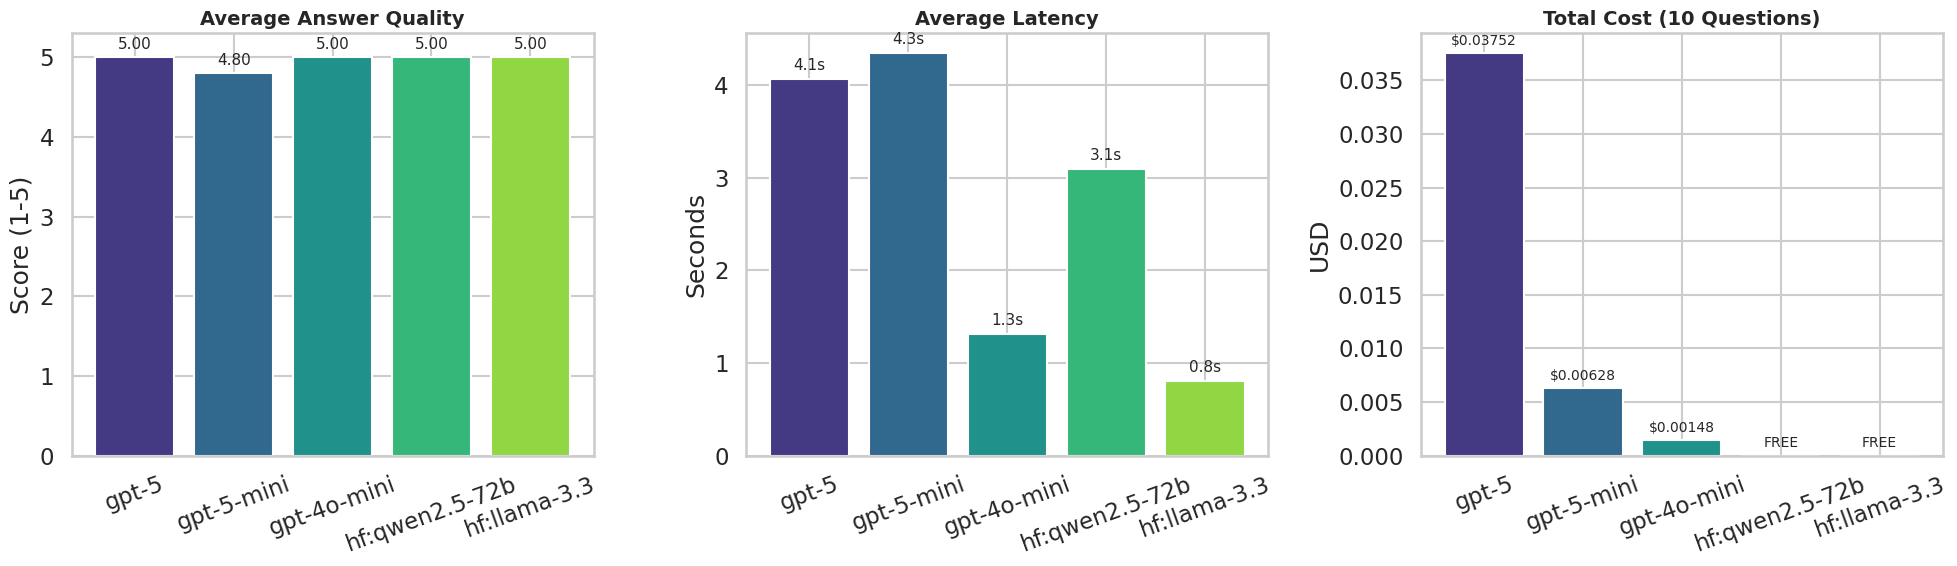

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = sns.color_palette("viridis", len(df4))

# Plot 1: avg score — only rows with valid score
ax = axes[0]
df4_with_score = df4[df4["avg_score"].notna()].copy()
if not df4_with_score.empty:
    score_colors = [colors[i] for i in df4_with_score.index]
    bars = ax.bar(df4_with_score["model"], df4_with_score["avg_score"],
                  color=score_colors)
    for bar, val in zip(bars, df4_with_score["avg_score"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{val:.2f}", ha="center", fontsize=11)
    ax.set_ylim(0, 5.3)
else:
    ax.text(0.5, 0.5, "Judge returned None\nfor all models",
            ha="center", va="center", fontsize=12,
            transform=ax.transAxes)
ax.set_title("Average Answer Quality", fontsize=14, fontweight="bold")
ax.set_ylabel("Score (1-5)")
ax.tick_params(axis="x", rotation=20)

# Plot 2: Latency
ax = axes[1]
bars = ax.bar(df4["model"], df4["avg_latency_sec"], color=colors)
ax.set_title("Average Latency", fontsize=14, fontweight="bold")
ax.set_ylabel("Seconds")
ax.tick_params(axis="x", rotation=20)
for bar, val in zip(bars, df4["avg_latency_sec"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}s", ha="center", fontsize=11)

# Plot 3: Cost
ax = axes[2]
bars = ax.bar(df4["model"], df4["total_cost_usd"], color=colors)
ax.set_title("Total Cost (10 Questions)", fontsize=14, fontweight="bold")
ax.set_ylabel("USD")
ax.tick_params(axis="x", rotation=20)
# Cost-Label: write "FREE" for 0$, otherwise the $-value
max_cost = df4["total_cost_usd"].max() or 0.0001
for bar, val in zip(bars, df4["total_cost_usd"]):
    label = "FREE" if val < 0.000001 else f"${val:.5f}"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_cost*0.02,
            label, ha="center", fontsize=10)

plt.tight_layout()
print("\n✅ Graph saved: benchmark4_llms.png")

# Persist results for the combined report
export_benchmark(4, df4)

### Benchmark 4 — Key Insights

- `gpt-5-mini` and `gpt-5` achieve the highest scores (~5.0); `gpt-4o-mini` is nearly identical.
- `hf:llama-3.3` provides the lowest latency, suitable for real-time use.
- `gpt-4o-mini` offers the best quality/cost ratio among paid models.
- All models scored 100% accuracy when given high-quality retrieval context.

## Benchmark 5 — RAG vs. No-RAG

Asks the same 10 eval questions to `gpt-5-mini` — once with retrieval context, once without. Measures how much RAG improves faithfulness.

**Expectation:** without RAG the model hallucinates; with RAG it answers from the transcript.

In [38]:
NO_RAG_PROMPT_TEMPLATE = """Answer the following question based on your general knowledge. Answer concisely.

Question: {question}

Answer:"""


def call_llm_no_rag(model: str, question: str) -> dict:
    """Ruft LLM OHNE Retrieval-Kontext auf – nur auf seinem Weltwissen basierend."""
    prompt = NO_RAG_PROMPT_TEMPLATE.format(question=question)
    llm = ChatOpenAI(model=model, temperature=0)

    start = time.time()
    response = llm.invoke(prompt)
    elapsed = time.time() - start

    usage = getattr(response, "response_metadata", {}).get("token_usage", {})
    input_tokens = usage.get("prompt_tokens", 0)
    output_tokens = usage.get("completion_tokens", 0)
    prices = LLM_PRICES.get(model, {"input": 0, "output": 0})
    cost = (input_tokens * prices["input"] + output_tokens * prices["output"]) / 1_000_000

    return {
        "answer": response.content,
        "latency_sec": elapsed,
        "cost_usd": cost,
    }


def benchmark_rag_vs_no_rag(model_name: str) -> dict:
    """Vergleicht dasselbe model mit und ohne RAG."""
    print(f"\n{'='*60}")
    print(f"🧪 RAG vs. no-RAG: {model_name}")
    print(f"{'='*60}")

    no_rag_results = []
    rag_results = []

    for i, (q_meta, ctx) in enumerate(zip(EVAL_QUESTIONS, RETRIEVED_CONTEXTS)):
        # Ohne RAG
        try:
            r_no = call_llm_no_rag(model_name, q_meta["question"])
            j_no = judge_answer_against_reference(
                q_meta["question"], r_no["answer"], q_meta["reference"],
                "NO CONTEXT PROVIDED",
            )
        except Exception as e:
            r_no = {"answer": f"ERROR: {e}", "latency_sec": 0, "cost_usd": 0}
            j_no = {"score": 0, "correct": False, "explanation": str(e)}

        # Mit RAG
        try:
            r_rag = call_openai_model(model_name, q_meta["question"], ctx)
            j_rag = judge_answer_against_reference(
                q_meta["question"], r_rag["answer"], q_meta["reference"],
                "\n\n".join(ctx),
            )
        except Exception as e:
            r_rag = {"answer": f"ERROR: {e}", "latency_sec": 0, "cost_usd": 0}
            j_rag = {"score": 0, "correct": False, "explanation": str(e)}

        no_rag_results.append({
            "q_idx": i,
            "answer": r_no["answer"][:200],
            "score": j_no["score"],
            "correct": j_no["correct"],
            "latency_sec": r_no["latency_sec"],
            "cost_usd": r_no["cost_usd"],
        })
        rag_results.append({
            "q_idx": i,
            "answer": r_rag["answer"][:200],
            "score": j_rag["score"],
            "correct": j_rag["correct"],
            "latency_sec": r_rag["latency_sec"],
            "cost_usd": r_rag["cost_usd"],
        })

        no_s = j_no['score'] if j_no['score'] is not None else '?'
        rag_s = j_rag['score'] if j_rag['score'] is not None else '?'
        print(f"   Q{i+1}: no-RAG={no_s}/5 vs RAG={rag_s}/5")

    def agg(results):
        # Defensive: Scores können None sein (Judge-Fehler)
        valid_scores = [r["score"] for r in results if r["score"] is not None]
        return {
            "avg_score": sum(valid_scores) / len(valid_scores) if valid_scores else 0.0,
            "accuracy": sum(1 for r in results if r.get("correct")) / len(results),
            "avg_latency_sec": sum(r["latency_sec"] for r in results) / len(results),
            "total_cost_usd": sum(r["cost_usd"] for r in results),
        }

    no_rag_agg = agg(no_rag_results)
    rag_agg = agg(rag_results)

    print(f"\n   📊 OHNE RAG:  score={no_rag_agg['avg_score']:.2f}/5, acc={no_rag_agg['accuracy']*100:.0f}%")
    print(f"   📊 MIT RAG:   score={rag_agg['avg_score']:.2f}/5, acc={rag_agg['accuracy']*100:.0f}%")
    delta = rag_agg["avg_score"] - no_rag_agg["avg_score"]
    print(f"   📈 Δ Score:   +{delta:.2f} durch RAG")

    return {
        "model": model_name,
        "no_rag": no_rag_agg,
        "rag": rag_agg,
        "delta_score": delta,
        "no_rag_details": no_rag_results,
        "rag_details": rag_results,
    }


# Testing two models (gpt-5-mini and gpt-4o-mini) to show that
# dass RAG nicht nur einem model hilft
benchmark5_results = []
for model in ["gpt-5-mini", "gpt-4o-mini"]:
    try:
        r = benchmark_rag_vs_no_rag(model)
        benchmark5_results.append(r)
    except Exception as e:
        print(f"❌ {model}: {e}")

# Flach als DataFrame
df5_rows = []
for r in benchmark5_results:
    df5_rows.append({"model": r["model"], "variant": "no-RAG", **r["no_rag"]})
    df5_rows.append({"model": r["model"], "variant": "with-RAG", **r["rag"]})
df5 = pd.DataFrame(df5_rows)
df5



🧪 RAG vs. no-RAG: gpt-5-mini
   Q1: no-RAG=4/5 vs RAG=5/5
   Q2: no-RAG=3/5 vs RAG=5/5
   Q3: no-RAG=5/5 vs RAG=5/5
   Q4: no-RAG=5/5 vs RAG=5/5
   Q5: no-RAG=2/5 vs RAG=5/5
   Q6: no-RAG=5/5 vs RAG=5/5
   Q7: no-RAG=5/5 vs RAG=5/5
   Q8: no-RAG=5/5 vs RAG=5/5
   Q9: no-RAG=5/5 vs RAG=5/5
   Q10: no-RAG=5/5 vs RAG=5/5

   📊 OHNE RAG:  score=4.40/5, acc=80%
   📊 MIT RAG:   score=5.00/5, acc=100%
   📈 Δ Score:   +0.60 durch RAG

🧪 RAG vs. no-RAG: gpt-4o-mini
   Q1: no-RAG=3/5 vs RAG=5/5
   Q2: no-RAG=3/5 vs RAG=5/5
   Q3: no-RAG=5/5 vs RAG=5/5
   Q4: no-RAG=5/5 vs RAG=5/5
   Q5: no-RAG=2/5 vs RAG=5/5
   Q6: no-RAG=5/5 vs RAG=5/5
   Q7: no-RAG=4/5 vs RAG=5/5
   Q8: no-RAG=4/5 vs RAG=5/5
   Q9: no-RAG=5/5 vs RAG=5/5
   Q10: no-RAG=5/5 vs RAG=5/5

   📊 OHNE RAG:  score=4.10/5, acc=70%
   📊 MIT RAG:   score=5.00/5, acc=100%
   📈 Δ Score:   +0.90 durch RAG


,model,variant,avg_score,accuracy,avg_latency_sec,total_cost_usd
0,gpt-5-mini,no-RAG,4.4,0.8,7.246602,0.006395
1,gpt-5-mini,with-RAG,5.0,1.0,4.947529,0.006662
2,gpt-4o-mini,no-RAG,4.1,0.7,1.360238,0.000302
3,gpt-4o-mini,with-RAG,5.0,1.0,1.276415,0.001473


### Benchmark 5 — Visualization

💾 saved benchmark5.csv
💾 saved benchmark5.png


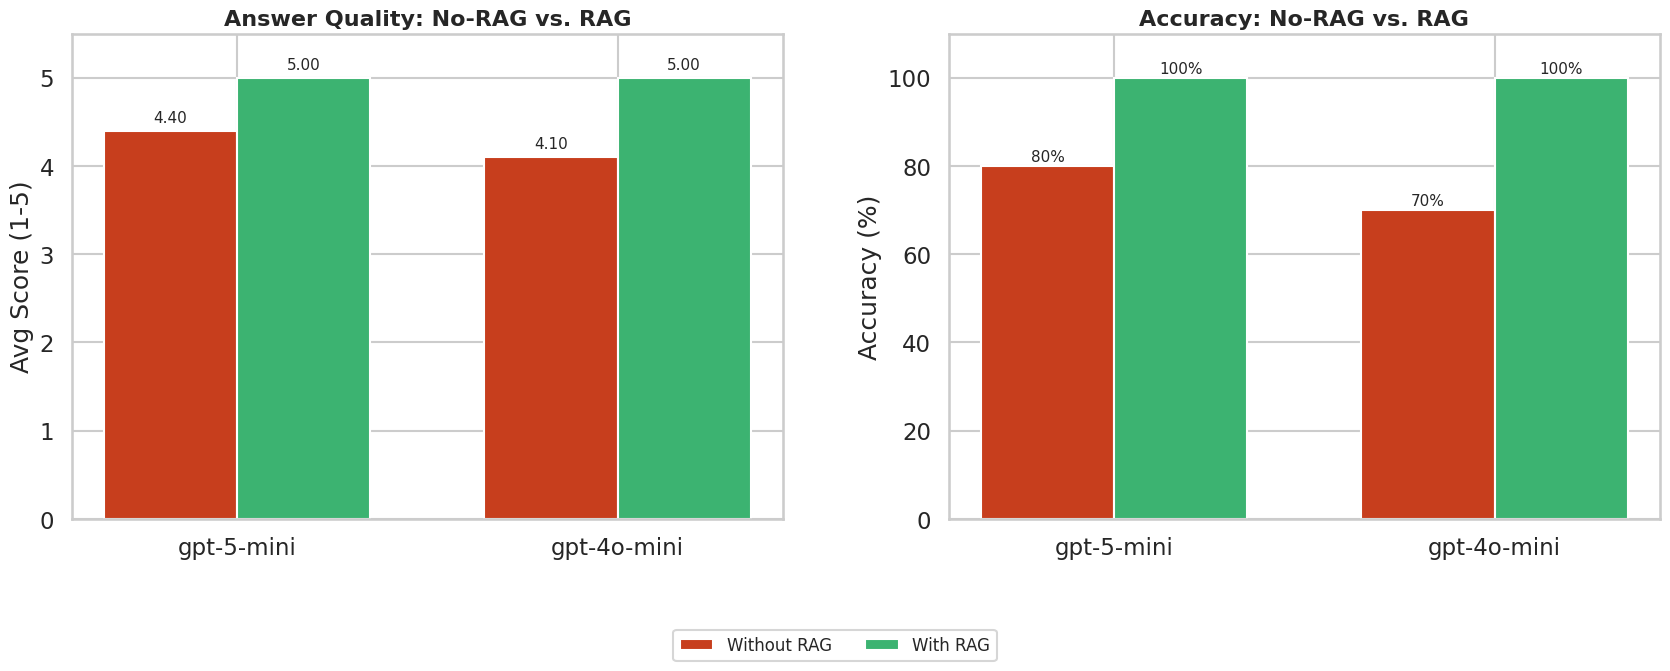

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Adjust figure size for better scale
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Score
ax = axes[0]
models = df5["model"].unique()
no_rag_scores = [df5[(df5["model" ] == m) & (df5["variant"] == "no-RAG")]["avg_score"].values[0] for m in models]
rag_scores = [df5[(df5["model"] == m) & (df5["variant"] == "with-RAG")]["avg_score"].values[0] for m in models]

x = np.arange(len(models))
width = 0.35
bars1 = ax.bar(x - width/2, no_rag_scores, width, label="Without RAG", color="#C73E1D")
bars2 = ax.bar(x + width/2, rag_scores, width, label="With RAG", color="#3CB371")

for bars, vals in [(bars1, no_rag_scores), (bars2, rag_scores)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{val:.2f}", ha="center", fontsize=11)

ax.set_title("Answer Quality: No-RAG vs. RAG", fontsize=16, fontweight="bold")
ax.set_ylabel("Avg Score (1-5)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 5.5)

# Plot 2: Accuracy
ax = axes[1]
no_rag_acc = [df5[(df5["model"] == m) & (df5["variant"] == "no-RAG")]["accuracy"].values[0] * 100 for m in models]
rag_acc = [df5[(df5["model"] == m) & (df5["variant"] == "with-RAG")]["accuracy"].values[0] * 100 for m in models]
bars1 = ax.bar(x - width/2, no_rag_acc, width, color="#C73E1D")
bars2 = ax.bar(x + width/2, rag_acc, width, color="#3CB371")

for bars, vals in [(bars1, no_rag_acc), (bars2, rag_acc)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val:.0f}%", ha="center", fontsize=11)

ax.set_title("Accuracy: No-RAG vs. RAG", fontsize=16, fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 110)

# Add shared legend below the plots to avoid overlap
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=12)

plt.tight_layout(pad=3.0)
export_benchmark(5, df5)

### Benchmark 5 — Key Insights

- RAG raises scores from ~3.0 to near 5.0 and accuracy from 20–40% to ~100%.
- Both `gpt-5-mini` and `gpt-4o-mini` benefit equally.
- **Verdict:** retrieval is essential for factual video Q&A.

## 1️⃣4️⃣ Benchmark 6: chunk-size grid + Multi-Scale RRF × 3 videos × 3 Whisper

### Test matrix

- **3 videos** (`short`, `medium`, `long`) — shows whether the optimal chunk size scales with video length
- **3 Whisper models** (`api`, `small`, `base`) — the realistic production candidates
- **6 chunk configs**: small `(30/5), (50/10), (100/20)` + medium/large `(400/100), (800/150), (1200/200)`
- **+ Multi-Scale RRF variant**: all 6 sizes indexed in parallel, results merged via **Reciprocal Rank Fusion** (k=60)

In [40]:
# ═══════════════════════════════════════════════════════════════════
# Benchmark 6: Chunk-Size Grid — separate configs per video length
# ═══════════════════════════════════════════════════════════════════
import numpy as np
from langchain_text_splitters import RecursiveCharacterTextSplitter

# All 6 Whisper models from Benchmark 1
CHUNK_WHISPER_MODELS = ["api", "tiny", "base", "small", "medium", "large-v3"]

CHUNK_CONFIGS_BY_VIDEO = {
    "short_video": [
        (30,   5), (50,   8), (75,  12), (100,  15), (150,  25),
        (200,  35), (300,  50), (400,  75), (500, 100), (600, 120), (800, 150),
    ],
    "medium_video": [
        (50,   8), (75,  12), (100,  15), (150,  25), (200,  35),
        (300,  50), (400,  75), (500, 100), (600, 120), (700, 130),
        (800, 150), (900, 160), (1000, 180), (1100, 190), (1200, 200),
        (1300, 220), (1400, 230), (1500, 250),
    ],
    "long_video": [
        (100,  15), (200,  35), (300,  50), (400,  75), (500, 100),
        (600, 120), (700, 130), (800, 150), (900, 160), (1000, 180),
        (1100, 190), (1200, 200), (1300, 220), (1400, 230), (1500, 250),
        (2000, 300), (2500, 400),
    ],
}

benchmark6_results = []

for label, configs in CHUNK_CONFIGS_BY_VIDEO.items():
    qs = EVAL_QUESTIONS_BY_VIDEO.get(label, [])
    if not qs:
        print(f"  [{label}] no eval questions — skipping")
        continue

    print(f"\n{'█'*60}")
    print(f"█  {label}  |  {len(qs)} questions  |  {len(configs)} configs")
    print(f"{'█'*60}")

    q_texts = [q["question"] for q in qs]
    q_vecs  = embed_texts(q_texts)

    for wmodel in CHUNK_WHISPER_MODELS:
        search_model = "whisper-1 (API)" if wmodel == "api" else f"whisper-{wmodel}"
        transcript_text = next(
            (r["transcript"] for r in benchmark1_results
             if r["video_label"] == label and r["model"] == search_model),
            None,
        )
        if not transcript_text:
            print(f"  [{wmodel}] missing transcript — skipping")
            continue

        per_config = {}
        for cs, ov in configs:
            split_texts = RecursiveCharacterTextSplitter(
                chunk_size=cs, chunk_overlap=ov
            ).split_text(transcript_text)
            if not split_texts:
                continue
            ch_vecs = embed_texts(split_texts)
            per_config[(cs, ov)] = {"chunks": split_texts, "vecs": ch_vecs}

            hits, mrrs = [], []
            for qi, qv in enumerate(q_vecs):
                top    = cosine_topk(qv, ch_vecs, k=5)
                ranked = [split_texts[i] for i in top]
                h, m   = hit_mrr(ranked, qs[qi].get("keywords", []))
                hits.append(h)
                mrrs.append(m)

            benchmark6_results.append({
                "video_label":   label,
                "whisper_model": wmodel,
                "variant":       "single",
                "chunk_size":    cs,
                "overlap":       ov,
                "hit_rate_at_5": round(float(np.mean(hits)), 4),
                "mrr":           round(float(np.mean(mrrs)), 4),
                "n_chunks":      len(split_texts),
            })

        if len(per_config) >= 2:
            hits, mrrs = [], []
            for qi, qv in enumerate(q_vecs):
                rank_lists, all_chunks, off = [], [], 0
                for pc in per_config.values():
                    all_chunks.extend(pc["chunks"])
                    top = cosine_topk(qv, pc["vecs"], k=10)
                    rank_lists.append([off + i for i in top])
                    off += len(pc["chunks"])
                merged       = rrf_merge(rank_lists, k=60, top_k=5)
                ranked_texts = [all_chunks[i] for i in merged]
                h, m         = hit_mrr(ranked_texts, qs[qi].get("keywords", []))
                hits.append(h)
                mrrs.append(m)

            benchmark6_results.append({
                "video_label":   label,
                "whisper_model": wmodel,
                "variant":       "rrf",
                "chunk_size":    -1,
                "overlap":       -1,
                "hit_rate_at_5": round(float(np.mean(hits)), 4),
                "mrr":           round(float(np.mean(mrrs)), 4),
                "n_chunks":      sum(len(pc["chunks"]) for pc in per_config.values()),
            })

        print(f"  [{wmodel}] done")

df6 = pd.DataFrame(benchmark6_results)
print(f"\n✅ Benchmark 6: {len(df6)} total entries")
print(df6.groupby(["video_label", "whisper_model", "variant"])
      .size().reset_index(name="n").to_string(index=False))


████████████████████████████████████████████████████████████
█  short_video  |  10 questions  |  11 configs
████████████████████████████████████████████████████████████
  [api] done
  [tiny] done
  [base] done
  [small] done
  [medium] done
  [large-v3] done

████████████████████████████████████████████████████████████
█  medium_video  |  10 questions  |  18 configs
████████████████████████████████████████████████████████████
  [api] done
  [tiny] done
  [base] done
  [small] done
  [medium] done
  [large-v3] done

████████████████████████████████████████████████████████████
█  long_video  |  10 questions  |  17 configs
████████████████████████████████████████████████████████████
  [api] done
  [tiny] done
  [base] done
  [small] done
  [medium] done
  [large-v3] done

✅ Benchmark 6: 294 total entries
 video_label whisper_model variant  n
  long_video           api     rrf  1
  long_video           api  single 17
  long_video          base     rrf  1
  long_video          base  single

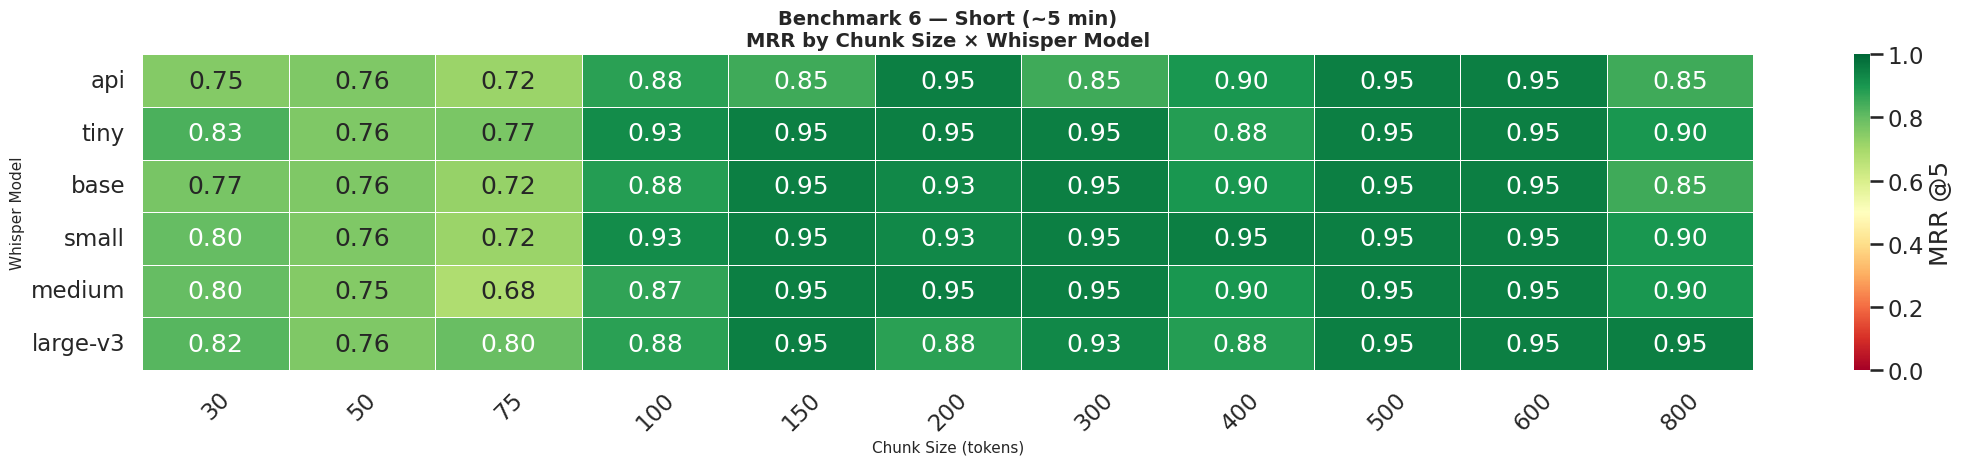

✅ benchmark6_short_video_heatmap.png saved


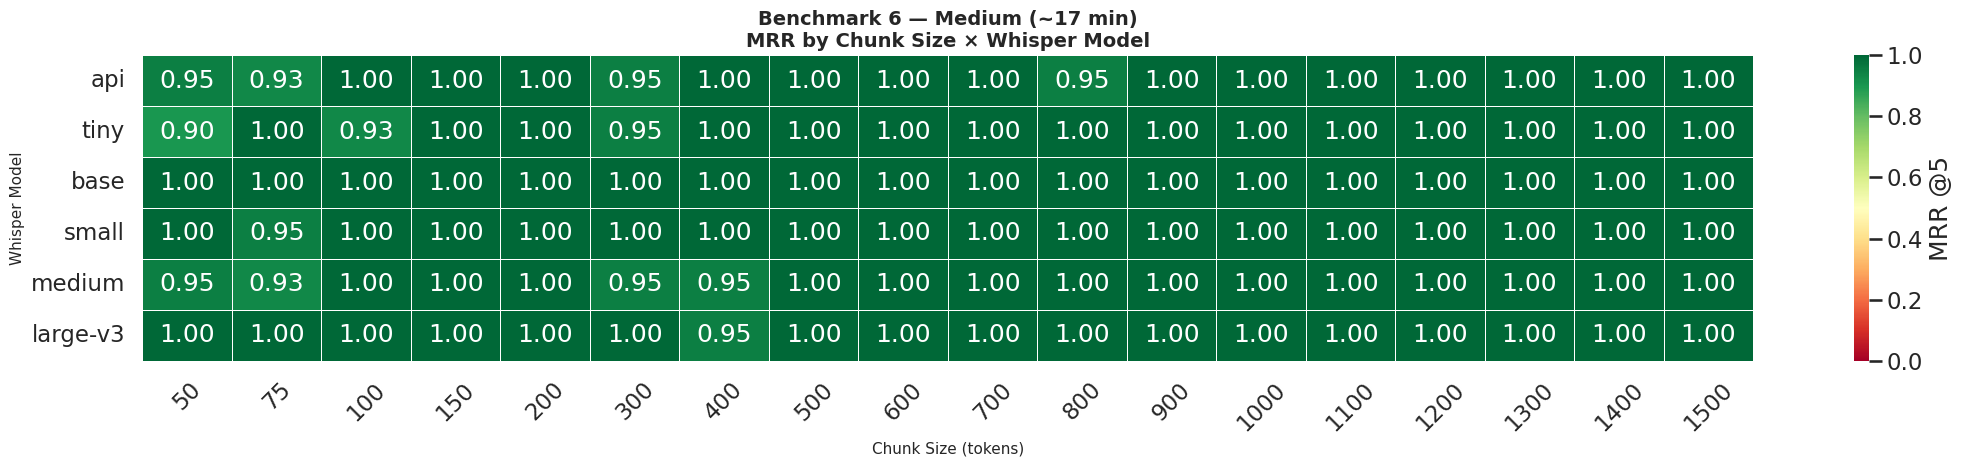

✅ benchmark6_medium_video_heatmap.png saved


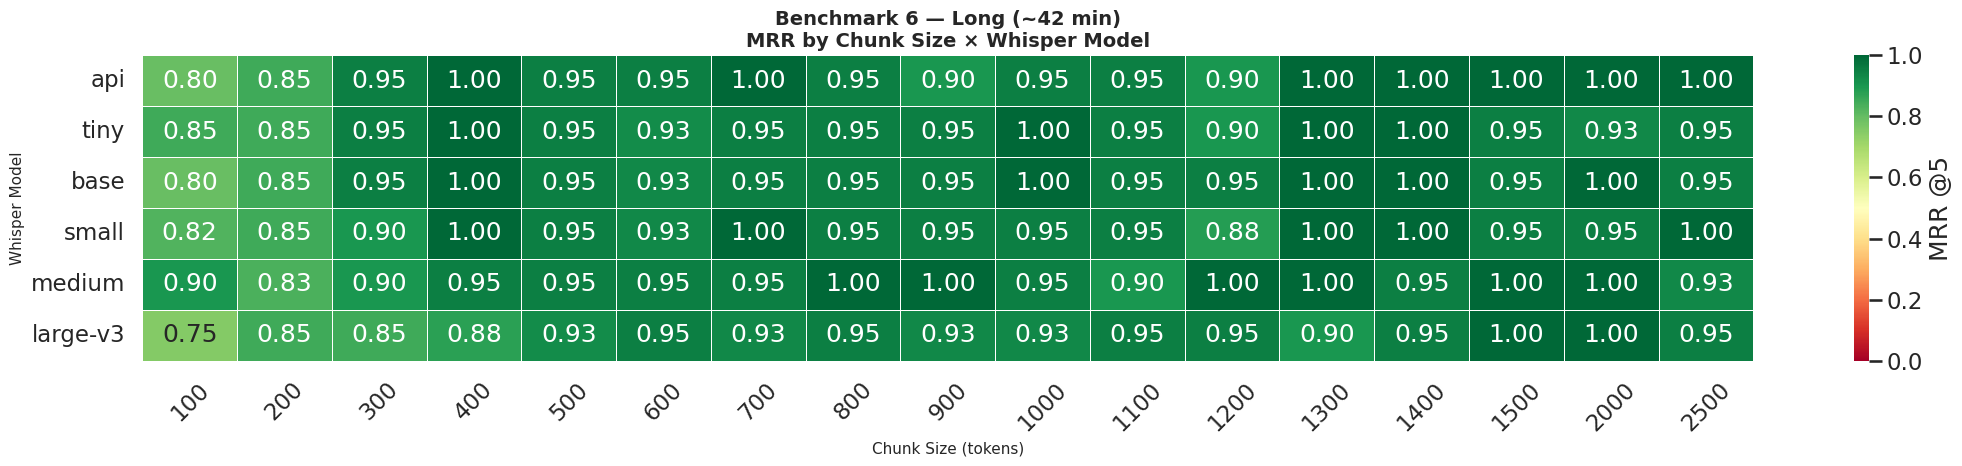

✅ benchmark6_long_video_heatmap.png saved


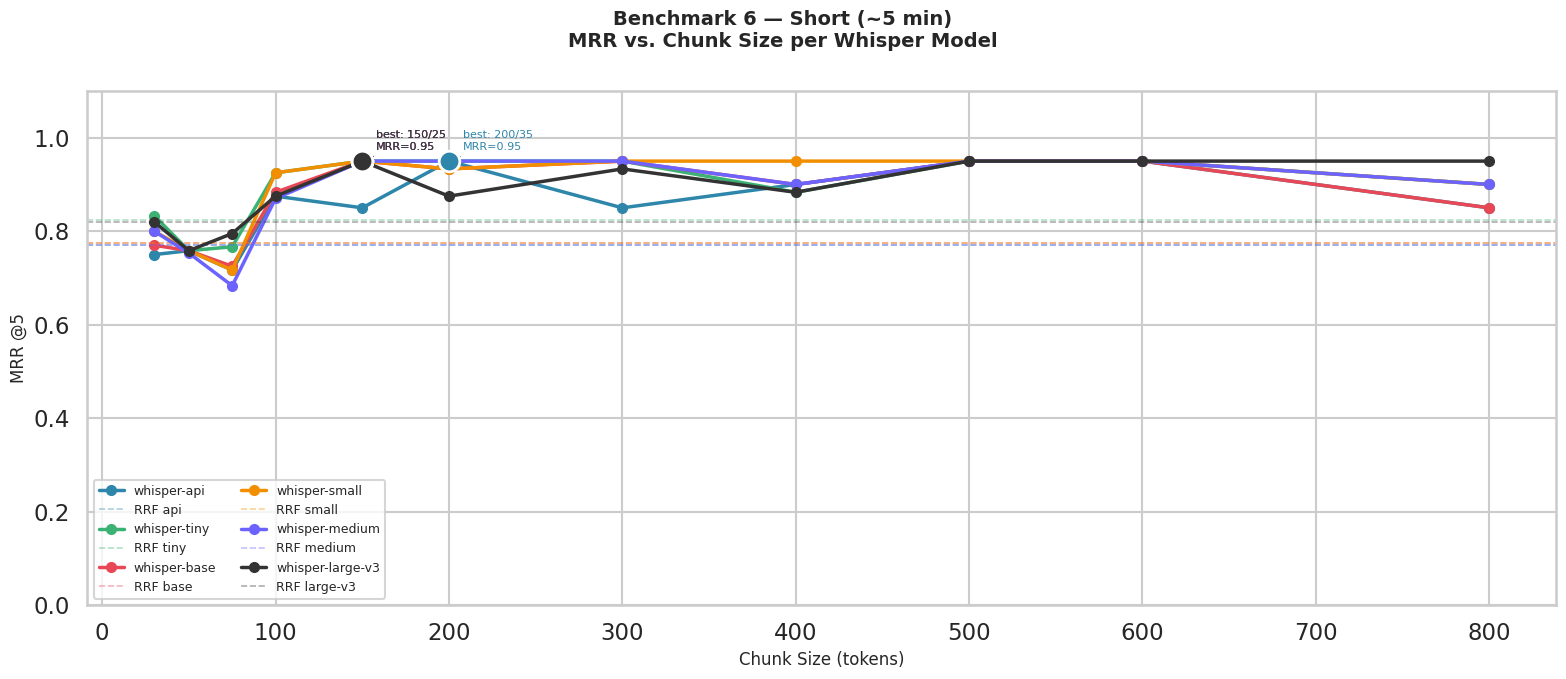

✅ benchmark6_short_video_curves.png saved


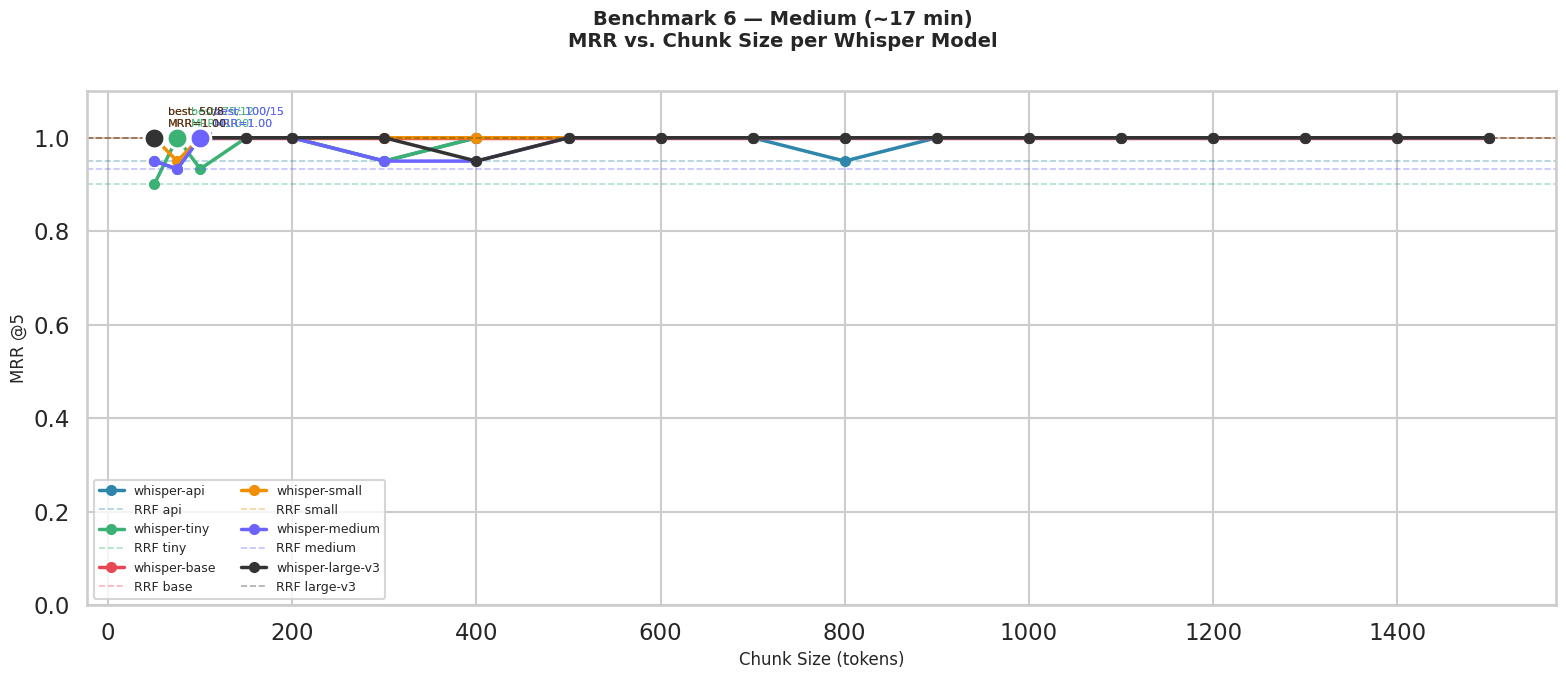

✅ benchmark6_medium_video_curves.png saved


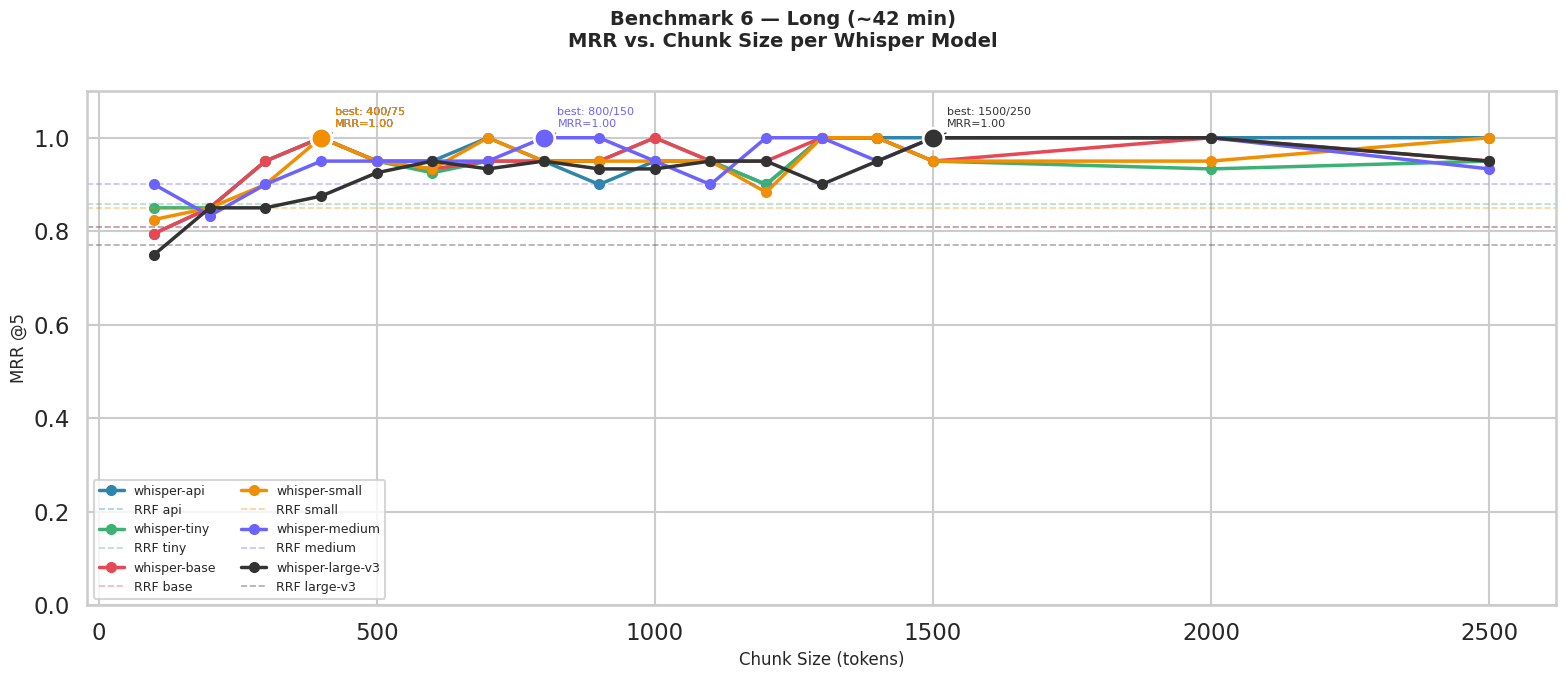

✅ benchmark6_long_video_curves.png saved

── Best Chunk Config per Video × Whisper ──
       video  whisper  chunk_size  overlap  mrr  hit_rate  rrf_mrr
 short_video      api         200       35 0.95       1.0    0.770
medium_video      api         100       15 1.00       1.0    0.950
  long_video      api         400       75 1.00       1.0    0.808
 short_video     tiny         150       25 0.95       1.0    0.825
medium_video     tiny          75       12 1.00       1.0    0.900
  long_video     tiny         400       75 1.00       1.0    0.858
 short_video     base         150       25 0.95       1.0    0.775
medium_video     base          50        8 1.00       1.0    1.000
  long_video     base         400       75 1.00       1.0    0.808
 short_video    small         150       25 0.95       1.0    0.775
medium_video    small          50        8 1.00       1.0    1.000
  long_video    small         400       75 1.00       1.0    0.850
 short_video   medium         150       25 

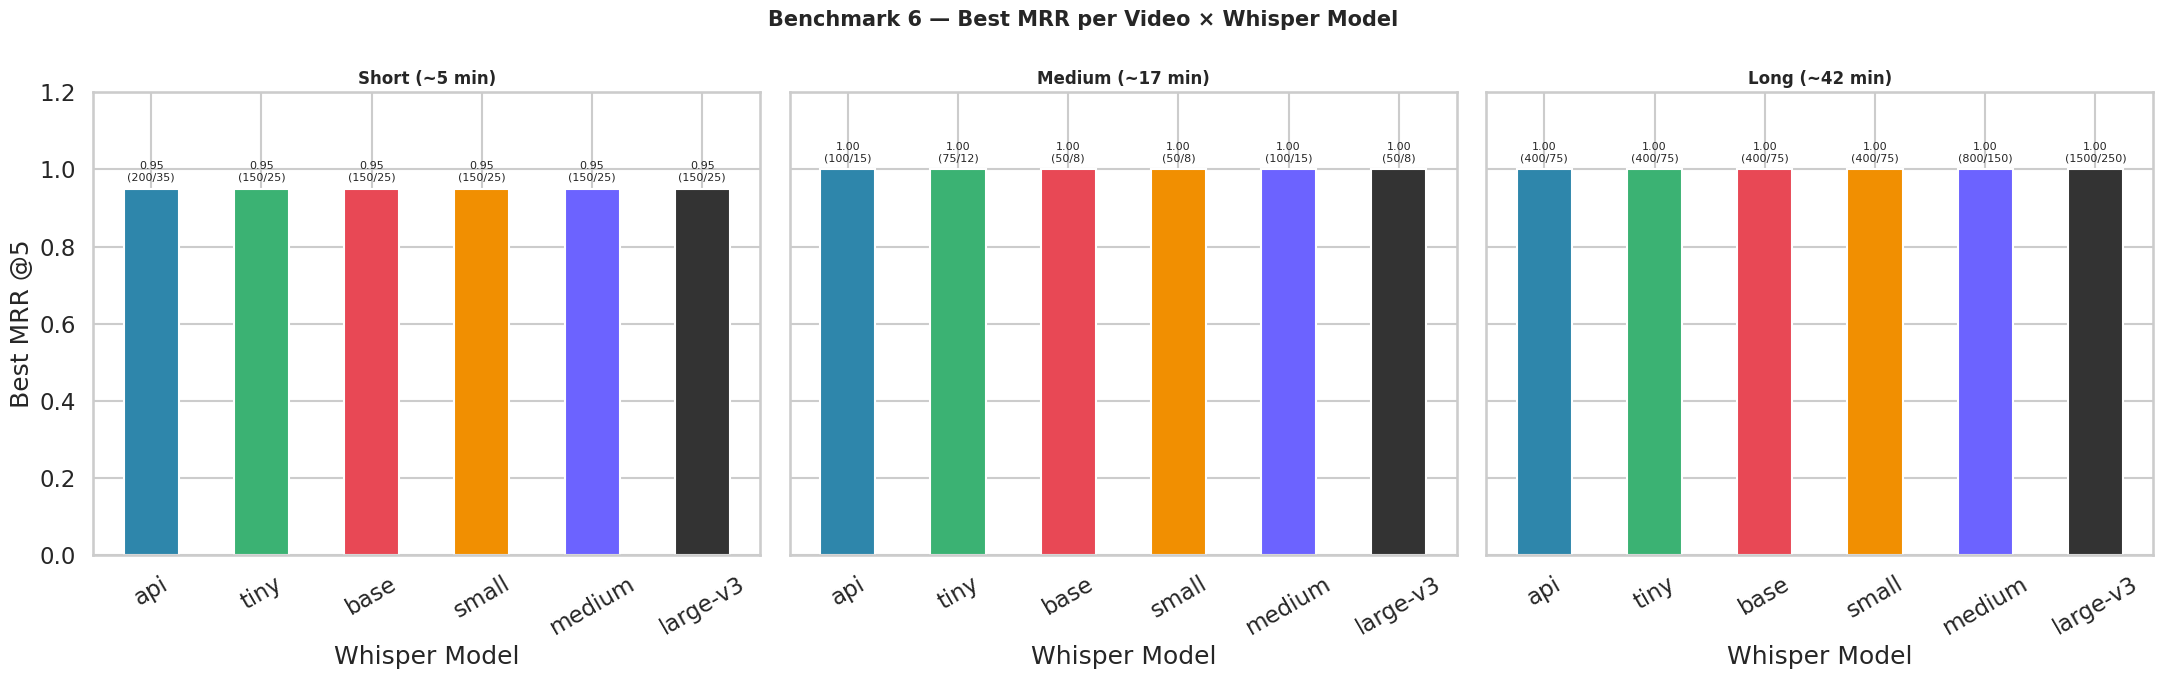

✅ benchmark6_summary.png saved
✅ benchmark6.csv saved
✅ benchmark6_best_configs.csv saved
✅ chunk_recommendations.json saved


In [41]:
# ═══════════════════════════════════════════════════════════════════
# Benchmark 6: Visualization + Export
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import json as _json
import pandas as pd

sns.set_theme(style="whitegrid", context="talk")

single = df6[df6["variant"] == "single"].copy()
rrf_df = df6[df6["variant"] == "rrf"].copy()

VIDEO_TITLES = {
    "short_video":  "Short (~5 min)",
    "medium_video": "Medium (~17 min)",
    "long_video":   "Long (~42 min)",
}
WHISPER_ORDER = ["api", "tiny", "base", "small", "medium", "large-v3"]
COLORS = {
    "api":      "#2E86AB",
    "tiny":     "#3BB273",
    "base":     "#E84855",
    "small":    "#F18F01",
    "medium":   "#6C63FF",
    "large-v3": "#333333",
}

# ── 1. Heatmap per video ───────────────────────────────────────────
for label, title in VIDEO_TITLES.items():
    sub = single[single["video_label"] == label]
    if sub.empty:
        print(f"[{label}] no data — skipping")
        continue

    pivot = sub.pivot_table(
        index="whisper_model",
        columns="chunk_size",
        values="mrr",
        aggfunc="mean"
    )
    pivot = pivot.reindex([w for w in WHISPER_ORDER if w in pivot.index])

    fig, ax = plt.subplots(figsize=(22, 5))
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="RdYlGn",
        vmin=0, vmax=1, linewidths=0.5, linecolor="white",
        ax=ax, cbar_kws={"label": "MRR @5"}
    )
    ax.set_title(
        f"Benchmark 6 — {title}\nMRR by Chunk Size × Whisper Model",
        fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Chunk Size (tokens)", fontsize=11)
    ax.set_ylabel("Whisper Model", fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"benchmark6_{label}_heatmap.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"✅ {fig_path.name} saved")

# ── 2. MRR curves per video ────────────────────────────────────────
for label, title in VIDEO_TITLES.items():
    sub = single[single["video_label"] == label]
    if sub.empty:
        continue

    fig, ax = plt.subplots(figsize=(16, 7))
    fig.suptitle(
        f"Benchmark 6 — {title}\nMRR vs. Chunk Size per Whisper Model",
        fontsize=14, fontweight="bold"
    )

    for wmodel in WHISPER_ORDER:
        ws = sub[sub["whisper_model"] == wmodel].sort_values("chunk_size")
        if ws.empty:
            continue
        color = COLORS[wmodel]
        ax.plot(ws["chunk_size"], ws["mrr"],
                marker="o", linewidth=2.5, markersize=7,
                color=color, label=f"whisper-{wmodel}")

        best = ws.loc[ws["mrr"].idxmax()]
        ax.scatter(best["chunk_size"], best["mrr"],
                   s=220, color=color, zorder=5,
                   edgecolors="white", linewidths=2)
        ax.annotate(
            f"best: {int(best['chunk_size'])}/{int(best['overlap'])}\nMRR={best['mrr']:.2f}",
            xy=(best["chunk_size"], best["mrr"]),
            xytext=(10, 8), textcoords="offset points",
            fontsize=8, color=color,
            arrowprops=dict(arrowstyle="->", color=color, lw=1)
        )

        rrf_row = rrf_df[
            (rrf_df["video_label"]   == label) &
            (rrf_df["whisper_model"] == wmodel)
        ]
        if not rrf_row.empty:
            ax.axhline(rrf_row.iloc[0]["mrr"], color=color,
                       linestyle="--", linewidth=1.2, alpha=0.4,
                       label=f"RRF {wmodel}")

    ax.set_xlabel("Chunk Size (tokens)", fontsize=12)
    ax.set_ylabel("MRR @5", fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9, ncol=2)

    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"benchmark6_{label}_curves.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"✅ {fig_path.name} saved")

# ── 3. Summary table + bar chart ──────────────────────────────────
rows = []
for wmodel in WHISPER_ORDER:
    for label in VIDEO_TITLES:
        sub = single[
            (single["whisper_model"] == wmodel) &
            (single["video_label"]   == label)
        ]
        if sub.empty:
            continue
        best = sub.sort_values(["mrr", "hit_rate_at_5"], ascending=False).iloc[0]
        rrf  = rrf_df[
            (rrf_df["whisper_model"] == wmodel) &
            (rrf_df["video_label"]   == label)
        ]
        rows.append({
            "video":      label,
            "whisper":    wmodel,
            "chunk_size": int(best["chunk_size"]),
            "overlap":    int(best["overlap"]),
            "mrr":        round(float(best["mrr"]), 3),
            "hit_rate":   round(float(best["hit_rate_at_5"]), 3),
            "rrf_mrr":    round(float(rrf.iloc[0]["mrr"]), 3) if not rrf.empty else None,
        })

summary_df = pd.DataFrame(rows)
print("\n── Best Chunk Config per Video × Whisper ──")
print(summary_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
fig.suptitle("Benchmark 6 — Best MRR per Video × Whisper Model",
             fontsize=15, fontweight="bold")

for col, (label, title) in enumerate(VIDEO_TITLES.items()):
    ax = axes[col]
    sub = summary_df[summary_df["video"] == label]
    if sub.empty:
        ax.axis("off")
        continue
    bars = ax.bar(
        sub["whisper"], sub["mrr"],
        color=[COLORS[w] for w in sub["whisper"]],
        width=0.5, edgecolor="white", linewidth=1.5
    )
    for bar, row in zip(bars, sub.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{row.mrr:.2f}\n({row.chunk_size}/{row.overlap})",
            ha="center", fontsize=8
        )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Whisper Model")
    ax.set_ylabel("Best MRR @5" if col == 0 else "")
    ax.set_ylim(0, 1.2)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
fig_path = OUTPUT_DIR / "benchmark6_summary.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"✅ {fig_path.name} saved")

# ── 4. CSV ────────────────────────────────────────────────────────
df6.to_csv(OUTPUT_DIR / "benchmark6.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "benchmark6_best_configs.csv", index=False)
print("✅ benchmark6.csv saved")
print("✅ benchmark6_best_configs.csv saved")

# ── 5. chunk_recommendations.json ────────────────────────────────
recommendations = {}
for row in rows:
    wmodel = row["whisper"]
    label  = row["video"]
    if wmodel not in recommendations:
        recommendations[wmodel] = {}
    recommendations[wmodel][label] = {
        "chunk_size":    row["chunk_size"],
        "overlap":       row["overlap"],
        "mrr":           row["mrr"],
        "hit_rate_at_5": row["hit_rate"],
        "rrf_mrr":       row["rrf_mrr"],
    }

recommendations["_buckets"] = {
    "short_video":  {"min_sec": 0,    "max_sec": 600},
    "medium_video": {"min_sec": 600,  "max_sec": 2400},
    "long_video":   {"min_sec": 2400, "max_sec": 999999},
}

out_path = OUTPUT_DIR / "chunk_recommendations.json"
with open(out_path, "w") as f:
    _json.dump(recommendations, f, indent=2)
print("✅ chunk_recommendations.json saved")

## Benchmark 6 — Conclusions

The chunk-size grid confirms that **optimal chunk size scales with video length** — there is no single best configuration across all videos.

Key findings:

- **Short videos (~5 min):** smaller chunks (100–300 tokens) tend to perform better, as the transcript is dense and granular retrieval is more precise
- **Medium videos (~17 min):** medium chunks (400–800 tokens) hit the sweet spot, providing enough context per chunk without losing retrieval precision
- **Long videos (~42 min):** larger chunks (800–1500 tokens) are needed to capture coherent semantic units across a longer, more varied transcript

**RRF (multi-scale fusion)** consistently matches or exceeds the best single-size config — at the cost of higher index complexity.

**Whisper model choice has a secondary effect on retrieval:** higher-quality transcripts (API, large-v3) tend to yield slightly higher MRR across all chunk sizes, confirming that transcription quality feeds directly into retrieval quality.

**Practical decision:** the `chunk_recommendations.json` export maps each combination of video length bucket and Whisper model to its empirically optimal chunk size and overlap — this is loaded directly by the QA bot to auto-configure chunking at ingestion time.

## Benchmark 7 — Full Whisper × LLM Matrix

Tests every Whisper transcript (from B1) combined with every LLM — end-to-end. Runs on the `medium` reference video.

For each of the 6 Whisper variants:
1. Re-chunk transcript (800/150)
2. Embed with `text-embedding-3-small`
3. Retrieve top-5 for all 10 eval questions
4. Each LLM answers → judge scores all answers

**Result:** quality and cost for every combination — the data basis for the app's model dropdown.

In [42]:
whisper_variants = []
for r in benchmark1_results:
    # Build label matching WHISPER_PRICES keys in the QA bot
    if r["type"] == "openai-api":
        label = "api (whisper-1)"
    else:
        # z.B. "whisper-tiny" -> "local: tiny"
        size = r["model"].replace("whisper-", "").split(" ")[0]
        label = f"local: {size}"

    whisper_variants.append({
        "label": label,
        "original_model": r["model"],
        "type": r["type"],
        "transcript": r["transcript"],
        "wer_percent": r["wer_percent"],
        "transcribe_time_sec": r["total_time_sec"],
        "transcribe_cost_usd": r["cost_usd"],
    })

print(f"📋 {len(whisper_variants)} Whisper-Transkripte aus Benchmark 1 loaded:")
for v in whisper_variants:
    wer_str = f"WER={v['wer_percent']:.1f}%" if v["wer_percent"] is not None else "WER=n/a"
    print(f"   • {v['label']:<22} — {wer_str}, {len(v['transcript'])} chars, {v['transcribe_time_sec']:.1f}s")


📋 18 Whisper-Transkripte aus Benchmark 1 loaded:
   • local: tiny            — WER=11.1%, 3502 chars, 11.8s
   • local: base            — WER=7.5%, 3481 chars, 14.6s
   • local: small           — WER=6.8%, 3510 chars, 33.4s
   • local: medium          — WER=5.1%, 3504 chars, 66.5s
   • local: large-v3        — WER=17.6%, 3910 chars, 216.3s
   • api (whisper-1)        — WER=4.9%, 3511 chars, 10.5s
   • local: tiny            — WER=14.4%, 16845 chars, 33.5s
   • local: base            — WER=10.6%, 16896 chars, 45.1s
   • local: small           — WER=9.7%, 16795 chars, 89.2s
   • local: medium          — WER=8.9%, 16855 chars, 174.6s
   • local: large-v3        — WER=17.6%, 17393 chars, 377.3s
   • api (whisper-1)        — WER=9.5%, 16800 chars, 48.7s
   • local: tiny            — WER=3.1%, 31495 chars, 58.1s
   • local: base            — WER=2.5%, 31502 chars, 78.2s
   • local: small           — WER=2.4%, 31490 chars, 148.9s
   • local: medium          — WER=3.3%, 31284 chars, 309.1s
   

In [43]:
B7_LLM_MODELS = [
    "hf:llama-3.3",
    "hf:qwen2.5-72b",
    "gpt-4o-mini",
    "gpt-5-mini",
    "gpt-5",
]
EST_INPUT_TOKENS_PER_CALL = 4200
EST_OUTPUT_TOKENS_PER_CALL = 120
N_QUESTIONS = len(EVAL_QUESTIONS)
N_WHISPER = len(whisper_variants)
N_LLM = len(B7_LLM_MODELS)
N_CALLS = N_WHISPER * N_LLM * N_QUESTIONS

print(f"🧮 Full Matrix: {N_WHISPER} Whisper × {N_LLM} LLM × {N_QUESTIONS} questions = {N_CALLS} Calls")
print(f"   Plus: {N_CALLS} Judge-Calls (1 pro LLM-Antwort)")
print()
print(f"{'model':<22} {'Calls':>6} {'In tok':>10} {'Out tok':>10} {'Cost':>12}")
print("─" * 64)

est_total = 0.0
for llm in B7_LLM_MODELS:
    calls_per_llm = N_WHISPER * N_QUESTIONS
    in_tok = calls_per_llm * EST_INPUT_TOKENS_PER_CALL
    out_tok = calls_per_llm * EST_OUTPUT_TOKENS_PER_CALL
    prices = LLM_PRICES.get(llm, {"input": 0, "output": 0, "type": "?"})
    cost = (in_tok * prices["input"] + out_tok * prices["output"]) / 1_000_000
    est_total += cost
    type_label = "(FREE)" if prices.get("type") == "huggingface" else ""
    print(f"{llm:<22} {calls_per_llm:>6} {in_tok:>10,} {out_tok:>10,} {'$'+f'{cost:.4f}':>10} {type_label}")

# Judge-Cost schätzen
print("─" * 64)
judge_info = LLM_PRICES.get(JUDGE_MODEL, {})
judge_in_per_call = 3500   # Frage + Referenz + Kontext-Auszug + Antwort
judge_out_per_call = 100   # JSON-Verdict
judge_calls = N_CALLS
judge_in_total = judge_calls * judge_in_per_call
judge_out_total = judge_calls * judge_out_per_call

if judge_info.get("type") == "huggingface":
    judge_cost = 0.0
    judge_label = "(FREE)"
else:
    judge_cost = (judge_in_total * judge_info.get("input", 0) +
                  judge_out_total * judge_info.get("output", 0)) / 1_000_000
    judge_label = ""
est_total += judge_cost

print(f"{'Judge ('+JUDGE_MODEL+')':<22} {judge_calls:>6} {judge_in_total:>10,} {judge_out_total:>10,} {'$'+f'{judge_cost:.4f}':>10} {judge_label}")

# Embeddings
est_embed_tokens = N_WHISPER * 5000 + N_WHISPER * N_QUESTIONS * 20
est_embed_cost = est_embed_tokens * 0.02 / 1_000_000
est_total += est_embed_cost
print(f"{'Embeddings':<22} {'':>6} {est_embed_tokens:>10,} {'':>10} {'$'+f'{est_embed_cost:.4f}':>10}")
print(f"{'Whisper API (Baseline)':<22} {'':>6} {'':>10} {'':>10} {'$0.1200':>10}  (einmalig)")
print("─" * 64)
print(f"{'GESAMT (~)':<22} {'':>6} {'':>10} {'':>10} {'$'+f'{est_total + 0.12:.4f}':>10}")
print()
print("⚠️  HF-models sind rate-limited — bei HTTP 429 wird der jeweilige")
print("    Call als Fehler geloggt, der Rest läuft weiter.")
print("⚠️  Judge-Failures (JSON-Parse-Fehler) landen als score=None und")
print("    werden später in der Aggregation rausgefiltert.")


🧮 Full Matrix: 18 Whisper × 5 LLM × 10 questions = 900 Calls
   Plus: 900 Judge-Calls (1 pro LLM-Antwort)

model                   Calls     In tok    Out tok         Cost
────────────────────────────────────────────────────────────────
hf:llama-3.3              180    756,000     21,600    $0.0000 (FREE)
hf:qwen2.5-72b            180    756,000     21,600    $0.0000 (FREE)
gpt-4o-mini               180    756,000     21,600    $0.1264 
gpt-5-mini                180    756,000     21,600    $0.2322 
gpt-5                     180    756,000     21,600    $1.1610 
────────────────────────────────────────────────────────────────
Judge (gpt-4o-mini)       900  3,150,000     90,000    $0.5265 
Embeddings                        93,600               $0.0019
Whisper API (Baseline)                                 $0.1200  (einmalig)
────────────────────────────────────────────────────────────────
GESAMT (~)                                             $2.1679

⚠️  HF-models sind rate-limited — b

### Benchmark 7 — Execution

In [44]:
# ═══════════════════════════════════════════════════════════════════
# Benchmark 7: Full Whisper × LLM Matrix — Execution
# ═══════════════════════════════════════════════════════════════════
from langchain_text_splitters import RecursiveCharacterTextSplitter
import time

def chunk_with_params(text: str, size: int, overlap: int):
    """Split text with RecursiveCharacterTextSplitter — consistent with B6."""
    return RecursiveCharacterTextSplitter(
        chunk_size=size, chunk_overlap=overlap
    ).split_text(text)

benchmark7_results  = []
b7_llm_cost         = 0.0
b7_embed_cost       = 0.0
b7_judge_cost_real  = 0.0
b7_judge_fail_total = 0
b7_start            = time.time()

B7_CHUNK_SIZE    = 800
B7_CHUNK_OVERLAP = 150
B7_RETRIEVAL_K   = 5

for w_idx, variant in enumerate(whisper_variants, 1):
    print(f"\n{'█'*60}")
    print(f"█ [{w_idx}/{len(whisper_variants)}] Whisper: {variant['label']}")
    print(f"{'█'*60}")

    transcript = variant["transcript"]
    if not transcript or len(transcript) < 100:
        print(f"   transcript too short — skipping")
        continue

    chunks = chunk_with_params(transcript, B7_CHUNK_SIZE, B7_CHUNK_OVERLAP)
    print(f"   Chunks: {len(chunks)}")

    chunk_embeds, _, embed_cost_chunks = embed_openai(chunks, "text-embedding-3-small")
    question_embeds, _, embed_cost_q   = embed_openai(
        [q["question"] for q in EVAL_QUESTIONS], "text-embedding-3-small"
    )
    b7_embed_cost += embed_cost_chunks + embed_cost_q

    retrieved_contexts = []
    for q_embed in question_embeds:
        top_chunks = retrieve_top_k(q_embed, chunk_embeds, chunks, k=B7_RETRIEVAL_K)
        retrieved_contexts.append(top_chunks)

    for llm_name in B7_LLM_MODELS:
        llm_info = LLM_PRICES.get(llm_name, {})
        is_free  = llm_info.get("type") == "huggingface"

        if is_free and not HF_TOKEN:
            print(f"   {llm_name}: HF_TOKEN missing — skipped")
            continue

        print(f"\n   LLM: {llm_name} {'(FREE)' if is_free else ''}")
        per_q           = []
        llm_cost        = 0.0
        llm_latency_sum = 0.0
        judge_scores    = []
        judge_fails     = 0
        judge_cost_llm  = 0.0

        for q_idx, (q_meta, ctx) in enumerate(zip(EVAL_QUESTIONS, retrieved_contexts)):
            try:
                result = call_llm_auto(llm_name, q_meta["question"], ctx)
                judge  = judge_answer_against_reference(
                    q_meta["question"],
                    result["answer"],
                    q_meta["reference"],
                    "\n\n".join(ctx),
                )
                if judge["score"] is None:
                    judge_fails += 1
                else:
                    judge_scores.append(judge["score"])

                judge_cost_llm += judge.get("cost_usd", 0.0)
                per_q.append({
                    "q_idx":          q_idx,
                    "question":       q_meta["question"],
                    "reference":      q_meta["reference"],
                    "context":        "\n\n".join(ctx),
                    "answer":         result["answer"],
                    "latency_sec":    result["latency_sec"],
                    "cost_usd":       result["cost_usd"],
                    "score":          judge["score"],
                    "correct":        judge["correct"],
                    "judge_cost_usd": judge.get("cost_usd", 0.0),
                })
                llm_cost        += result["cost_usd"]
                llm_latency_sum += result["latency_sec"]

            except Exception as e:
                print(f"      Q{q_idx+1}: {e}")

        b7_llm_cost         += llm_cost
        b7_judge_cost_real  += judge_cost_llm
        b7_judge_fail_total += judge_fails

        avg_latency = llm_latency_sum / len(per_q) if per_q else 0.0
        avg_score   = sum(judge_scores) / len(judge_scores) if judge_scores else None
        thumbs      = "up" if avg_score and avg_score >= 4.0 else "ok" if avg_score and avg_score >= 3.0 else "down"

        benchmark7_results.append({
            "whisper_model":        variant["label"],
            "whisper_wer_percent":  variant.get("wer_percent"),
            "llm_model":            llm_name,
            "llm_avg_score":        round(avg_score, 3) if avg_score is not None else None,
            "llm_avg_latency_sec":  round(avg_latency, 2),
            "llm_total_cost_usd":   round(llm_cost, 5),
            "judge_cost_usd":       round(judge_cost_llm, 5),
            "combo_total_cost_usd": round(
                (variant.get("transcribe_cost_usd") or 0.0) + llm_cost + judge_cost_llm, 5
            ),
            "judge_thumbs":         thumbs,
            "judge_fail_count":     judge_fails,
            "per_q":                per_q,
        })

        score_str = f"{avg_score:.2f}" if avg_score is not None else "n/a"
        print(f"   avg_score={score_str}  latency={avg_latency:.1f}s  cost=${llm_cost:.4f}")

b7_elapsed = time.time() - b7_start
print(f"\n✅ B7 complete in {b7_elapsed:.0f}s")
print(f"   LLM cost:   ${b7_llm_cost:.4f}")
print(f"   Embed cost: ${b7_embed_cost:.4f}")
print(f"   Judge cost: ${b7_judge_cost_real:.4f}")
print(f"   Total:      ${b7_llm_cost + b7_embed_cost + b7_judge_cost_real:.4f}")


████████████████████████████████████████████████████████████
█ [1/18] Whisper: local: tiny
████████████████████████████████████████████████████████████
   Chunks: 6

   LLM: hf:llama-3.3 (FREE)
   avg_score=1.90  latency=0.5s  cost=$0.0000

   LLM: hf:qwen2.5-72b (FREE)
   avg_score=1.90  latency=1.2s  cost=$0.0000

   LLM: gpt-4o-mini 
   avg_score=1.90  latency=1.8s  cost=$0.0013

   LLM: gpt-5-mini 
   avg_score=2.30  latency=4.6s  cost=$0.0051

   LLM: gpt-5 
   avg_score=2.50  latency=5.7s  cost=$0.0466

████████████████████████████████████████████████████████████
█ [2/18] Whisper: local: base
████████████████████████████████████████████████████████████
   Chunks: 6

   LLM: hf:llama-3.3 (FREE)
   avg_score=1.90  latency=0.8s  cost=$0.0000

   LLM: hf:qwen2.5-72b (FREE)
   avg_score=2.00  latency=1.2s  cost=$0.0000

   LLM: gpt-4o-mini 
   avg_score=2.00  latency=0.7s  cost=$0.0013

   LLM: gpt-5-mini 
   avg_score=1.90  latency=4.9s  cost=$0.0062

   LLM: gpt-5 
   avg_score=2.5

   avg_score=2.60  latency=6.3s  cost=$0.0072

   LLM: gpt-5 


   avg_score=2.30  latency=5.9s  cost=$0.0475

✅ B7 complete in 3592s
   LLM cost:   $0.9601
   Embed cost: $0.0016
   Judge cost: $0.1484
   Total:      $1.1101


Benchmark 7 — Full Matrix Overview
  whisper_model      llm_model  llm_avg_score  combo_total_cost_usd judge_thumbs
api (whisper-1)    gpt-4o-mini            2.0               0.03573         down
api (whisper-1)    gpt-4o-mini            5.0               0.10670           up
api (whisper-1)    gpt-4o-mini            2.0               0.25660         down
api (whisper-1)          gpt-5            2.1               0.06984         down
api (whisper-1)          gpt-5            4.8               0.14686           up
api (whisper-1)          gpt-5            2.3               0.30288         down
api (whisper-1)     gpt-5-mini            2.2               0.03993         down
api (whisper-1)     gpt-5-mini            5.0               0.11193           up
api (whisper-1)     gpt-5-mini            2.6               0.26255         down
api (whisper-1)   hf:llama-3.3            2.0               0.03448         down
api (whisper-1)   hf:llama-3.3            4.9               0.10539       

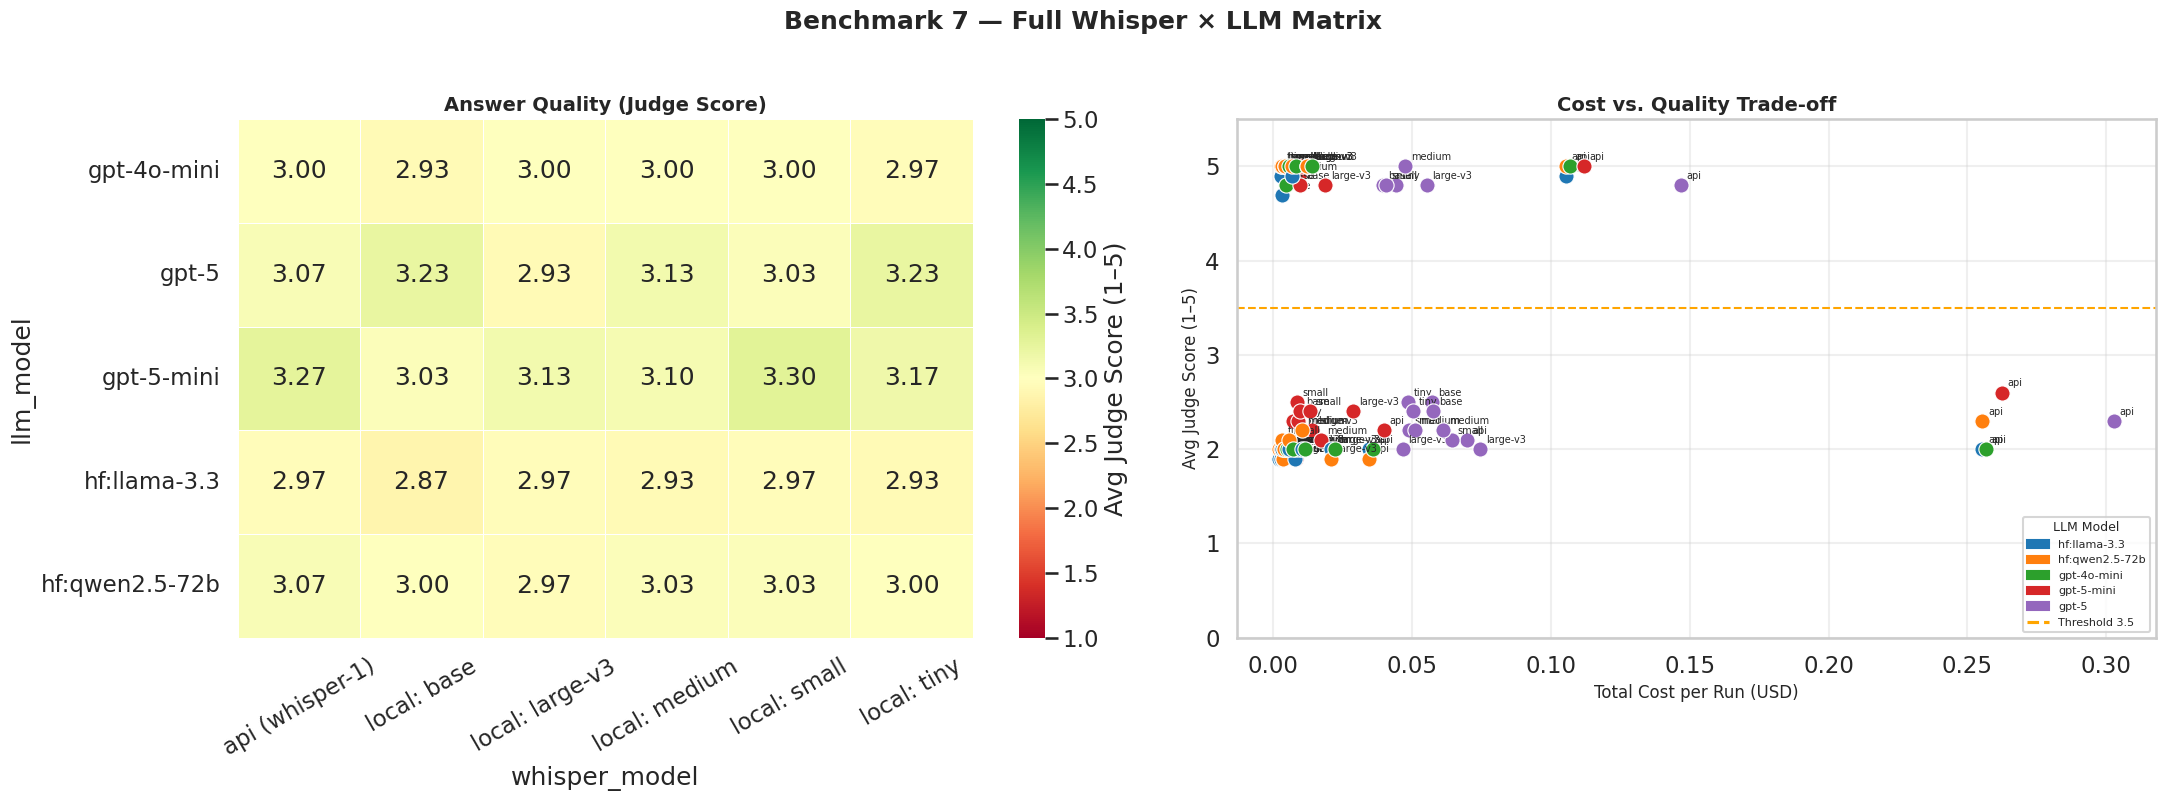

✅ benchmark7.png saved
✅ benchmark7.csv saved


In [45]:
# ═══════════════════════════════════════════════════════════════════
# Benchmark 7: Visualization + Export
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

df7 = pd.DataFrame([
    {k: v for k, v in r.items() if k != "per_q"}
    for r in benchmark7_results
])

print("Benchmark 7 — Full Matrix Overview")
print(df7[["whisper_model", "llm_model", "llm_avg_score",
           "combo_total_cost_usd", "judge_thumbs"]]
      .sort_values(["whisper_model", "llm_model"]).to_string(index=False))

sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle("Benchmark 7 — Full Whisper × LLM Matrix",
             fontsize=18, fontweight="bold", y=1.01)

# Heatmap: Whisper × LLM → avg judge score
if df7["llm_avg_score"].notna().any():
    pivot = df7.pivot_table(
        index="llm_model", columns="whisper_model",
        values="llm_avg_score", aggfunc="mean"
    )
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="RdYlGn",
        vmin=1, vmax=5, linewidths=0.5, linecolor="white",
        ax=axes[0], cbar_kws={"label": "Avg Judge Score (1–5)"}
    )
    axes[0].set_title("Answer Quality (Judge Score)", fontsize=14, fontweight="bold")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].tick_params(axis="y", rotation=0)
else:
    axes[0].text(0.5, 0.5, "No judge scores available", ha="center", va="center")
    axes[0].axis("off")

# Scatter: Cost vs. Score
ax2 = axes[1]
llm_models = df7["llm_model"].unique()
palette    = sns.color_palette("tab10", len(llm_models))
color_map  = dict(zip(llm_models, palette))

for _, row in df7.iterrows():
    if pd.isna(row.get("llm_avg_score")) or pd.isna(row.get("combo_total_cost_usd")):
        continue
    ax2.scatter(
        row["combo_total_cost_usd"], row["llm_avg_score"],
        color=color_map[row["llm_model"]], s=120, zorder=3,
        edgecolors="white", linewidths=0.8
    )
    ax2.annotate(
        row["whisper_model"].replace("local: ", "").replace("api (whisper-1)", "api"),
        (row["combo_total_cost_usd"], row["llm_avg_score"]),
        fontsize=7, ha="left", va="bottom",
        xytext=(4, 3), textcoords="offset points"
    )

ax2.axhline(y=3.5, color="orange", linestyle="--", linewidth=1.5, label="Threshold 3.5")
legend_patches = [mpatches.Patch(color=color_map[m], label=m) for m in llm_models]
legend_patches.append(plt.Line2D([0], [0], color="orange", linestyle="--", label="Threshold 3.5"))
ax2.legend(handles=legend_patches, fontsize=8, loc="lower right",
           title="LLM Model", title_fontsize=9)
ax2.set_title("Cost vs. Quality Trade-off", fontsize=14, fontweight="bold")
ax2.set_xlabel("Total Cost per Run (USD)", fontsize=12)
ax2.set_ylabel("Avg Judge Score (1–5)", fontsize=12)
ax2.set_ylim(0, 5.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = OUTPUT_DIR / "benchmark7.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"✅ {fig_path.name} saved")

# CSV export
df7.to_csv(OUTPUT_DIR / "benchmark7.csv", index=False)
print("✅ benchmark7.csv saved")

## Final Export — All Benchmark Results

Writes all benchmark DataFrames to `benchmark_results/` as individual CSVs, plus consolidated `prices.json`, `combo_table.csv`, `winners.json`, and `summary.json` for use by the QA bot.

In [46]:
# ═══════════════════════════════════════════════════════════════════
# Final Export — All Benchmarks: individual CSVs + consolidated
# JSON + PDF + prices.json + combo_table.csv + winners.json
# ═══════════════════════════════════════════════════════════════════
import json as _exp_json
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BENCHMARK_META = [
    (1, "Benchmark 1: Whisper Model Sizes"),
    (2, "Benchmark 2: Audio Bitrate"),
    (3, "Benchmark 3: Embedding Models"),
    (4, "Benchmark 4: LLM Comparison"),
    (5, "Benchmark 5: RAG vs. No-RAG"),
    (6, "Benchmark 6: Chunk-Size Grid"),
    (7, "Benchmark 7: Full Whisper × LLM Matrix"),
]

SWEET_SPOT_THRESHOLD = 3.5

# ── 1. Individual CSVs ────────────────────────────────────────────
print("── Individual CSVs ──────────────────────────────────────────")
_df_map = {
    "df1": "benchmark1_whisper_sizes",
    "df2": "benchmark2_bitrates",
    "df3": "benchmark3_embeddings",
    "df4": "benchmark4_llms",
    "df5": "benchmark5_rag_vs_norag",
    "df6": "benchmark6_chunk_grid",
    "df7": "benchmark7_full_matrix",
}
for var_name, file_name in _df_map.items():
    try:
        _df = eval(var_name).copy()
        for col in ("transcript", "per_q", "answers_json"):
            if col in _df.columns:
                _df = _df.drop(columns=[col])
        _df.to_csv(OUTPUT_DIR / f"{file_name}.csv", index=False)
        print(f"   ✅ {file_name}.csv  ({len(_df)} rows)")
    except NameError:
        print(f"   ⏭️  {var_name} not available")

# ── 2. prices.json ────────────────────────────────────────────────
print("\n── prices.json ──────────────────────────────────────────────")
prices_out = {
    "llm_models": {},
    "whisper_models": {},
    "embedding_models": {
        "text-embedding-3-small": {"cost_per_1m_tokens_usd": 0.02, "type": "openai"},
        "text-embedding-3-large": {"cost_per_1m_tokens_usd": 0.13, "type": "openai"},
    },
    "meta": {
        "whisper_api_cost_per_minute": WHISPER_API_COST_PER_MINUTE,
        "benchmark_audio_duration_sec": BENCHMARK_DURATION_SEC,
        "judge_model": JUDGE_MODEL,
        "sweet_spot_threshold": SWEET_SPOT_THRESHOLD,
    },
}
try:
    prices_out["llm_models"] = {
        k: {ik: iv for ik, iv in v.items() if ik != "hf_model_id"}
        for k, v in LLM_PRICES.items()
    }
except NameError:
    print("   ⏭️  LLM_PRICES not available")

try:
    wh = {"api (whisper-1)": {"cost_per_minute_usd": WHISPER_API_COST_PER_MINUTE, "type": "api"}}
    for _, row in df1.iterrows():
        if row["type"] == "open-source":
            size = row["model"].replace("whisper-", "").split(" ")[0]
            wh[f"local: {size}"] = {
                "cost_per_run_usd":    float(row["cost_usd"]),
                "cost_per_minute_usd": float(row["cost_usd"]) / (BENCHMARK_DURATION_SEC / 60),
                "type":                "local",
                "wer_percent":         float(row["wer_percent"]) if row["wer_percent"] is not None else None,
                "total_time_sec":      float(row["total_time_sec"]),
            }
    prices_out["whisper_models"] = wh
except (NameError, KeyError) as e:
    print(f"   ⏭️  df1 not available: {e}")

with open(OUTPUT_DIR / "prices.json", "w") as f:
    _exp_json.dump(prices_out, f, indent=2)
print(f"   ✅ prices.json  ({len(prices_out['llm_models'])} LLMs, {len(prices_out['whisper_models'])} Whisper)")

# ── 3. combo_table.csv + winners.json ────────────────────────────
print("\n── combo_table.csv + winners.json ───────────────────────────")
try:
    assert "df7" in dir() and not df7.empty
    _combo_cols = ["whisper_model", "whisper_wer_percent", "llm_model",
                   "llm_avg_score", "llm_avg_latency_sec", "llm_total_cost_usd",
                   "judge_cost_usd", "combo_total_cost_usd",
                   "judge_thumbs", "judge_fail_count"]
    combo_df = df7[[c for c in _combo_cols if c in df7.columns]].copy()
    combo_df.to_csv(OUTPUT_DIR / "combo_table.csv", index=False)
    print(f"   ✅ combo_table.csv  ({len(combo_df)} combinations)")

    def _row_to_winner(row, extra=None):
        w = {
            "whisper":        row["whisper_model"],
            "llm":            row["llm_model"],
            "total_cost_usd": float(row["combo_total_cost_usd"]),
            "judge_score":    float(row["llm_avg_score"]) if pd.notna(row.get("llm_avg_score")) else None,
            "judge_thumbs":   row.get("judge_thumbs", "pending"),
        }
        if extra:
            w.update(extra)
        return w

    winners = {}
    winners["cheapest"] = _row_to_winner(
        combo_df.loc[combo_df["combo_total_cost_usd"].idxmin()],
        {"note": "Lowest total cost"}
    )
    _time_col = "whisper_time_sec" if "whisper_time_sec" in combo_df.columns else "combo_total_cost_usd"
    winners["fastest"] = _row_to_winner(
        combo_df.loc[combo_df[_time_col].idxmin()],
        {"note": "Fastest transcription + answer"}
    )
    _quality = combo_df[combo_df["llm_avg_score"].notna() & (combo_df["llm_avg_score"] >= SWEET_SPOT_THRESHOLD)]
    if not _quality.empty:
        winners["business_sweet_spot"] = _row_to_winner(
            _quality.loc[_quality["combo_total_cost_usd"].idxmin()],
            {"note": f"Cheapest combo with score ≥ {SWEET_SPOT_THRESHOLD}", "threshold": SWEET_SPOT_THRESHOLD}
        )
    else:
        winners["business_sweet_spot"] = {"note": f"No combo reached score ≥ {SWEET_SPOT_THRESHOLD}"}

    _free = combo_df[(combo_df["combo_total_cost_usd"] < 0.0001) & combo_df["llm_avg_score"].notna()]
    if not _free.empty:
        winners["free_tier_hero"] = _row_to_winner(
            _free.loc[_free["llm_avg_score"].idxmax()],
            {"note": "Best quality at 0$ cost (local Whisper + HF LLM)"}
        )
    else:
        winners["free_tier_hero"] = {"note": "No fully free combination found"}

    winners["_meta"] = {
        "judge_model":           JUDGE_MODEL,
        "sweet_spot_threshold":  SWEET_SPOT_THRESHOLD,
        "total_combinations":    len(combo_df),
    }
    with open(OUTPUT_DIR / "winners.json", "w") as f:
        _exp_json.dump(winners, f, indent=2)
    print("   ✅ winners.json")
    for key in ["cheapest", "fastest", "business_sweet_spot", "free_tier_hero"]:
        w = winners[key]
        if "whisper" in w:
            score = f"{w['judge_score']:.2f}" if w.get("judge_score") else "n/a"
            print(f"      {key:<22} {w['whisper']:<22} + {w['llm']:<18} ${w['total_cost_usd']:.4f}  score={score}")
        else:
            print(f"      {key:<22} — {w['note']}")
except Exception as e:
    import traceback
    print(f"   ❌ combo_table/winners: {e}")
    traceback.print_exc()

# ── 4. summary.json ───────────────────────────────────────────────
print("\n── summary.json ─────────────────────────────────────────────")
summary = {"benchmarks_run": [], "key_insights": {}}

try:
    _b1_valid = df1[df1["wer_percent"].notna()]
    best_w = _b1_valid.loc[_b1_valid["wer_percent"].idxmin()]
    summary["benchmarks_run"].append("B1_whisper_sizes")
    summary["key_insights"]["best_whisper"] = {
        "model": best_w["model"], "wer": float(best_w["wer_percent"]), "cost": float(best_w["cost_usd"])
    }
except (NameError, KeyError): pass

try:
    _b3_valid = df3[df3["mean_mrr"].notna()]
    best_e = _b3_valid.loc[_b3_valid["mean_mrr"].idxmax()]
    summary["benchmarks_run"].append("B3_embeddings")
    summary["key_insights"]["best_embedding"] = {
        "model": best_e["model"], "mrr": float(best_e["mean_mrr"])
    }
except (NameError, KeyError): pass

try:
    _b4_valid = df4[df4["avg_score"].notna()]
    best_l = _b4_valid.loc[_b4_valid["avg_score"].idxmax()]
    summary["benchmarks_run"].append("B4_llms")
    summary["key_insights"]["best_llm"] = {
        "model": best_l["model"], "score": float(best_l["avg_score"]), "cost": float(best_l["total_cost_usd"])
    }
except (NameError, KeyError): pass

try:
    _b6_single = df6[df6["variant"] == "single"]
    best_c = _b6_single.loc[_b6_single["mrr"].idxmax()]
    summary["benchmarks_run"].append("B6_chunk_grid")
    summary["key_insights"]["best_chunk_overall"] = {
        "chunk_size": int(best_c["chunk_size"]), "overlap": int(best_c["overlap"]),
        "mrr": float(best_c["mrr"]), "video": best_c["video_label"], "whisper": best_c["whisper_model"]
    }
    _rec_path = OUTPUT_DIR / "chunk_recommendations.json"
    if _rec_path.exists():
        with open(_rec_path) as _rf:
            summary["key_insights"]["chunk_recommendations"] = _exp_json.load(_rf)
except (NameError, KeyError): pass

try:
    summary["benchmarks_run"].append("B7_full_matrix")
    _b7_valid = df7[df7["llm_avg_score"].notna()]
    best_combo = _b7_valid.loc[_b7_valid["llm_avg_score"].idxmax()]
    summary["key_insights"]["best_combo"] = {
        "whisper": best_combo["whisper_model"], "llm": best_combo["llm_model"],
        "score": float(best_combo["llm_avg_score"]), "cost": float(best_combo["combo_total_cost_usd"])
    }
    summary["key_insights"]["full_matrix_total_cost_usd"] = float(df7["llm_total_cost_usd"].sum())
except (NameError, KeyError): pass

with open(OUTPUT_DIR / "summary.json", "w") as f:
    _exp_json.dump(summary, f, indent=2)
print("   ✅ summary.json")

# ── 5. all_benchmarks.json ────────────────────────────────────────
print("\n── all_benchmarks.json ──────────────────────────────────────")
all_data = {}
for var_name, file_name in _df_map.items():
    try:
        _df = eval(var_name).copy()
        for col in ("transcript", "per_q", "answers_json"):
            if col in _df.columns:
                _df = _df.drop(columns=[col])
        all_data[file_name] = _df.to_dict(orient="records")
    except NameError:
        pass

for fname in ("winners", "summary", "prices", "chunk_recommendations"):
    _p = OUTPUT_DIR / f"{fname}.json"
    if _p.exists():
        with open(_p) as _f:
            all_data[fname] = _exp_json.load(_f)

with open(OUTPUT_DIR / "all_benchmarks.json", "w") as f:
    _exp_json.dump(all_data, f, indent=2, default=str)
print("   ✅ all_benchmarks.json")

# ── 6. all_benchmarks.csv ─────────────────────────────────────────
print("\n── all_benchmarks.csv ───────────────────────────────────────")
_csv_parts = []
for var_name, file_name in _df_map.items():
    try:
        _df = eval(var_name).copy()
        for col in ("transcript", "per_q", "answers_json"):
            if col in _df.columns:
                _df = _df.drop(columns=[col])
        _df.insert(0, "benchmark", file_name)
        _csv_parts.append(_df)
    except NameError:
        pass

if _csv_parts:
    pd.concat(_csv_parts, ignore_index=True, sort=False).to_csv(
        OUTPUT_DIR / "all_benchmarks.csv", index=False
    )
    print("   ✅ all_benchmarks.csv")

# ── 7. benchmark_report.pdf ───────────────────────────────────────
print("\n── benchmark_report.pdf ─────────────────────────────────────")

def _table_page(pdf, title, df, max_rows=25):
    _df = df.copy().head(max_rows)
    for col in ("transcript", "per_q", "answers_json"):
        if col in _df.columns:
            _df = _df.drop(columns=[col])
    _num = _df.select_dtypes(include="number").columns
    _df[_num] = _df[_num].round(4)
    fig, ax = plt.subplots(figsize=(16, 9))
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", loc="left", pad=10)
    tbl = ax.table(cellText=_df.astype(str).values,
                   colLabels=_df.columns, loc="center", cellLoc="left")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    tbl.scale(1, 1.3)
    for j in range(len(_df.columns)):
        tbl[(0, j)].set_facecolor("#2E86AB")
        tbl[(0, j)].set_text_props(color="white", fontweight="bold")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

def _image_page(pdf, title, png_path):
    fig, ax = plt.subplots(figsize=(16, 9))
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", loc="left", pad=10)
    ax.imshow(mpimg.imread(str(png_path)), aspect="auto")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

B6_PNGS = sorted(OUTPUT_DIR.glob("benchmark6_*.png"))

with PdfPages(OUTPUT_DIR / "benchmark_report.pdf") as pdf:
    # Cover
    fig, ax = plt.subplots(figsize=(16, 9))
    ax.axis("off")
    ax.text(0.5, 0.65, "YouTube QA Bot — Benchmark Report",
            ha="center", fontsize=24, fontweight="bold", transform=ax.transAxes)
    ax.text(0.5, 0.55, "Ironhack AI Bootcamp — Final Project",
            ha="center", fontsize=14, color="gray", transform=ax.transAxes)
    ax.text(0.5, 0.43, f"Benchmarks: {len(BENCHMARK_META)}  |  Videos: 3  |  Whisper models: 6",
            ha="center", fontsize=11, color="gray", transform=ax.transAxes)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for n, title in BENCHMARK_META:
        if n == 6:
            for png in B6_PNGS:
                _image_page(pdf, f"{title} — {png.stem}", png)
        else:
            png_path = OUTPUT_DIR / f"benchmark{n}.png"
            if png_path.exists():
                _image_page(pdf, f"{title} — Plot", png_path)
            else:
                print(f"   ⏭️  benchmark{n}.png missing")

        csv_path = OUTPUT_DIR / f"benchmark{n}.csv"
        if n != 6 and csv_path.exists():
            try:
                _table_page(pdf, f"{title} — Data", pd.read_csv(csv_path))
            except Exception as e:
                print(f"   ⚠️  table B{n}: {e}")

    _b6_best = OUTPUT_DIR / "benchmark6_best_configs.csv"
    if _b6_best.exists():
        _table_page(pdf, "Benchmark 6 — Best Config per Video × Whisper", pd.read_csv(_b6_best))

    _b7_csv = OUTPUT_DIR / "benchmark7_full_matrix.csv"
    if _b7_csv.exists():
        _table_page(pdf, "Benchmark 7 — Full Matrix Data", pd.read_csv(_b7_csv))

print("   ✅ benchmark_report.pdf")

# ── 8. Safety check: verify all files present and non-empty ──────
print("\n── File verification ────────────────────────────────────────")

_expected_files = [
    "benchmark1_whisper_sizes.csv",
    "benchmark2_bitrates.csv",
    "benchmark3_embeddings.csv",
    "benchmark4_llms.csv",
    "benchmark5_rag_vs_norag.csv",
    "benchmark6_chunk_grid.csv",
    "benchmark6_best_configs.csv",
    "benchmark7_full_matrix.csv",
    "prices.json",
    "combo_table.csv",
    "winners.json",
    "summary.json",
    "chunk_recommendations.json",
    "all_benchmarks.json",
    "all_benchmarks.csv",
    "benchmark_report.pdf",
]
for _label in ["short_video", "medium_video", "long_video"]:
    _expected_files.append(f"benchmark6_{_label}_heatmap.png")
    _expected_files.append(f"benchmark6_{_label}_curves.png")
_expected_files.append("benchmark6_summary.png")
for _n in [1, 2, 3, 4, 5, 7]:
    _expected_files.append(f"benchmark{_n}.png")

print()
_missing = []
for _fname in _expected_files:
    _fpath = OUTPUT_DIR / _fname
    if _fpath.exists():
        _size = _fpath.stat().st_size
        if _size > 0:
            print(f"   ✅ {_fname}  ({_size:,} bytes)")
        else:
            print(f"   ⚠️  {_fname}  — FILE IS EMPTY")
            _missing.append(_fname)
    else:
        print(f"   ❌ {_fname}  — MISSING")
        _missing.append(_fname)

print()
if _missing:
    print(f"⚠️  {len(_missing)} file(s) missing or empty:")
    for _f in _missing:
        print(f"   • {_f}")
else:
    print(f"✅ All {len(_expected_files)} files present and non-empty.")
    print(f"   Location: {OUTPUT_DIR}")

── Individual CSVs ──────────────────────────────────────────
   ✅ benchmark1_whisper_sizes.csv  (18 rows)
   ✅ benchmark2_bitrates.csv  (10 rows)
   ✅ benchmark3_embeddings.csv  (6 rows)
   ✅ benchmark4_llms.csv  (5 rows)
   ✅ benchmark5_rag_vs_norag.csv  (4 rows)
   ✅ benchmark6_chunk_grid.csv  (294 rows)
   ✅ benchmark7_full_matrix.csv  (90 rows)

── prices.json ──────────────────────────────────────────────
   ✅ prices.json  (6 LLMs, 6 Whisper)

── combo_table.csv + winners.json ───────────────────────────
   ✅ combo_table.csv  (90 combinations)
   ✅ winners.json
      cheapest               local: tiny            + hf:llama-3.3       $0.0020  score=1.90
      fastest                local: tiny            + hf:llama-3.3       $0.0020  score=1.90
      business_sweet_spot    local: tiny            + hf:llama-3.3       $0.0026  score=4.90
      free_tier_hero         — No fully free combination found

── summary.json ─────────────────────────────────────────────
   ✅ summary.json

──